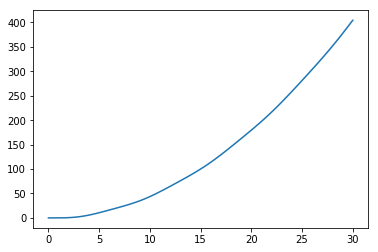

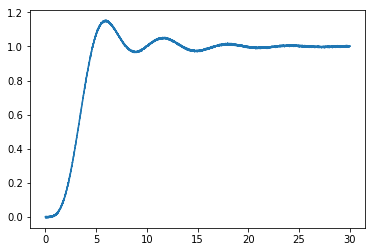

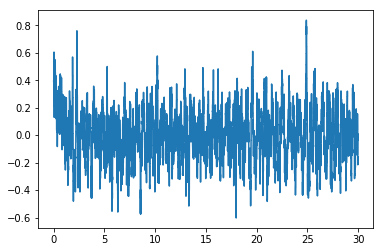

In [10]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.005 (using tf)
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal


Tf=30
# crypto parameters
F=GF(next_prime(2^64)) #finite field
server=3 # number of computing servers
t=1 #shamir threshold 
scale=3 # A/D and D/A Accuracy

#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[0]
X2=[0]
X3=[0]
X4=[0]
Y=[0]
Tc=1
dt=0.005
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)
noise=np.random.normal(0,0.002,samp)
#UNCONTROLLED SYSTEM
for i in range(1,samp):
    x1=0.9998*x1-0.004999*x2+0.004999*Tc
    x2=0.004999*x1+1*x2+1.25e-05*Tc
    x3=1.25e-05*x1+0.005*x2+1*x3+2.083e-08*Tc
    x4=2.083e-08*x1+1.25e-05*x2+0.005*x3+1*x4+2.604e-11*Tc
    y=0.036*x3+0.9*x4
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)
plt.step(samples,Y)
plt.show()



#controlled
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[0]
X2c=[0]
X3c=[0]
X4c=[0]
Yc=[0]
U=[0]
z1c,z2c,z3c,z4c,uc=0,0,0,0,0
Z1c=[0]
Z2c=[0]
Z3c=[0]
Z4c=[0]
Uc=[0]
kr=0.3933
for i in range(1,samp):
    
    u=r*kr+uc
    x1c=0.9998*x1c-0.004999*x2c+0.004999*u
    x2c=0.004999*x1c+1*x2c+1.25e-05*u
    x3c=1.25e-05*x1c+0.005*x2c+1*x3c+2.083e-08*u
    x4c=2.083e-08*x1c+1.25e-05*x2c+0.005*x3c+1*x4c+2.604e-11*u
    yc=0.036*x3c+0.9*x4c+noise[i]
    
    z1c=1*z1c-1.27e-05*z2c-0.0009439*z3c-0.02316*z4c-0.0001303*u+0.006641*yc
    z2c=0.04*z1c+1*z2c-0.002388*z3c-0.05874*z4c-0.0001813*u+0.01312*yc
    z3c=0.0007996*z1c+0.03996*z2c+0.997*z3c-0.0733*z4c-0.0001282*u+0.003186*yc
    z4c=2.075e-05*z1c+0.001542*z2c+0.07567*z3c+0.8928*z4c-9.078e-05*u-0.5447*yc
    uc=64*z4c
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    Z1c.append(z1c)
    Z2c.append(z2c)
    Z3c.append(z3c)
    Z4c.append(z4c)
    U.append(u)

Yc.pop(0) 
U.pop(0)

samples2=np.delete(samples,-1)
#samples2=np.resize(samples, samples.size - 1)    
plt.step(samples2,Yc)
plt.show()
plt.step(samples2,U)
plt.show()

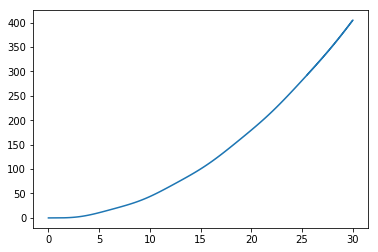

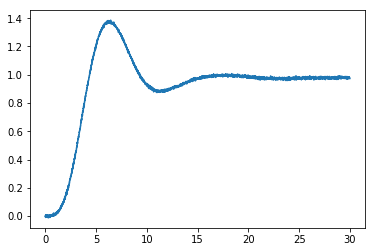

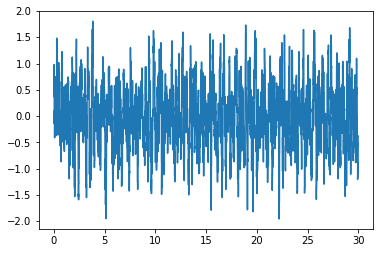

In [6]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.01 (using tf)
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal

noise=np.random.normal(0,0.005,samp)
Tf=30

#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[0]
X2=[0]
X3=[0]
X4=[0]
Y=[0]
Tc=1
dt=0.01
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    x1=0.9996*x1-0.009998*x2+0.009998*Tc
    x2=0.009998*x1+1*x2+4.999e-05*Tc
    x3=4.999e-05*x1+0.01*x2+1*x3+1.666e-07*Tc
    x4=1.666e-07*x1+5e-05*x2+0.01*x3+1*x4+4.166e-10*Tc
    y=0.036*x3+0.9*x4
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)
plt.step(samples,Y)
plt.show()



#controlled
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[0]
X2c=[0]
X3c=[0]
X4c=[0]
Yc=[0]
U=[0]
z1c,z2c,z3c,z4c,uc=0,0,0,0,0
Z1c=[0]
Z2c=[0]
Z3c=[0]
Z4c=[0]
Uc=[0]
kr=0.3933
for i in range(1,samp):
    
    u=r*kr-uc
    x1c=0.9996*x1c-0.009998*x2c+0.009998*u
    x2c=0.009998*x1c+1*x2c+4.999e-05*u
    x3c=4.999e-05*x1c+0.01*x2c+1*x3c+1.666e-07*u
    x4c=1.666e-07*x1c+5e-05*x2c+0.01*x3c+1*x4c+4.166e-10*u
    yc=0.036*x3c+0.9*x4c+noise[i]
    
    z1c=1*z1c-9.883e-05*z2c-0.003637*z3c-0.04377*z4c+0.0002583*u-0.02589*yc
    z2c=0.07999*z1c+0.9997*z2c-0.009251*z3c-0.1119*z4c+0.0003622*u-0.05849*yc
    z3c=0.003194*z1c+0.07969*z2c+0.9884*z3c-0.1409*z4c+0.0002568*u-0.04682*yc
    z4c=0.0001615*z1c+0.005943*z2c+0.143*z3c+0.7914*z4c+0.0001818*u+1.031*yc
    uc=64*z4c
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    Z1c.append(z1c)
    Z2c.append(z2c)
    Z3c.append(z3c)
    Z4c.append(z4c)
    U.append(u)

Yc.pop(0) 
U.pop(0)

samples2=np.delete(samples,-1)
#samples2=np.resize(samples, samples.size - 1)    
plt.step(samples2,Yc)
plt.show()
plt.step(samples2,U)
plt.show()

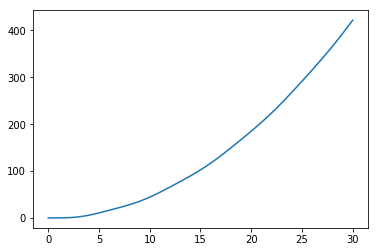

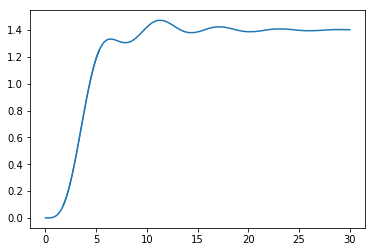

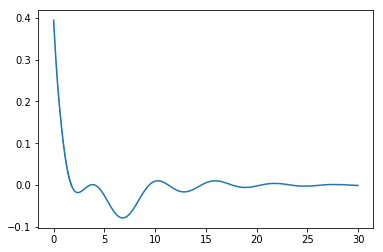

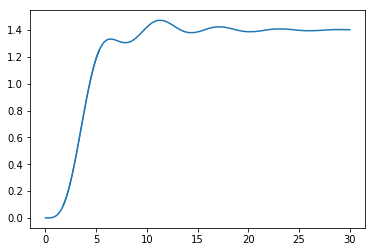

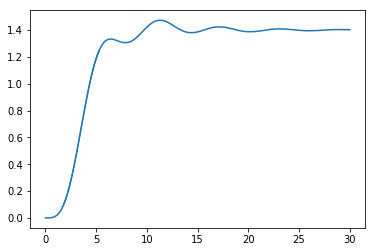

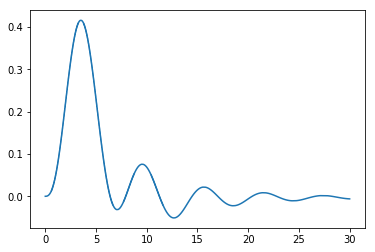

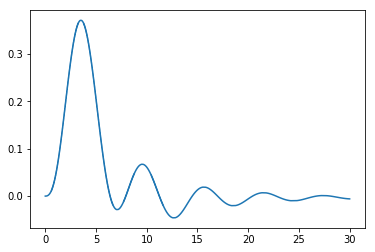

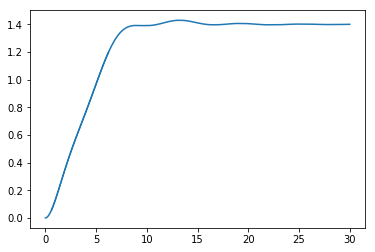

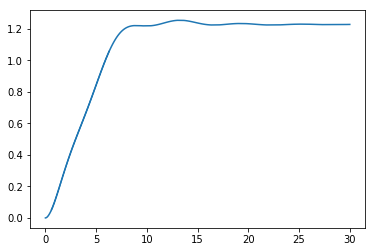

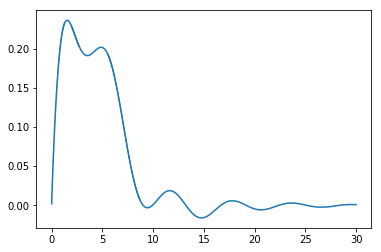

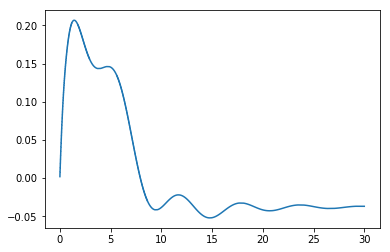

In [4]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.005  ##state variavle remained
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal


Tf=30

#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[0]
X2=[0]
X3=[0]
X4=[0]
Y=[0]
Tc=1
dt=0.005
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    x1=1*x1+0.005*x2+1.137e-05*x3+4.689e-07*x4+7.737e-10*Tc
    x2=-0.00455*x1+0.9998*x2+0.00455*x3+0.0001914*x4+4.689e-07*Tc
    x3=1.137e-06*x1+4.689e-08*x2+1*x3+0.005*x4+1.25e-05*Tc
    x4=0.000455*x1+1.914e-05*x2-0.000455*x3+1*x4+0.005*Tc
    y=x1
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)
plt.step(samples,Y)
plt.show()



#controlled
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[]
X2c=[]
X3c=[]
X4c=[]
Yc=[]
U=[]
z1c,z2c,z3c,z4c,uc=0,0,0,0,0
Z1c=[]
Z2c=[]
Z3c=[]
Z4c=[]
Uc=[]
kr=0.394

for i in range(samp):
    
    u=r*kr-uc
    
    x1c=1*x1c+0.005*x2c+1.137e-05*x3c+4.689e-07*x4c+7.737e-10*u
    x2c=-0.00455*x1c+0.9998*x2c+0.00455*x3c+0.0001914*x4c+4.689e-07*u
    x3c=1.137e-06*x1c+4.689e-08*x2c+1*x3c+0.005*x4c+1.25e-05*u
    x4c=0.000455*x1c+1.914e-05*x2c-0.000455*x3c+1*x4c+0.005*u
    yc=x1c
    
    z1c=0.893*z1c+0.00473*z2c+1.096e-05*z3c+4.521e-07*z4c+7.527e-10*u+0.107*yc
    z2c=-1.168*z1c+0.9969*z2c+0.004545*z3c+0.0001912*z4c+4.687e-07*u+1.164*yc
    z3c=-7.222*z1c-0.01834*z2c+1*z3c+0.004999*z4c+1.25e-05*u+7.222*yc
    z4c=-25.95*z1c-0.06607*z2c-0.0005561*z3c+1*z4c+0.005*u+25.95*yc
    uc=-0.2614*z1c+0.04152*z2c+0.6554*z3c+1.16*z4c
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    
    Z1c.append(z1c)
    Z2c.append(z2c)
    Z3c.append(z3c)
    Z4c.append(z4c)
    U.append(u)
    
#print(Y)    
plt.step(samples,Yc)
plt.show()
plt.step(samples,U)
plt.show()

plt.step(samples,X1c)
plt.show()
plt.step(samples,Z1c)
plt.show()
plt.step(samples,X2c)
plt.show()
plt.step(samples,Z2c)
plt.show()
plt.step(samples,X3c)
plt.show()
plt.step(samples,Z3c)
plt.show()
plt.step(samples,X4c)
plt.show()
plt.step(samples,Z4c)
plt.show()

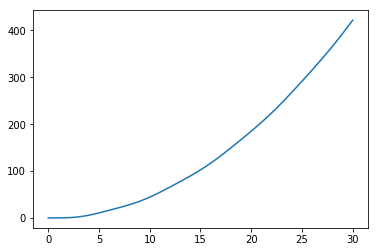

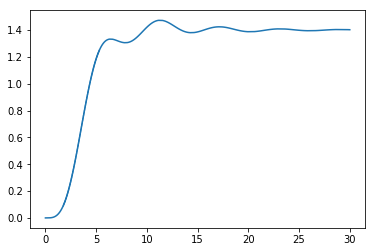

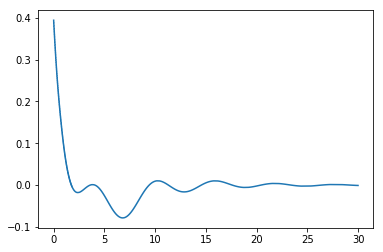

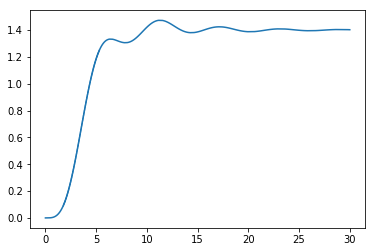

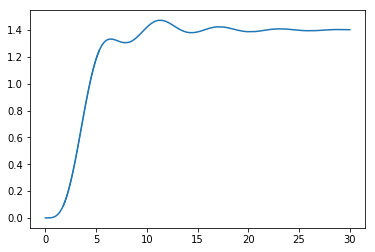

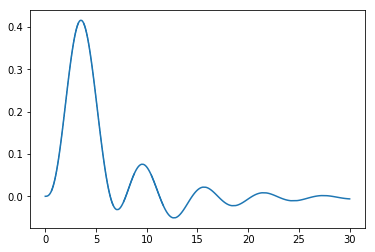

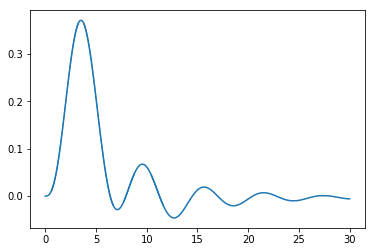

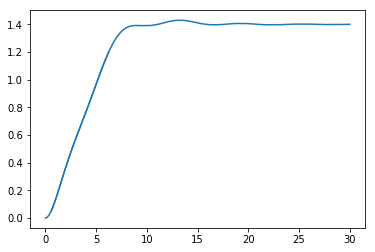

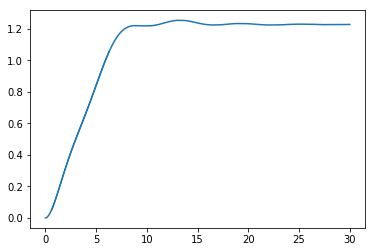

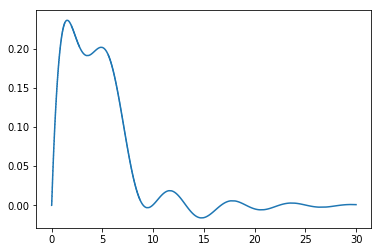

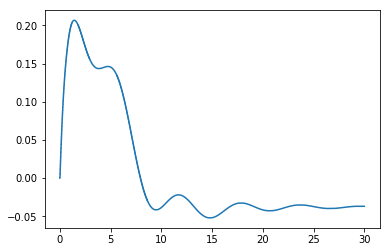

In [2]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.005  ## discretized estimator (state variable remained)
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal


Tf=30


#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[0]
X2=[0]
X3=[0]
X4=[0]
Y=[0]
Tc=1
dt=0.005
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    x1=1*x1+0.005*x2+1.137e-05*x3+4.689e-07*x4+7.737e-10*Tc
    x2=-0.00455*x1+0.9998*x2+0.00455*x3+0.0001914*x4+4.689e-07*Tc
    x3=1.137e-06*x1+4.689e-08*x2+1*x3+0.005*x4+1.25e-05*Tc
    x4=0.000455*x1+1.914e-05*x2-0.000455*x3+1*x4+0.005*Tc
    y=x1
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)
plt.step(samples,Y)
plt.show()



#controlled
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[0]
X2c=[0]
X3c=[0]
X4c=[0]
Yc=[0]
U=[0]
z1c,z2c,z3c,z4c,u1,u2,u3,u4,uc=0,0,0,0,0,0,0,0,0
X1s=[0]
X2s=[0]
X3s=[0]
X4s=[0]
Uc=[0]
k1c=-0.2614
k2c=0.0415
k3c=0.6554
k4c=1.1604

for i in range(1,samp):
    
    
    x1c=1*x1c +0.005*x2c +1.137e-05*x3c +4.689e-07*x4c +7.737e-10*u
    x2c=-0.00455*x1c +0.9998*x2c +0.00455*x3c +0.0001914*x4c +4.689e-07*u
    x3c=1.137e-06*x1c +4.689e-08*x2c +1*x3c +0.005*x4c +1.25e-05*u
    x4c=0.000455*x1c +1.914e-05*x2c -0.000455*x3c +1*x4c +0.005*u
    yc=x1c
    
    #estimator  
    z1c=0.893*z1c +0.00473*z2c +1.096e-05*z3c +4.521e-07*z4c +7.527e-10*u +0.107*yc
    z2c=-1.168*z1c +0.9969*z2c +0.004545*z3c +0.0001912*z4c +4.687e-07*u +1.164*yc
    z3c=-7.222*z1c -0.01834*z2c +1*z3c +0.004999*z4c +1.25e-05*u +7.222*yc
    z4c=-25.95*z1c -0.06607*z2c -0.0005561*z3c +1*z4c +0.005*u +25.95*yc
    
    
    x1s=z1c
    x2s=z2c
    x3s=z3c
    x4s=z4c
    
    #control law  
    u1=(r-x1s)*k1c
    u2=x2s*k2c
    u3=(r-x3s)*k3c
    u4=x4s*k4c
    u=u1+u3-u2-u4
    
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    X1s.append(x1s)
    X2s.append(x2s)
    X3s.append(x3s)
    X4s.append(x4s)
    U.append(u)
  

U.pop(0)
samples2=np.delete(samples,-1)
plt.step(samples,Yc)
plt.show()
plt.step(samples2,U)
plt.show()
plt.step(samples,X1c)
plt.show()
plt.step(samples,X1s)
plt.show()
plt.step(samples,X2c)
plt.show()
plt.step(samples,X2s)
plt.show()
plt.step(samples,X3c)
plt.show()
plt.step(samples,X3s)
plt.show()
plt.step(samples,X4c)
plt.show()
plt.step(samples,X4s)
plt.show()

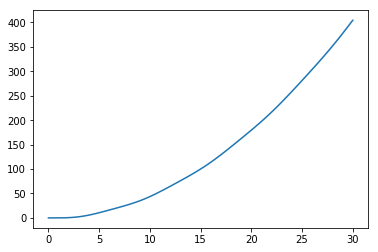

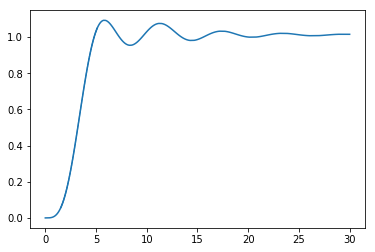

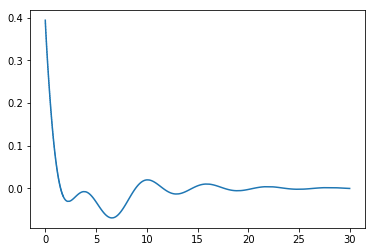

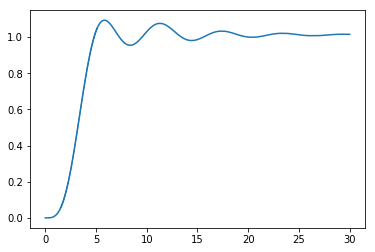

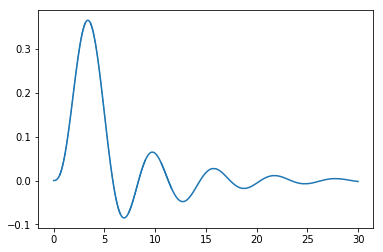

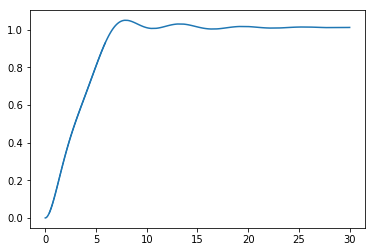

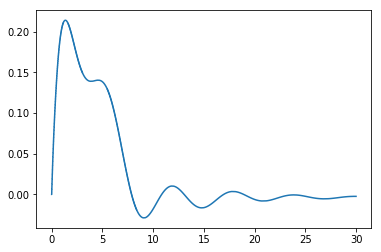

In [3]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.005  ## discretized estimator (using tf)
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal


Tf=30


#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[0]
X2=[0]
X3=[0]
X4=[0]
Y=[0]
Tc=1
dt=0.005
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#UNCONTROLLED SYSTEM
for i in range(1,samp):
    x1=0.9998*x1-0.004999*x2+0.004999*Tc
    x2=0.004999*x1+1*x2+1.25e-05*Tc
    x3=1.25e-05*x1+0.005*x2+1*x3+2.083e-08*Tc
    x4=2.083e-08*x1+1.25e-05*x2+0.005*x3+1*x4+2.604e-11*Tc
    y=0.036*x3+0.9*x4
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)
plt.step(samples,Y)
plt.show()



#controlled
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[0]
X2c=[0]
X3c=[0]
X4c=[0]
Yc=[0]
U=[0]
z1c,z2c,z3c,z4c,z5c,z6c,z7c,z8c,u1,u2,u3,u4,uc=0,0,0,0,0,0,0,0,0,0,0,0,0
X1s=[0]
X2s=[0]
X3s=[0]
X4s=[0]
Uc=[0]
k1c=-0.2614
k2c=0.0415
k3c=0.6554
k4c=1.1604

for i in range(1,samp):
    
    
    x1c=0.9998*x1c-0.004999*x2c+0.004999*u
    x2c=0.004999*x1c+1*x2c+1.25e-05*u
    x3c=1.25e-05*x1c+0.005*x2c+1*x3c+2.083e-08*u
    x4c=2.083e-08*x1c+1.25e-05*x2c+0.005*x3c+1*x4c+2.604e-11*u
    yc=0.036*x3c+0.9*x4c
    
    #estimator difference equation
    z1c=0.8928*z1c-0.0733*z2c-0.05874*z3c-0.02316*z4c+0.009459*u
    z2c=0.07567*z1c+0.997*z2c-0.002388*z3c-0.0009439*z4c+0.0003855*u
    z3c=0.001542*z1c+0.03996*z2c+1*z3c-1.27e-05*z4c+5.188e-06 *u
    z4c=2.075e-05*z1c+0.0007996*z2c+0.04*z3c+1*z4c+5.217e-08*u
    z5c=0.8928*z5c-0.0733*z6c-0.05874*z7c-0.02316*z8c+0.3027*yc
    z6c=0.07567*z5c+0.997*z6c-0.002388*z7c-0.0009439*z8c+0.01234*yc
    z7c=0.001542*z5c+0.03996*z6c+1*z7c-1.27e-05*z8c+0.000166*yc
    z8c=2.075e-05*z5c+0.0007996*z6c+0.04*z7c+1*z8c+1.669e-06*yc
    
    # satate estimation
    x1s=0.0001406*z3c+0.0004443*z4c+0.3438*z5c +0.2372*z6c+0.1925*z7c+0.07651*z8c
    x2s=0.001125*z2c+0.006648*z3c+0.009776*z4c+3.782*z5c+1.519*z6c+0.6121*z7c+4.685e-16*z8c
    x3s=0.03125*z2c+0.08608*z3c+0.09243*z4c+23.64*z5c+5.416*z6c+0.1925*z7c+0.07651*z8c
    x4s=0.5*z1c+0.6886*z2c+0.9522*z3c+0.6722*z4c+85.72*z5c+0.06123*z6c+0.6121*z7c+2.294e-14*z8c
    
    #control law  
    u1=(r-x1s)*k1c
    u2=x2s*k2c
    u3=(r-x3s)*k3c
    u4=x4s*k4c
    u=u1+u3-u2-u4
    
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    X1s.append(x1s)
    X2s.append(x2s)
    X3s.append(x3s)
    X4s.append(x4s)
    U.append(u)
  
U.pop(0)
samples2=np.delete(samples,-1)
plt.step(samples,Yc)
plt.show()
plt.step(samples2,U)
plt.show()
plt.step(samples,X1s)
plt.show()
plt.step(samples,X2s)
plt.show()
plt.step(samples,X3s)
plt.show()
plt.step(samples,X4s)
plt.show()

In [1]:
                     ## controlled
                     ########SATELLITE#######
                        ##T=0.005 (using tf)  secure control satellite   #pole placement
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
from scipy.io import savemat


Tf=30
# crypto parameters
F=GF(next_prime(2^80)) #finite field
server=3 # number of computing servers
t=1 #shamir threshold 
scale=8 # A/D and D/A Accuracy


#initial values
x1=0
x2,x3,x4,y=0,0,0,0
X1=[]
X2=[]
X3=[]
X4=[]
Y=[]
Tc=1
dt=0.005
samp=Tf/dt
samp=int(samp)
samples=np.linspace(0,Tf, num=samp)

#noise
sigma=0.001
noise=np.random.normal(0,sigma,samp)

#UNCONTROLLED SYSTEM
for i in range(samp):
    x1=0.9998*x1-0.004999*x2+0.004999*Tc
    x2=0.004999*x1+1*x2+1.25e-05*Tc
    x3=1.25e-05*x1+0.005*x2+1*x3+2.083e-08*Tc
    x4=2.083e-08*x1+1.25e-05*x2+0.005*x3+1*x4+2.604e-11*Tc
    y=0.036*x3+0.9*x4
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    X4.append(x4)
    Y.append(y)




#############################controlled#############################################
#initial values
r=1
x1c,x2c,x3c,x4c,yc,u=0,0,0,0,0,0
X1c=[]
X2c=[]
X3c=[]
X4c=[]
Yc=[]
U=[]
z1c,z2c,z3c,z4c,uc=0,0,0,0,0
Z1c=[]
Z2c=[]
Z3c=[]
Z4c=[]
Uc=[]
kr=0.3933

for i in range(samp):
    
    u=r*kr+uc
    x1c=0.9998*x1c-0.004999*x2c+0.004999*u
    x2c=0.004999*x1c+1*x2c+1.25e-05*u
    x3c=1.25e-05*x1c+0.005*x2c+1*x3c+2.083e-08*u
    x4c=2.083e-08*x1c+1.25e-05*x2c+0.005*x3c+1*x4c+2.604e-11*u
    yc=0.036*x3c+0.9*x4c
    
    z1c=1*z1c-1.27e-05*z2c-0.0009439*z3c-0.02316*z4c-0.0001303*u+0.006641*yc
    z2c=0.04*z1c+1*z2c-0.002388*z3c-0.05874*z4c-0.0001813*u+0.01312*yc
    z3c=0.0007996*z1c+0.03996*z2c+0.997*z3c-0.0733*z4c-0.0001282*u+0.003186*yc
    z4c=2.075e-05*z1c+0.001542*z2c+0.07567*z3c+0.8928*z4c-9.078e-05*u-0.5447*yc
    uc=64*z4c
    
    X1c.append(x1c)
    X2c.append(x2c)
    X3c.append(x3c)
    X4c.append(x4c)
    Yc.append(yc)
    Z1c.append(z1c)
    Z2c.append(z2c)
    Z3c.append(z3c)
    Z4c.append(z4c)
    U.append(u)
    Uc.append(uc)

###########################################noisy controlled#######################################################
x1cn,x2cn,x3cn,x4cn,ycn,un=0,0,0,0,0,0
X1cn=[]
X2cn=[]
X3cn=[]
X4cn=[]
Ycn=[]
Un=[]
z1cn,z2cn,z3cn,z4cn,ucn=0,0,0,0,0
Z1cn=[]
Z2cn=[]
Z3cn=[]
Z4cn=[]
Ucn=[]
kr=0.3933

for i in range(samp):
    
    un=r*kr+ucn
    x1cn=0.9998*x1cn-0.004999*x2cn+0.004999*un
    x2cn=0.004999*x1cn+1*x2cn+1.25e-05*un
    x3cn=1.25e-05*x1cn+0.005*x2cn+1*x3cn+2.083e-08*un
    x4cn=2.083e-08*x1cn+1.25e-05*x2cn+0.005*x3cn+1*x4cn+2.604e-11*un
    ycn=0.036*x3cn+0.9*x4cn+noise[i]
    
    z1cn=1*z1cn-1.27e-05*z2cn-0.0009439*z3cn-0.02316*z4cn-0.0001303*un+0.006641*ycn
    z2cn=0.04*z1cn+1*z2cn-0.002388*z3cn-0.05874*z4cn-0.0001813*un+0.01312*ycn
    z3cn=0.0007996*z1cn+0.03996*z2cn+0.997*z3cn-0.0733*z4cn-0.0001282*un+0.003186*ycn
    z4cn=2.075e-05*z1cn+0.001542*z2cn+0.07567*z3cn+0.8928*z4cn-9.078e-05*un-0.5447*ycn
    ucn=64*z4cn
    
    X1cn.append(x1cn)
    X2cn.append(x2cn)
    X3cn.append(x3cn)
    X4cn.append(x4cn)
    Ycn.append(ycn)
    Z1cn.append(z1cn)
    Z2cn.append(z2cn)
    Z3cn.append(z3cn)
    Z4cn.append(z4cn)
    Un.append(un)
    Ucn.append(ucn)
#############################################secure control############################################################
rs=sss.share(F,r,t,server,scale)
x1cs,x2cs,x3cs,x4cs,ycs,us,us_rec=0,0,0,0,0,0,0
X1cs=[]
X2cs=[]
X3cs=[]
X4cs=[]
Ycs=[]
Us=[]
Us_rec=[]

ucs=sss.share(F,0,t,server,scale)
z1cs=sss.share(F,0,t,server,scale)
z2cs=sss.share(F,0,t,server,scale)
z3cs=sss.share(F,0,t,server,scale)
z4cs=sss.share(F,0,t,server,scale)

Z1cs=[]
Z2cs=[]
Z3cs=[]
Z4cs=[]
Ucs=[]
Z1cs_rec=[]
Z2cs_rec=[]
Z3cs_rec=[]
Z4cs_rec=[]
Ucs_rec=[]


#sss.R2F(F,5.2323,scale)

Ac11=sss.R2F(F,1,scale)
Ac12=sss.R2F(F,-1.27e-05,scale)
Ac13=sss.R2F(F,-0.0009439,scale)
Ac14=sss.R2F(F,-0.02316,scale)

Ac21=sss.R2F(F,0.04,scale)
Ac22=sss.R2F(F,1,scale)
Ac23=sss.R2F(F,-0.002388,scale)
Ac24=sss.R2F(F,-0.05874,scale)

Ac31=sss.R2F(F,0.0007996,scale)
Ac32=sss.R2F(F,+0.03996,scale)
Ac33=sss.R2F(F,0.997,scale)
Ac34=sss.R2F(F,-0.0733,scale)

Ac41=sss.R2F(F,2.075e-05,scale)
Ac42=sss.R2F(F,0.001542,scale)
Ac43=sss.R2F(F,0.07567,scale)
Ac44=sss.R2F(F,0.8928,scale)

Bc11=sss.R2F(F,-0.0001303,scale)    
Bc12=sss.R2F(F,+0.006641,scale)

Bc21=sss.R2F(F,-0.0001813,scale)
Bc22=sss.R2F(F,+0.01312,scale)

Bc31=sss.R2F(F,-0.0001282,scale)
Bc32=sss.R2F(F,+0.003186,scale)

Bc41=sss.R2F(F,-9.078e-05,scale)
Bc42=sss.R2F(F,-0.5447,scale)

Cc14=sss.R2F(F,64,scale)

#Ac11=sss.share(F,1,t,server,scale)
#Ac12=sss.share(F,-1.27e-05,t,server,scale)
#Ac13=sss.share(F,-0.0009439,t,server,scale)
#Ac14=sss.share(F,-0.02316,t,server,scale)

#Ac21=sss.share(F,0.04,t,server,scale)
#Ac22=sss.share(F,1,t,server,scale)
#Ac23=sss.share(F,-0.002388,t,server,scale)
#Ac24=sss.share(F,-0.05874,t,server,scale)

#Ac31=sss.share(F,0.0007996,t,server,scale)
#Ac32=sss.share(F,+0.03996,t,server,scale)
#Ac33=sss.share(F,0.997,t,server,scale)
#Ac34=sss.share(F,-0.0733,t,server,scale)

#Ac41=sss.share(F,2.075e-05,t,server,scale)
#Ac42=sss.share(F,0.001542,t,server,scale)
#Ac43=sss.share(F,0.07567,t,server,scale)
#Ac44=sss.share(F,0.8928,t,server,scale)

#Bc11=sss.share(F,-0.0001303,t,server,scale)   
#Bc12=sss.share(F,+0.006641,t,server,scale)

#Bc21=sss.share(F,-0.0001813,t,server,scale)
#Bc22=sss.share(F,+0.01312,t,server,scale)

#Bc31=sss.share(F,-0.0001282,t,server,scale)
#Bc32=sss.share(F,+0.003186,t,server,scale)

#Bc41=sss.share(F,-9.078e-05,t,server,scale)
#Bc42=sss.share(F,-0.5447,t,server,scale)

#Cc14=sss.share(F,64,t,server,scale)



krs=sss.share(F,0.3933,t,server,scale)
rec=sss.basispoly(F,server)

for i in range(samp):
    us=shamirproc.add(F,shamirproc.mult(F,rs,krs,t,server,scale),ucs,t,server,scale)
    Us.append(us)
    us_rec=sss.rec(F,us,rec,scale)
    Us_rec.append(us_rec)
    x1cs=0.9998*x1cs-0.004999*x2cs+0.004999*us_rec
    x2cs=0.004999*x1cs+1*x2cs+1.25e-05*us_rec
    x3cs=1.25e-05*x1cs+0.005*x2cs+1*x3cs+2.083e-08*us_rec
    x4cs=2.083e-08*x1cs+1.25e-05*x2cs+0.005*x3cs+1*x4cs+2.604e-11*us_rec
    ycs=0.036*x3cs+0.9*x4cs
    Ycs.append(ycs)
    X1cs.append(x1cs)
    X2cs.append(x2cs)
    X3cs.append(x3cs)
    X4cs.append(x4cs)
    ycs=sss.share(F,ycs,t,server,scale)

    mul11=shamirproc.mult(F,Ac11,z1cs,t,server,scale)
    mul12=shamirproc.mult(F,Ac12,z2cs,t,server,scale)
    mul13=shamirproc.mult(F,Ac13,z3cs,t,server,scale)
    mul14=shamirproc.mult(F,Ac14,z4cs,t,server,scale)
    mul15=shamirproc.mult(F,Bc11,us,t,server,scale)
    mul16=shamirproc.mult(F,Bc12,ycs,t,server,scale)
    
    z1cs = shamirproc.add(F,
         shamirproc.add(F,
         shamirproc.add(F,
        shamirproc.add(F,
        shamirproc.add(F,mul11,mul12,t,server,scale),mul13,t,server,scale),mul14,t,server,scale),mul15,t,server,scale),mul16,t,server,scale)

    mul21=shamirproc.mult(F,Ac21,z1cs,t,server,scale)
    mul22=shamirproc.mult(F,Ac22,z2cs,t,server,scale)
    mul23=shamirproc.mult(F,Ac23,z3cs,t,server,scale)
    mul24=shamirproc.mult(F,Ac24,z4cs,t,server,scale)
    mul25=shamirproc.mult(F,Bc21,us,t,server,scale)
    mul26=shamirproc.mult(F,Bc22,ycs,t,server,scale)
    
    z2cs = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul21,mul22,t,server,scale),mul23,t,server,scale),mul24,t,server,scale),mul25,t,server,scale),mul26,t,server,scale)
    
    mul31=shamirproc.mult(F,Ac31,z1cs,t,server,scale)
    mul32=shamirproc.mult(F,Ac32,z2cs,t,server,scale)
    mul33=shamirproc.mult(F,Ac33,z3cs,t,server,scale)
    mul34=shamirproc.mult(F,Ac34,z4cs,t,server,scale)
    mul35=shamirproc.mult(F,Bc31,us,t,server,scale)
    mul36=shamirproc.mult(F,Bc32,ycs,t,server,scale)
    
    z3cs = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul31,mul32,t,server,scale),mul33,t,server,scale),mul34,t,server,scale),mul35,t,server,scale),mul36,t,server,scale)    

    mul41=shamirproc.mult(F,Ac41,z1cs,t,server,scale)
    mul42=shamirproc.mult(F,Ac42,z2cs,t,server,scale)
    mul43=shamirproc.mult(F,Ac43,z3cs,t,server,scale)
    mul44=shamirproc.mult(F,Ac44,z4cs,t,server,scale)
    mul45=shamirproc.mult(F,Bc41,us,t,server,scale)
    mul46=shamirproc.mult(F,Bc42,ycs,t,server,scale)
    
    z4cs = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul41,mul42,t,server,scale),mul43,t,server,scale),mul44,t,server,scale),mul45,t,server,scale),mul46,t,server,scale)    
    ucs=shamirproc.mult(F,Cc14,z4cs,t,server,scale)
    
    Z1cs.append(z1cs)
    Z2cs.append(z2cs)
    Z3cs.append(z3cs)
    Z4cs.append(z4cs)
    Ucs.append(ucs)
    Z1cs_rec.append(sss.rec(F,z1cs,rec,scale))
    Z2cs_rec.append(sss.rec(F,z2cs,rec,scale))
    Z3cs_rec.append(sss.rec(F,z3cs,rec,scale))
    Z4cs_rec.append(sss.rec(F,z4cs,rec,scale))
    Ucs_rec.append(sss.rec(F,ucs,rec,scale))



   ##############################################Noisy Secure controlled system######################################


rsn=sss.share(F,r,t,server,scale)
x1csn,x2csn,x3csn,x4csn,ycsn,usn,usn_rec=0,0,0,0,0,0,0
X1csn=[]
X2csn=[]
X3csn=[]
X4csn=[]
Ycsn=[]
Usn_rec=[]
Usn=[]
ucsn=sss.share(F,0,t,server,scale)
z1csn=sss.share(F,0,t,server,scale)
z2csn=sss.share(F,0,t,server,scale)
z3csn=sss.share(F,0,t,server,scale)
z4csn=sss.share(F,0,t,server,scale)

Z1csn=[]
Z2csn=[]
Z3csn=[]
Z4csn=[]
Ucsn=[]
Z1csn_rec=[]
Z2csn_rec=[]
Z3csn_rec=[]
Z4csn_rec=[]
Ucsn_rec=[]

#sss.R2F(F,5.2323,scale)

Ac11n=sss.R2F(F,1,scale)
Ac12n=sss.R2F(F,-1.27e-05,scale)
Ac13n=sss.R2F(F,-0.0009439,scale)
Ac14n=sss.R2F(F,-0.02316,scale)

Ac21n=sss.R2F(F,0.04,scale)
Ac22n=sss.R2F(F,1,scale)
Ac23n=sss.R2F(F,-0.002388,scale)
Ac24n=sss.R2F(F,-0.05874,scale)

Ac31n=sss.R2F(F,0.0007996,scale)
Ac32n=sss.R2F(F,+0.03996,scale)
Ac33n=sss.R2F(F,0.997,scale)
Ac34n=sss.R2F(F,-0.0733,scale)

Ac41n=sss.R2F(F,2.075e-05,scale)
Ac42n=sss.R2F(F,0.001542,scale)
Ac43n=sss.R2F(F,0.07567,scale)
Ac44n=sss.R2F(F,0.8928,scale)

Bc11n=sss.R2F(F,-0.0001303,scale)    
Bc12n=sss.R2F(F,+0.006641,scale)

Bc21n=sss.R2F(F,-0.0001813,scale)
Bc22n=sss.R2F(F,+0.01312,scale)

Bc31n=sss.R2F(F,-0.0001282,scale)
Bc32n=sss.R2F(F,+0.003186,scale)

Bc41n=sss.R2F(F,-9.078e-05,scale)
Bc42n=sss.R2F(F,-0.5447,scale)

Cc14n=sss.R2F(F,64,scale)

#Ac11n=sss.share(F,1,t,server,scale)
#Ac12n=sss.share(F,-1.27e-05,t,server,scale)
#Ac13n=sss.share(F,-0.0009439,t,server,scale)
#Ac14n=sss.share(F,-0.02316,t,server,scale)

#Ac21n=sss.share(F,0.04,t,server,scale)
#Ac22n=sss.share(F,1,t,server,scale)
#Ac23n=sss.share(F,-0.002388,t,server,scale)
#Ac24n=sss.share(F,-0.05874,t,server,scale)

#Ac31n=sss.share(F,0.0007996,t,server,scale)
#Ac32n=sss.share(F,+0.03996,t,server,scale)
#Ac33n=sss.share(F,0.997,t,server,scale)
#Ac34n=sss.share(F,-0.0733,t,server,scale)

#Ac41n=sss.share(F,2.075e-05,t,server,scale)
#Ac42n=sss.share(F,0.001542,t,server,scale)
#Ac43n=sss.share(F,0.07567,t,server,scale)
#Ac44n=sss.share(F,0.8928,t,server,scale)

#Bc11n=sss.share(F,-0.0001303,t,server,scale)   
#Bc12n=sss.share(F,+0.006641,t,server,scale)

#Bc21n=sss.share(F,-0.0001813,t,server,scale)
#Bc22n=sss.share(F,+0.01312,t,server,scale)

#Bc31n=sss.share(F,-0.0001282,t,server,scale)
#Bc32n=sss.share(F,+0.003186,t,server,scale)

#Bc41n=sss.share(F,-9.078e-05,t,server,scale)
#Bc42n=sss.share(F,-0.5447,t,server,scale)

#Cc14n=sss.share(F,64,t,server,scale)



krsn=sss.share(F,0.3933,t,server,scale)
rec=sss.basispoly(F,server)

for i in range(samp):
    
    usn=shamirproc.add(F,shamirproc.mult(F,rsn,krsn,t,server,scale),ucsn,t,server,scale)
    Usn.append(usn)
    usn_rec=sss.rec(F,usn,rec,scale)
    Usn_rec.append(usn_rec)
    
    x1csn=0.9998*x1csn-0.004999*x2csn+0.004999*usn_rec
    x2csn=0.004999*x1csn+1*x2csn+1.25e-05*usn_rec
    x3csn=1.25e-05*x1csn+0.005*x2csn+1*x3csn+2.083e-08*usn_rec
    x4csn=2.083e-08*x1csn+1.25e-05*x2csn+0.005*x3csn+1*x4csn+2.604e-11*usn_rec
    ycsn=0.036*x3csn+0.9*x4csn+noise[i]
    Ycsn.append(ycsn)
    X1csn.append(x1csn)
    X2csn.append(x2csn)
    X3csn.append(x3csn)
    X4csn.append(x4csn)
    ycsn=sss.share(F,ycsn,t,server,scale)
    
    ##crypto servo servers
    mul11n=shamirproc.mult(F,Ac11n,z1csn,t,server,scale)
    mul12n=shamirproc.mult(F,Ac12n,z2csn,t,server,scale)
    mul13n=shamirproc.mult(F,Ac13n,z3csn,t,server,scale)
    mul14n=shamirproc.mult(F,Ac14n,z4csn,t,server,scale)
    mul15n=shamirproc.mult(F,Bc11n,usn,t,server,scale)
    mul16n=shamirproc.mult(F,Bc12n,ycsn,t,server,scale)
    
    z1csn = shamirproc.add(F,
         shamirproc.add(F,
         shamirproc.add(F,
        shamirproc.add(F,
        shamirproc.add(F,mul11n,mul12n,t,server,scale),mul13n,t,server,scale),mul14n,t,server,scale),mul15n,t,server,scale),mul16n,t,server,scale)

    mul21n=shamirproc.mult(F,Ac21n,z1csn,t,server,scale)
    mul22n=shamirproc.mult(F,Ac22n,z2csn,t,server,scale)
    mul23n=shamirproc.mult(F,Ac23n,z3csn,t,server,scale)
    mul24n=shamirproc.mult(F,Ac24n,z4csn,t,server,scale)
    mul25n=shamirproc.mult(F,Bc21n,usn,t,server,scale)
    mul26n=shamirproc.mult(F,Bc22n,ycsn,t,server,scale)
    
    z2csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul21n,mul22n,t,server,scale),mul23n,t,server,scale),mul24n,t,server,scale),mul25n,t,server,scale),mul26n,t,server,scale)
    
    mul31n=shamirproc.mult(F,Ac31n,z1csn,t,server,scale)
    mul32n=shamirproc.mult(F,Ac32n,z2csn,t,server,scale)
    mul33n=shamirproc.mult(F,Ac33n,z3csn,t,server,scale)
    mul34n=shamirproc.mult(F,Ac34n,z4csn,t,server,scale)
    mul35n=shamirproc.mult(F,Bc31n,usn,t,server,scale)
    mul36n=shamirproc.mult(F,Bc32n,ycsn,t,server,scale)
    
    z3csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul31n,mul32n,t,server,scale),mul33n,t,server,scale),mul34n,t,server,scale),mul35n,t,server,scale),mul36n,t,server,scale)    

    mul41n=shamirproc.mult(F,Ac41n,z1csn,t,server,scale)
    mul42n=shamirproc.mult(F,Ac42n,z2csn,t,server,scale)
    mul43n=shamirproc.mult(F,Ac43n,z3csn,t,server,scale)
    mul44n=shamirproc.mult(F,Ac44n,z4csn,t,server,scale)
    mul45n=shamirproc.mult(F,Bc41n,usn,t,server,scale)
    mul46n=shamirproc.mult(F,Bc42n,ycsn,t,server,scale)
    
    z4csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul41n,mul42n,t,server,scale),mul43n,t,server,scale),mul44n,t,server,scale),mul45n,t,server,scale),mul46n,t,server,scale)    
    ucsn=shamirproc.mult(F,Cc14n,z4csn,t,server,scale)
    
    Z1csn.append(z1csn)
    Z2csn.append(z2csn)
    Z3csn.append(z3csn)
    Z4csn.append(z4csn)
    Ucsn.append(ucsn)
    Z1csn_rec.append(sss.rec(F,z1csn,rec,scale))
    Z2csn_rec.append(sss.rec(F,z2csn,rec,scale))
    Z3csn_rec.append(sss.rec(F,z3csn,rec,scale))
    Z4csn_rec.append(sss.rec(F,z4csn,rec,scale))
    Ucsn_rec.append(sss.rec(F,ucsn,rec,scale))

    
#signal energy and power controlled-inusEcure

x1cE=0
for i in abs(np.array(X1c)):
    x1cE+=i**2
X1cP='%.3E' % Decimal(str(x1cE/samp))

x2cE=0
for i in abs(np.array(X2c)):
    x2cE+=i**2
X2cP='%.3E' % Decimal(str(x2cE/samp))

x3cE=0
for i in abs(np.array(X3c)):
    x3cE+=i**2
X3cP='%.3E' % Decimal(str(x3cE/samp))

x4cE=0
for i in abs(np.array(X4c)):
    x4cE+=i**2
X4cP='%.3E' % Decimal(str(x4cE/samp))

z1cE=0
for i in abs(np.array(Z1c)):
    z1cE+=i**2
Z1cP='%.3E' % Decimal(str(z1cE/samp))

z2cE=0
for i in abs(np.array(Z2c)):
    z2cE+=i**2
Z2cP='%.3E' % Decimal(str(z2cE/samp))

z3cE=0
for i in abs(np.array(Z3c)):
    z3cE+=i**2
Z3cP='%.3E' % Decimal(str(z3cE/samp))

z4cE=0
for i in abs(np.array(Z4c)):
    z4cE+=i**2
Z4cP='%.3E' % Decimal(str(z4cE/samp))    

uE=0
for i in abs(np.array(U)):
    uE+=i**2
uP='%.3E' % Decimal(str(uE/samp))

ycE=0
for i in abs(np.array(Yc)):
    ycE+=i**2
YcP='%.3E' % Decimal(str(ycE/samp))


#signal energy and power controlled-inusEcure noisy

x1cnE=0
for i in abs(np.array(X1cn)):
    x1cnE+=i**2
X1cnP='%.3E' % Decimal(str(x1cnE/samp))

x2cnE=0
for i in abs(np.array(X2cn)):
    x2cnE+=i**2
X2cnP='%.3E' % Decimal(str(x2cnE/samp))

x3cnE=0
for i in abs(np.array(X3cn)):
    x3cnE+=i**2
X3cnP='%.3E' % Decimal(str(x3cnE/samp))

x4cnE=0
for i in abs(np.array(X4cn)):
    x4cnE+=i**2
X4cnP='%.3E' % Decimal(str(x4cnE/samp))

z1cnE=0
for i in abs(np.array(Z1cn)):
    z1cnE+=i**2
Z1cnP='%.3E' % Decimal(str(z1cnE/samp))

z2cnE=0
for i in abs(np.array(Z2cn)):
    z2cnE+=i**2
Z2cnP='%.3E' % Decimal(str(z2cnE/samp))

z3cnE=0
for i in abs(np.array(Z3cn)):
    z3cnE+=i**2
Z3cnP='%.3E' % Decimal(str(z3cnE/samp))

z4cnE=0
for i in abs(np.array(Z4cn)):
    z4cnE+=i**2
Z4cnP='%.3E' % Decimal(str(z4cnE/samp))    

unE=0
for i in abs(np.array(Un)):
    unE+=i**2
unP='%.3E' % Decimal(str(unE/samp))

ycnE=0
for i in abs(np.array(Ycn)):
    ycnE+=i**2
YcnP='%.3E' % Decimal(str(ycnE/samp))

#signal energy and power controlled-sEcure

X1cusE=0
for i in abs(np.array(X1cs)):
    X1cusE+=i**2
X1csP='%.3E' % Decimal(str(X1cusE/samp))

X2cusE=0
for i in abs(np.array(X2cs)):
    X2cusE+=i**2
X2csP='%.3E' % Decimal(str(X2cusE/samp))

X3cusE=0
for i in abs(np.array(X3cs)):
    X3cusE+=i**2
X3csP='%.3E' % Decimal(str(X3cusE/samp))

X4cusE=0
for i in abs(np.array(X4cs)):
    X4cusE+=i**2
X4csP='%.3E' % Decimal(str(X4cusE/samp))    

z1csE=0
for i in abs(np.array(Z1cs_rec)):
    z1csE+=i**2
Z1csP='%.3E' % Decimal(str(z1csE/samp))

z2csE=0
for i in abs(np.array(Z2cs_rec)):
    z2csE+=i**2
Z2csP='%.3E' % Decimal(str(z2csE/samp))

z3csE=0
for i in abs(np.array(Z3cs_rec)):
    z3csE+=i**2
Z3csP='%.3E' % Decimal(str(z3csE/samp))

z4csE=0
for i in abs(np.array(Z4cs_rec)):
    z4csE+=i**2
Z4csP='%.3E' % Decimal(str(z4csE/samp))    

usE=0
for i in abs(np.array(Us_rec)):
    usE+=i**2
usP='%.3E' % Decimal(str(usE/samp))

ycsE=0
for i in abs(np.array(Ycs)):
    ycsE+=i**2
YcsP='%.3E' % Decimal(str(ycsE/samp))


#signal energy and power noisy controlled-sEcure

X1cusnE=0
for i in abs(np.array(X1csn)):
    X1cusnE+=i**2
X1csnP='%.3E' % Decimal(str(X1cusnE/samp))

X2cusnE=0
for i in abs(np.array(X2csn)):
    X2cusnE+=i**2
X2csnP='%.3E' % Decimal(str(X2cusnE/samp))

X3cusnE=0
for i in abs(np.array(X3csn)):
    X3cusnE+=i**2
X3csnP='%.3E' % Decimal(str(X3cusnE/samp))

X4cusnE=0
for i in abs(np.array(X4csn)):
    X4cusnE+=i**2
X4csnP='%.3E' % Decimal(str(X4cusnE/samp))    

z1csnE=0
for i in abs(np.array(Z1csn_rec)):
    z1csnE+=i**2
Z1csnP='%.3E' % Decimal(str(z1csnE/samp))

z2csnE=0
for i in abs(np.array(Z2csn_rec)):
    z2csnE+=i**2
Z2csnP='%.3E' % Decimal(str(z2csnE/samp))

z3csnE=0
for i in abs(np.array(Z3csn_rec)):
    z3csnE+=i**2
Z3csnP='%.3E' % Decimal(str(z3csnE/samp))

z4csnE=0
for i in abs(np.array(Z4csn_rec)):
    z4csnE+=i**2
Z4csnP='%.3E' % Decimal(str(z4csnE/samp))    

usnE=0
for i in abs(np.array(Usn_rec)):
    usnE+=i**2
usnP='%.3E' % Decimal(str(usnE/samp))

ycsnE=0
for i in abs(np.array(Ycsn)):
    ycsnE+=i**2
YcsnP='%.3E' % Decimal(str(ycsnE/samp))    


##differences
x1diffrence = abs(np.array(X1c)-np.array(X1cs))
x2diffrence = abs(np.array(X2c)-np.array(X2cs))
x3diffrence = abs(np.array(X3c)-np.array(X3cs))
x4diffrence = abs(np.array(X4c)-np.array(X4cs))

z1diffrence = abs(np.array(Z1c)-np.array(Z1cs_rec))
z2diffrence = abs(np.array(Z2c)-np.array(Z2cs_rec))
z3diffrence = abs(np.array(Z3c)-np.array(Z3cs_rec))
z4diffrence = abs(np.array(Z4c)-np.array(Z4cs_rec))
ydiffrence = abs(np.array(Yc)-np.array(Ycs))
udiffrence = abs(np.array(U)-np.array(Us_rec))

##differences noisy
x1ndiffrence = abs(np.array(X1cn)-np.array(X1csn))
x2ndiffrence = abs(np.array(X2cn)-np.array(X2csn))
x3ndiffrence = abs(np.array(X3cn)-np.array(X3csn))
x4ndiffrence = abs(np.array(X4cn)-np.array(X4csn))

z1ndiffrence = abs(np.array(Z1cn)-np.array(Z1csn_rec))
z2ndiffrence = abs(np.array(Z2cn)-np.array(Z3csn_rec))
z3ndiffrence = abs(np.array(Z3cn)-np.array(Z3csn_rec))
z4ndiffrence = abs(np.array(Z4cn)-np.array(Z4csn_rec))
yndiffrence = abs(np.array(Ycn)-np.array(Ycsn))
undiffrence = abs(np.array(Un)-np.array(Usn_rec))

#table of differences (without noise)
sx1=0
for i in x1diffrence:
    sx1+=i**2
IAEx1= '%.3E' % Decimal(str(sum(x1diffrence)/samp))
ISEx1= '%.3E' % Decimal(str(sx1/samp))

sx2=0
for i in x2diffrence:
    sx2+=i**2
IAEx2= '%.3E' % Decimal(str(sum(x2diffrence)/samp))
ISEx2= '%.3E' % Decimal(str(sx2/samp))

sx3=0
for i in x3diffrence:
    sx3+=i**2
IAEx3= '%.3E' % Decimal(str(sum(x3diffrence)/samp))
ISEx3= '%.3E' % Decimal(str(sx3/samp))

sx4=0
for i in x4diffrence:
    sx4+=i**2
IAEx4= '%.3E' % Decimal(str(sum(x4diffrence)/samp))
ISEx4= '%.3E' % Decimal(str(sx4/samp))

sz1=0
for i in z1diffrence:
    sz1+=i**2
IAEz1= '%.3E' % Decimal(str(sum(z1diffrence)/samp))
ISEz1= '%.3E' % Decimal(str(sz1/samp))

sz2=0
for i in z2diffrence:
    sz2+=i**2
IAEz2= '%.3E' % Decimal(str(sum(z2diffrence)/samp))
ISEz2= '%.3E' % Decimal(str(sz2/samp))   

sz3=0
for i in z3diffrence:
    sz3+=i**2
IAEz3= '%.3E' % Decimal(str(sum(z3diffrence)/samp))
ISEz3= '%.3E' % Decimal(str(sz3/samp))    

sz4=0
for i in z1diffrence:
    sz4+=i**2
IAEz4= '%.3E' % Decimal(str(sum(z4diffrence)/samp))
ISEz4= '%.3E' % Decimal(str(sz4/samp))

su=0
for i in udiffrence:
    su+=i**2
IAEsu= '%.3E' % Decimal(str(sum(udiffrence)/samp))
ISEsu= '%.3E' % Decimal(str(su/samp))

sy=0
for i in ydiffrence:
    sy+=i**2
IAEsy= '%.3E' % Decimal(str(sum(ydiffrence)/samp))
ISEsy= '%.3E' % Decimal(str(sy/samp))



table = [['Signal (without noise)','IAE','ISE','CL/Inusecure','CL/Secure']
         ,["x1",IAEx1,ISEx1,X1cP,X1csP]
        ,["x2",IAEx2,ISEx2,X2cP,X2csP]
         ,["x3",IAEx3,ISEx3,X3cP,X3csP]
      ,["x4",IAEx4,ISEx4,X4cP,X4csP]
         ,["z1",IAEz1,ISEz1,Z1cP,Z1csP]
         ,["z2",IAEz2,ISEz2,Z2cP,Z2csP]
        ,["z3",IAEz3,ISEz3,Z3cP,Z3csP]
        ,["z4",IAEz4,ISEz4,Z4cP,Z4csP]
        ,["u",IAEsu,ISEsu,uP,usP]
        ,["y (theta2)",IAEsy,ISEsy,YcP,YcsP]]

headers = ['Signal (without noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

print(tabulate(table, headers, tablefmt="pretty", disable_numparse=True))
fold=open('Results(without noise).txt','w')
fold.write(tabulate(table))
fold.close()


#table of differences (with noise)
sx1n=0
for i in x1ndiffrence:
    sx1n+=i**2
IAEx1n= '%.3E' % Decimal(str(sum(x1ndiffrence)/samp))
ISEx1n= '%.3E' % Decimal(str(sx1n/samp))

sx2n=0
for i in x2ndiffrence:
    sx2n+=i**2
IAEx2n= '%.3E' % Decimal(str(sum(x2ndiffrence)/samp))
ISEx2n= '%.3E' % Decimal(str(sx2n/samp))

sx3n=0
for i in x3ndiffrence:
    sx3n+=i**2
IAEx3n= '%.3E' % Decimal(str(sum(x3ndiffrence)/samp))
ISEx3n= '%.3E' % Decimal(str(sx3n/samp))

sx4n=0
for i in x4ndiffrence:
    sx4n+=i**2
IAEx4n= '%.3E' % Decimal(str(sum(x4ndiffrence)/samp))
ISEx4n= '%.3E' % Decimal(str(sx4n/samp))

sz1n=0
for i in z1ndiffrence:
    sz1n+=i**2
IAEz1n= '%.3E' % Decimal(str(sum(z1ndiffrence)/samp))
ISEz1n= '%.3E' % Decimal(str(sz1n/samp))

sz2n=0
for i in z2ndiffrence:
    sz2n+=i**2
IAEz2n= '%.3E' % Decimal(str(sum(z2ndiffrence)/samp))
ISEz2n= '%.3E' % Decimal(str(sz2n/samp))   

sz3n=0
for i in z3ndiffrence:
    sz3n+=i**2
IAEz3n= '%.3E' % Decimal(str(sum(z3ndiffrence)/samp))
ISEz3n= '%.3E' % Decimal(str(sz3n/samp))    

sz4n=0
for i in z1ndiffrence:
    sz4n+=i**2
IAEz4n= '%.3E' % Decimal(str(sum(z4ndiffrence)/samp))
ISEz4n= '%.3E' % Decimal(str(sz4n/samp))

sun=0
for i in undiffrence:
    sun+=i**2
IAEsun= '%.3E' % Decimal(str(sum(undiffrence)/samp))
ISEsun= '%.3E' % Decimal(str(sun/samp))

syn=0
for i in yndiffrence:
    syn+=i**2
IAEsyn= '%.3E' % Decimal(str(sum(yndiffrence)/samp))
ISEsyn= '%.3E' % Decimal(str(syn/samp))



table2 = [['Signal (with noise)','IAE','ISE','CL/Inusecure','CL/Secure']
         ,["x1",IAEx1n,ISEx1n,X1cnP,X1csnP]
        ,["x2",IAEx2n,ISEx2n,X2cnP,X2csnP]
         ,["x3",IAEx3n,ISEx3n,X3cnP,X3csnP]
      ,["x4",IAEx4n,ISEx4n,X4cnP,X4csnP]
         ,["z1",IAEz1n,ISEz1n,Z1cnP,Z1csnP]
         ,["z2",IAEz2n,ISEz2n,Z2cnP,Z2csnP]
        ,["z3",IAEz3n,ISEz3n,Z3cnP,Z3csnP]
        ,["z4",IAEz4n,ISEz4n,Z4cnP,Z4csnP]
        ,["u",IAEsun,ISEsun,unP,usnP]
        ,["y (theta2)",IAEsyn,ISEsyn,YcnP,YcsnP]]

headers2 = ['Signal (with noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

print(tabulate(table2, headers2, tablefmt="pretty", disable_numparse=True))
fold2=open('Results(with noise).txt','w')
fold2.write(tabulate(table))
fold2.close()    
    
        
    
    
##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fcont = interp1d(Yc,samples) 
f2cont=interp1d(samples,Yc) 
#stepresponse of sys
contau = fcont(0.632*r)
contrising = fcont(0.85*r)-fcont(0.05*r)
contsettling = fcont(0.98*r)
tau=print('Insecure controlled system constant time :{0}'.format(contau))
risingtime = print('Insecure controlled system rise_time :{0}'.format(contrising)) 
settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
if max(Yc)>r:
    peakamp=round(max(Yc),2)
    overshoot=round(((max(Yc)-r)/r)*100,1)
    peaktime=round(fcont(max(Yc)),2)
    print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamp,overshoot,peaktime))

##INSECURE NOISY CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE NOISY CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fncont = interp1d(Ycn,samples) 
f2ncont=interp1d(samples,Ycn) 
#stepresponse of sys
contaun = fncont(0.632*r)
contrisingn = fncont(0.85*r)-fncont(0.05*r)
contsettlingn = fncont(0.98*r)
tau=print('Insecure noisy controlled system constant time :{0}'.format(contaun))
risingtime = print('Insecure noisy controlled system rise_time :{0}'.format(contrisingn)) 
settlingtime = print('Insecure noisy controlled system settlingtime :{0}'.format(contsettlingn))
if max(Ycn)>r:
    peakampn=round(max(Ycn),2)
    overshootn=round(((max(Ycn)-r)/r)*100,1)
    peaktimen=round(fncont(max(Ycn)),2)
    print('Insecure noisy controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakampn,overshootn,peaktimen))    
    
##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fscont = interp1d(Ycs,samples)
f2scont = interp1d(samples,Ycs)
#stepresponse of sys
scontau = fscont(0.632*r)
scontrising = fscont(0.85*r)-fscont(0.05*r)
scontsettling = fscont(0.98*r)
tau=print('Secure controlled system constant time :{0}'.format(scontau))
risingtime = print('Secure controlled system rise_time :{0}'.format(scontrising)) 
settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
if max(Ycs)>r:
    peakamps=round(max(Ycs)/r,2)
    overshoots=round(((max(Ycs)-r)/r)*100,1)
    peaktimes=round(fscont(max(Ycs)),2)
    print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamps,overshoots,peaktimes))    

##SECURE NOISY STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE NOISY CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fsncont = interp1d(Ycsn,samples)
f2sncont = interp1d(samples,Ycsn)
#stepresponse of sys
scontaun = fsncont(0.632*r)
scontrisingn = fsncont(0.85*r)-fsncont(0.05*r)
scontsettlingn = fsncont(0.98*r)
tau=print('Secure noisy controlled system constant time :{0}'.format(scontaun))
risingtime = print('Secure noisy controlled system rise_time :{0}'.format(scontrisingn)) 
settlingtime = print('Secure noisy controlled system settlingtime :{0}'.format(scontsettlingn))
if max(Ycsn)>r:
    peakampsn=round(max(Ycsn)/r,2)
    overshootsn=round(((max(Ycsn)-r)/r)*100,1)
    peaktimesn=round(fsncont(max(Ycsn)),2)
    print('Secure noisy controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakampsn,overshootsn,peaktimesn)) 
    
####################savemat#######################    
Us=np.array(Us,dtype='float128')
Ucs=np.array(Ucs,dtype='float128')
Z1cs=np.array(Z1cs,dtype='float128')
Z2cs=np.array(Z2cs,dtype='float128')
Z3cs=np.array(Z3cs,dtype='float128')
Z4cs=np.array(Z4cs,dtype='float128')

Usn=np.array(Usn,dtype='float128')
Ucsn=np.array(Ucsn,dtype='float128')
Z1csn=np.array(Z1csn,dtype='float128')
Z2csn=np.array(Z2csn,dtype='float128')
Z3csn=np.array(Z3csn,dtype='float128')
Z4csn=np.array(Z4csn,dtype='float128')
    
###save matlab
results={
    'X1':X1,
    'X2':X2,
    'X3':X3,
    'X4':X4,
    'Y':Y,
    
    'X1c':X1c,
    'X2c':X2c,
    'X3c':X3c,
    'X4c':X4c,
    'Yc':Yc,
    'Z1c':Z1c,
    'Z2c':Z2c,
    'Z3c':Z3c,
    'Z4c':Z4c,
    'U':U,
    'Uc':Uc,
    
    'X1cs':X1cs,
    'X2cs':X2cs,
    'X3cs':X3cs,
    'X4cs':X4cs,
    'Us':Us,
    'Ucs':Ucs,
    'Us_rec':Us_rec,
    'Ucs_rec':Ucs_rec,    
    'Z1cs':Z1cs,
    'Z2cs':Z2cs,
    'Z3cs':Z3cs,
    'Z4cs':Z4cs,
    'Z1cs_rec':Z1cs_rec,
    'Z2cs_rec':Z2cs_rec,
    'Z3cs_rec':Z3cs_rec,
    'Z4cs_rec':Z4cs_rec,
    
    'X1csn':X1csn,
    'X2csn':X2csn,
    'X3csn':X3csn,
    'X4csn':X4csn,
    'Usn':Usn,
    'Ucsn':Ucsn,
    'Usn_rec':Usn_rec,
    'Ucsn_rec':Ucsn_rec,    
    'Z1csn':Z1csn,
    'Z2csn':Z2csn,
    'Z3csn':Z3csn,
    'Z4csn':Z4csn,
    'Z1csn_rec':Z1csn_rec,
    'Z2csn_rec':Z2csn_rec,
    'Z3csn_rec':Z3csn_rec,
    'Z4csn_rec':Z4csn_rec
    }
savemat("results.mat",results)    
    
    
###############################################plots########################################
stepinfo=1
#insecure controlled sys
fig,axs = plt.subplots(2, 2)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0, 0].step(samples,Yc,color = 'red')
if stepinfo==True:
    axs[0, 0].scatter(contrising,f2cont(contrising),color = 'blue')
    axs[0, 0].scatter(contsettling,f2cont(contsettling),color = 'blue')
    axs[0, 0].text(contrising,f2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 0].text(contsettling,f2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Yc)>r:
        axs[0, 0].scatter(peaktime,peakamp,color = 'blue')
        axs[0, 0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0, 0].set_title('Insecure Controlled System')
axs[0, 0].axhline(y = r, color = 'black', linestyle = '--')
axs[0, 0].label_outer()

##insecure noisy controlled
axs[1, 0].step(samples,Ycn,color = 'red')
if stepinfo==True:
    axs[1, 0].scatter(contrisingn,f2ncont(contrisingn),color = 'blue')
    axs[1, 0].scatter(contsettlingn,f2ncont(contsettlingn),color = 'blue')
    axs[1, 0].text(contrisingn,f2ncont(contrisingn),
             '  sys:Insecure noisy controlled\n  RisingTime : {0}'
                   .format(round(contrisingn,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 0].text(contsettlingn,f2ncont(contsettlingn),
             '  sys:Insecure noisy controlled\n  Settlingtime : {0}'
                   .format(round(contsettlingn,2)),verticalalignment='top',fontsize=11)
    if max(Ycn)>r:
        axs[1, 0].scatter(peaktimen,peakampn,color = 'blue')
        axs[1, 0].text(peaktimen,peakampn,
             '  sys:Insecure noisy controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampn,overshootn,peaktimen),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1, 0].set_title('Insecure noisy Controlled System')
axs[1, 0].axhline(y = r, color = 'black', linestyle = '--')

###secure controlled

axs[0, 1].step(samples,Ycs,color = 'blue')
if stepinfo==True:
    axs[0, 1].scatter(scontrising,f2scont(scontrising),color = 'red')
    axs[0, 1].scatter(scontsettling,f2scont(scontsettling),color = 'red')
    axs[0, 1].text(scontrising,f2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 1].text(scontsettling,f2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycs)>r:
        axs[0, 1].scatter(peaktimes,peakamps,color = 'red')
        axs[0, 1].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0,1].set_title('Secure Controlled System')
axs[0, 1].axhline(y = r, color = 'black', linestyle = '--')

###secure noisy controlled

axs[1, 1].step(samples,Ycsn,color = 'blue')
if stepinfo==True:
    axs[1, 1].scatter(scontrisingn,f2sncont(scontrisingn),color = 'red')
    axs[1, 1].scatter(scontsettlingn,f2sncont(scontsettlingn),color = 'red')
    axs[1, 1].text(scontrisingn,f2sncont(scontrisingn),
             '  sys:Secure noisy controlled\n  RisingTime : {0}'
                   .format(round(scontrisingn,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 1].text(scontsettlingn,f2sncont(scontsettlingn),
             '  sys:Secure noisy controlled\n  Settlingtime : {0}'
                   .format(round(scontsettlingn,2)),verticalalignment='top',fontsize=11)
    if max(Ycsn)>r:
        axs[1, 1].scatter(peaktimesn,peakampsn,color = 'red')
        axs[1, 1].text(peaktimesn,peakampsn,
             '  sys:Secure noisy controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampsn,overshootsn,peaktimesn),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1,1].set_title('Secure noisy Controlled System')
axs[1, 1].axhline(y = r, color = 'black', linestyle = '--')


########## control signal #######
fig1,axs1 = plt.subplots(4, 1)
fig1.set_size_inches(20, 13, forward=True)
axs1[0].step(samples,U,color = 'red')
axs1[0].set_ylabel('insecure control signal(rad)',fontsize=16)

axs1[1].step(samples,Us_rec,color = 'blue')
axs1[1].set_ylabel('secure control signal(rad)',fontsize=16)
axs1[1].set_xlabel('Time (sec)',fontsize=16)

axs1[2].step(samples,Un,color = 'red')
axs1[2].set_ylabel('insecure noisy control signal(rad)',fontsize=16)
axs1[2].set_xlabel('Time (sec)',fontsize=16)

axs1[3].step(samples,Usn_rec,color = 'blue')
axs1[3].set_ylabel('secure noisy control signal(rad)',fontsize=16)
axs1[3].set_xlabel('Time (sec)',fontsize=16)

########## insecure plant states #######
fig2,axs2 = plt.subplots(2, 2)
fig2.set_size_inches(20, 13, forward=True)
axs2[0,0].step(samples,X1c,color = 'r')
axs2[0,0].set_ylabel('insecure x1',fontsize=16)

axs2[0,1].step(samples,X2c,color = 'r')
axs2[0,1].set_ylabel('insecure x2',fontsize=16)
axs2[0,1].set_xlabel('Time (sec)',fontsize=16)

axs2[1,0].step(samples,X3c,color = 'r')
axs2[1,0].set_ylabel('insecure x3',fontsize=16)
axs2[1,0].set_xlabel('Time (sec)',fontsize=16)

axs2[1,1].step(samples,X4c,color = 'r')
axs2[1,1].set_ylabel('insecure x4',fontsize=16)
axs2[1,1].set_xlabel('Time (sec)',fontsize=16)

########## secure plant states #######
fig3,axs3 = plt.subplots(2, 2)
fig3.set_size_inches(20, 13, forward=True)
axs3[0,0].step(samples,X1cs,color = 'b')
axs3[0,0].set_ylabel('secure x1',fontsize=16)

axs3[0,1].step(samples,X2cs,color = 'b')
axs3[0,1].set_ylabel('secure x2',fontsize=16)
axs3[0,1].set_xlabel('Time (sec)',fontsize=16)

axs3[1,0].step(samples,X3cs,color = 'b')
axs3[1,0].set_ylabel('secure x3',fontsize=16)
axs3[1,0].set_xlabel('Time (sec)',fontsize=16)

axs3[1,1].step(samples,X4cs,color = 'b')
axs3[1,1].set_ylabel('secure x4',fontsize=16)
axs3[1,1].set_xlabel('Time (sec)',fontsize=16)

########## insecure noisy plant states #######
fig4,axs4 = plt.subplots(2, 2)
fig4.set_size_inches(20, 13, forward=True)
axs4[0,0].step(samples,X1cn,color = 'r')
axs4[0,0].set_ylabel('insecure noisy x1',fontsize=16)

axs4[0,1].step(samples,X2cn,color = 'r')
axs4[0,1].set_ylabel('insecure noisy x2',fontsize=16)
axs4[0,1].set_xlabel('Time (sec)',fontsize=16)

axs4[1,0].step(samples,X3cn,color = 'r')
axs4[1,0].set_ylabel('insecure noisy x3',fontsize=16)
axs4[1,0].set_xlabel('Time (sec)',fontsize=16)

axs4[1,1].step(samples,X4cn,color = 'r')
axs4[1,1].set_ylabel('insecure noisy x4',fontsize=16)
axs4[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy secure plant states #######
fig5,axs5 = plt.subplots(2, 2)
fig5.set_size_inches(20, 13, forward=True)
axs5[0,0].step(samples,X1csn,color = 'b')
axs5[0,0].set_ylabel('secure noisy x1',fontsize=16)

axs5[0,1].step(samples,X2csn,color = 'b')
axs5[0,1].set_ylabel('secure noisy x2',fontsize=16)
axs5[0,1].set_xlabel('Time (sec)',fontsize=16)

axs5[1,0].step(samples,X3csn,color = 'b')
axs5[1,0].set_ylabel('secure noisy x3',fontsize=16)
axs5[1,0].set_xlabel('Time (sec)',fontsize=16)

axs5[1,1].step(samples,X4csn,color = 'b')
axs5[1,1].set_ylabel('secure noisy x4',fontsize=16)
axs5[1,1].set_xlabel('Time (sec)',fontsize=16)


########## insecure controller states #######
fig6,axs6 = plt.subplots(2, 2)
fig6.set_size_inches(20, 13, forward=True)
axs6[0,0].step(samples,Z1c,color = 'r')
axs6[0,0].set_ylabel('insecure z1',fontsize=16)

axs6[0,1].step(samples,Z2c,color = 'r')
axs6[0,1].set_ylabel('insecure z2',fontsize=16)
axs6[0,1].set_xlabel('Time (sec)',fontsize=16)

axs6[1,0].step(samples,Z3c,color = 'r')
axs6[1,0].set_ylabel('insecure z3',fontsize=16)
axs6[1,0].set_xlabel('Time (sec)',fontsize=16)

axs6[1,1].step(samples,Z4c,color = 'r')
axs6[1,1].set_ylabel('insecure z4',fontsize=16)
axs6[1,1].set_xlabel('Time (sec)',fontsize=16)

########## secure controller states #######
fig7,axs7 = plt.subplots(2, 2)
fig7.set_size_inches(20, 13, forward=True)
axs7[0,0].step(samples,Z1cs_rec,color = 'b')
axs7[0,0].set_ylabel('secure z1',fontsize=16)

axs7[0,1].step(samples,Z2cs_rec,color = 'b')
axs7[0,1].set_ylabel('secure z2',fontsize=16)
axs7[0,1].set_xlabel('Time (sec)',fontsize=16)

axs7[1,0].step(samples,Z3cs_rec,color = 'b')
axs7[1,0].set_ylabel('secure z3',fontsize=16)
axs7[1,0].set_xlabel('Time (sec)',fontsize=16)

axs7[1,1].step(samples,Z4cs_rec,color = 'b')
axs7[1,1].set_ylabel('secure z4',fontsize=16)
axs7[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy insecure controller states #######
fig8,axs8 = plt.subplots(2, 2)
fig8.set_size_inches(20, 13, forward=True)
axs8[0,0].step(samples,Z1cn,color = 'r')
axs8[0,0].set_ylabel('insecure noisy z1',fontsize=16)

axs8[0,1].step(samples,Z2cn,color = 'r')
axs8[0,1].set_ylabel('insecure noisy z2',fontsize=16)
axs8[0,1].set_xlabel('Time (sec)',fontsize=16)

axs8[1,0].step(samples,Z3cn,color = 'r')
axs8[1,0].set_ylabel('insecure noisy z3',fontsize=16)
axs8[1,0].set_xlabel('Time (sec)',fontsize=16)

axs8[1,1].step(samples,Z4cn,color = 'r')
axs8[1,1].set_ylabel('insecure noisy z4',fontsize=16)
axs8[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy secure controller states #######
fig9,axs9 = plt.subplots(2, 2)
fig9.set_size_inches(20, 13, forward=True)
axs9[0,0].step(samples,Z1csn_rec,color = 'b')
axs9[0,0].set_ylabel('secure noisy z1',fontsize=16)

axs9[0,1].step(samples,Z2csn_rec,color = 'b')
axs9[0,1].set_ylabel('secure noisy z2',fontsize=16)
axs9[0,1].set_xlabel('Time (sec)',fontsize=16)

axs9[1,0].step(samples,Z3csn_rec,color = 'b')
axs9[1,0].set_ylabel('secure noisy z3',fontsize=16)
axs9[1,0].set_xlabel('Time (sec)',fontsize=16)

axs9[1,1].step(samples,Z4csn_rec,color = 'b')
axs9[1,1].set_ylabel('secure noisy z4',fontsize=16)
axs9[1,1].set_xlabel('Time (sec)',fontsize=16)


###########server control signal computation###########
fig10,axs10 = plt.subplots()
fig10.set_size_inches(20, 13, forward=True)
for i in range(server):
    axs10.scatter(samples,Us[:,i])
axs10.set_xlim(0,Tf)
axs10.set_ylabel('Distributed control force (N)')
axs10.set_xlabel('Time (sec)')
leg=[]
for i in range(server):
    leg.append('Server {0}'.format(str(i+1)))
axs10.legend(leg, loc='upper right')

/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/linalg/__init__.py:212: DeprecationWarning: The module numpy.dual is deprecated.  Instead of using dual, use the functions directly from numpy or scipy.
  from numpy.dual import register_func
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/special/orthogonal.py:81: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  from numpy import (exp, inf, pi, sqrt, floor, sin, cos, around, int,
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/sparse/sputils.py:23: DeprecationWarning: `np

+------------------------+-----------------------------------------------+-----------------------------------------------------+------------------------+----------------------+
| Signal (without noise) |         Integral Absolute Error(IAE)          |            Integral Squared Error(IusE)             | ClousEd Loop/inusEcure | ClousEd Loop/usEcure |
|                        | sum[abs(inusEcuretheta-usEcuretheta)]/samples | sum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples |                        |                      |
+------------------------+-----------------------------------------------+-----------------------------------------------------+------------------------+----------------------+
| Signal (without noise) |                      IAE                      |                         ISE                         |      CL/Inusecure      |      CL/Secure       |
|           x1           |                   1.322E-06                   |                      2.808E-12          

/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:809: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  self.file_stream.write(hdr.tostring())
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:480: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  self.file_stream.write(arr.tostring(order='F'))
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:503: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  tag['data'] = arr.tostring(order='F')


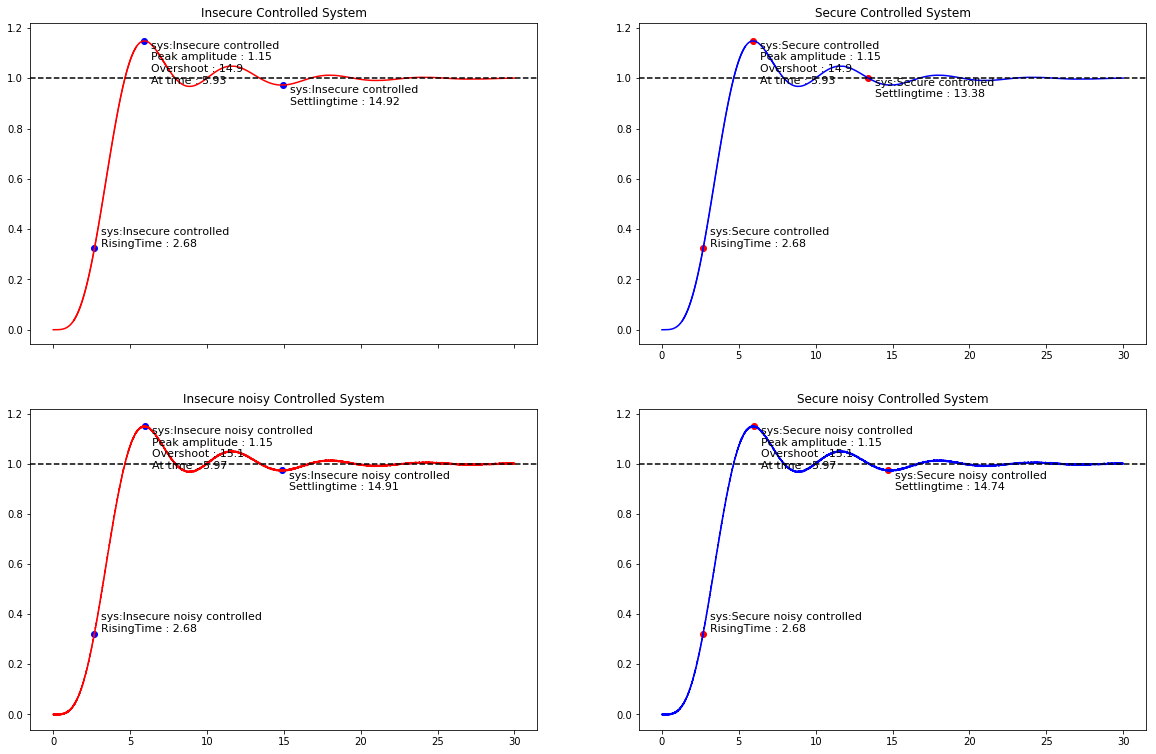

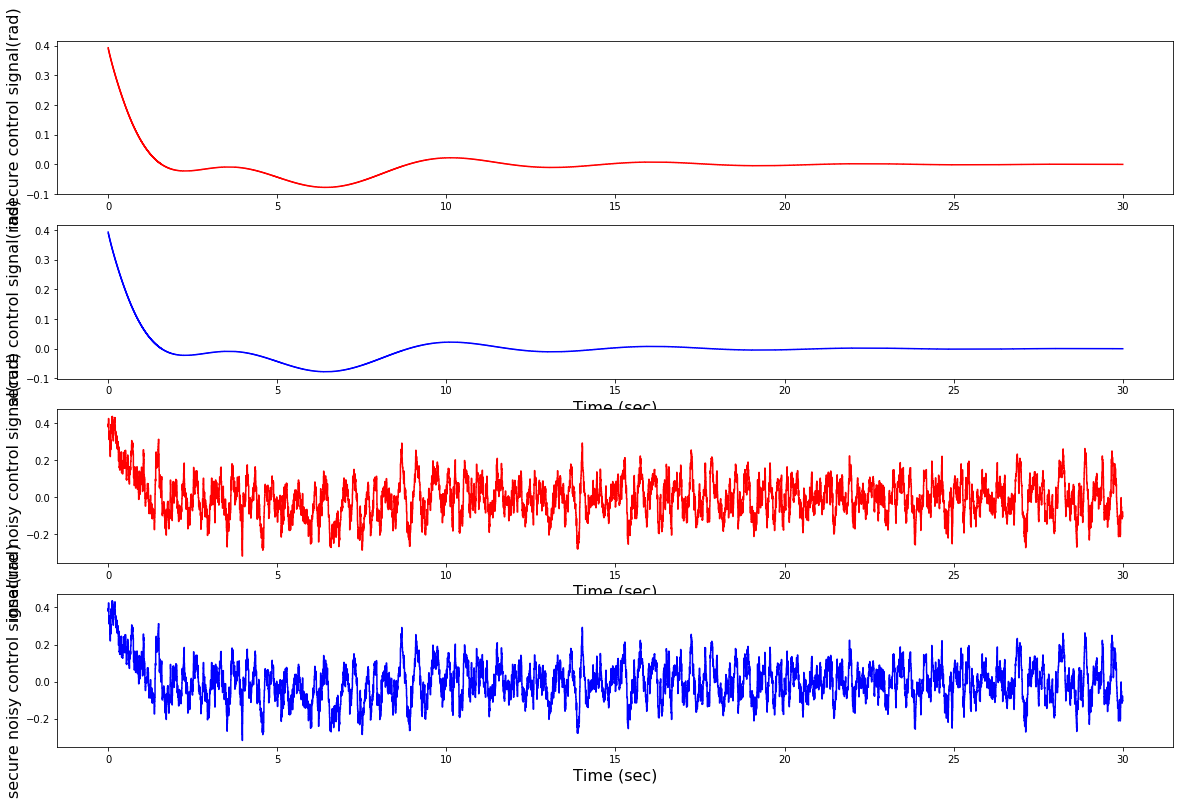

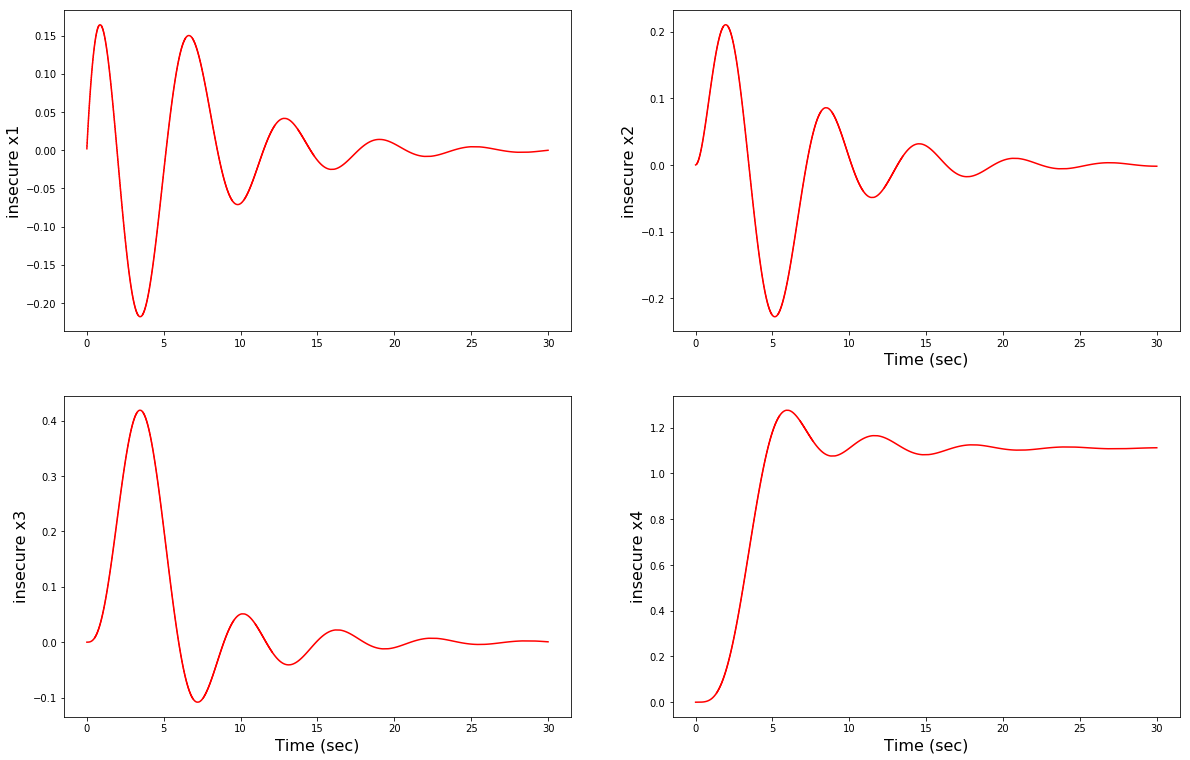

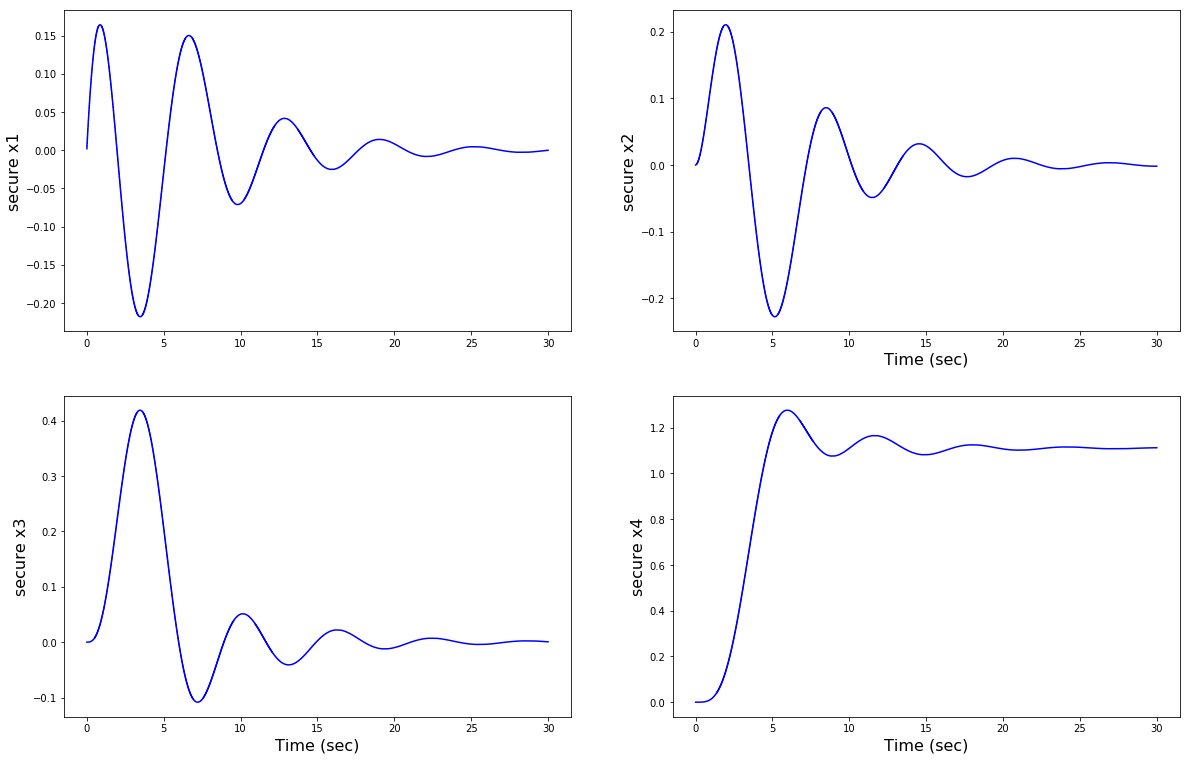

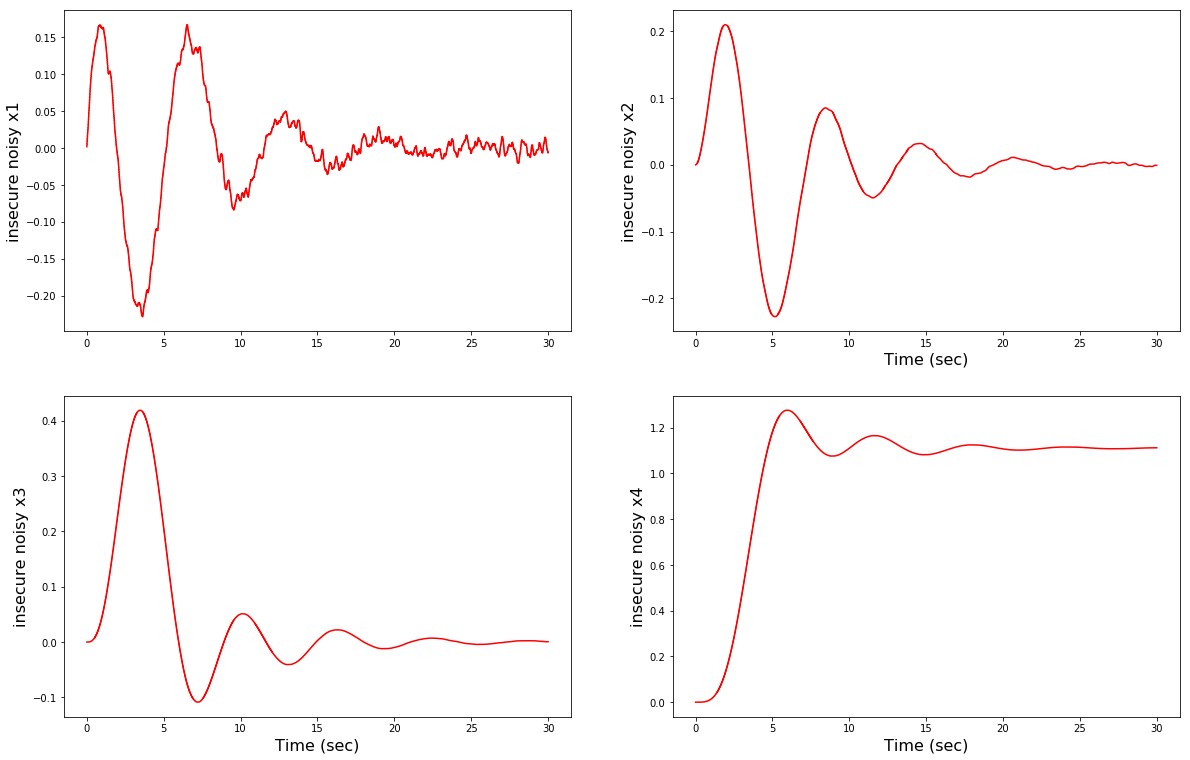

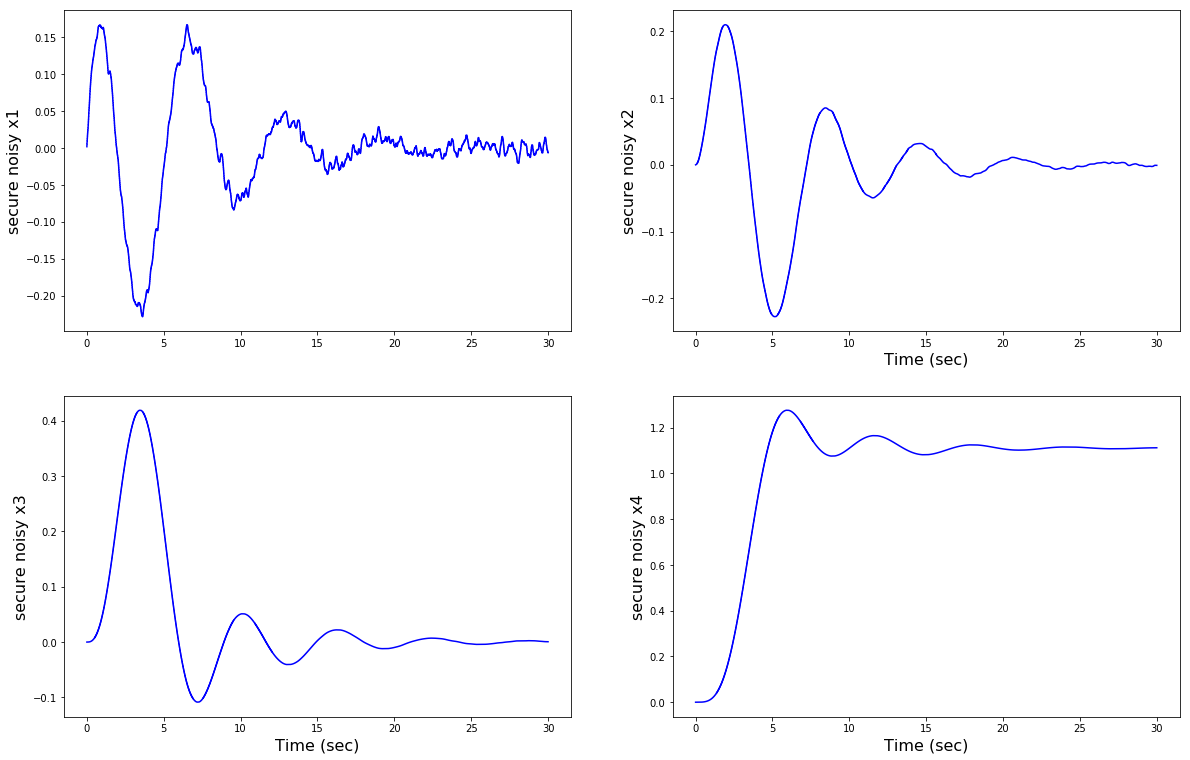

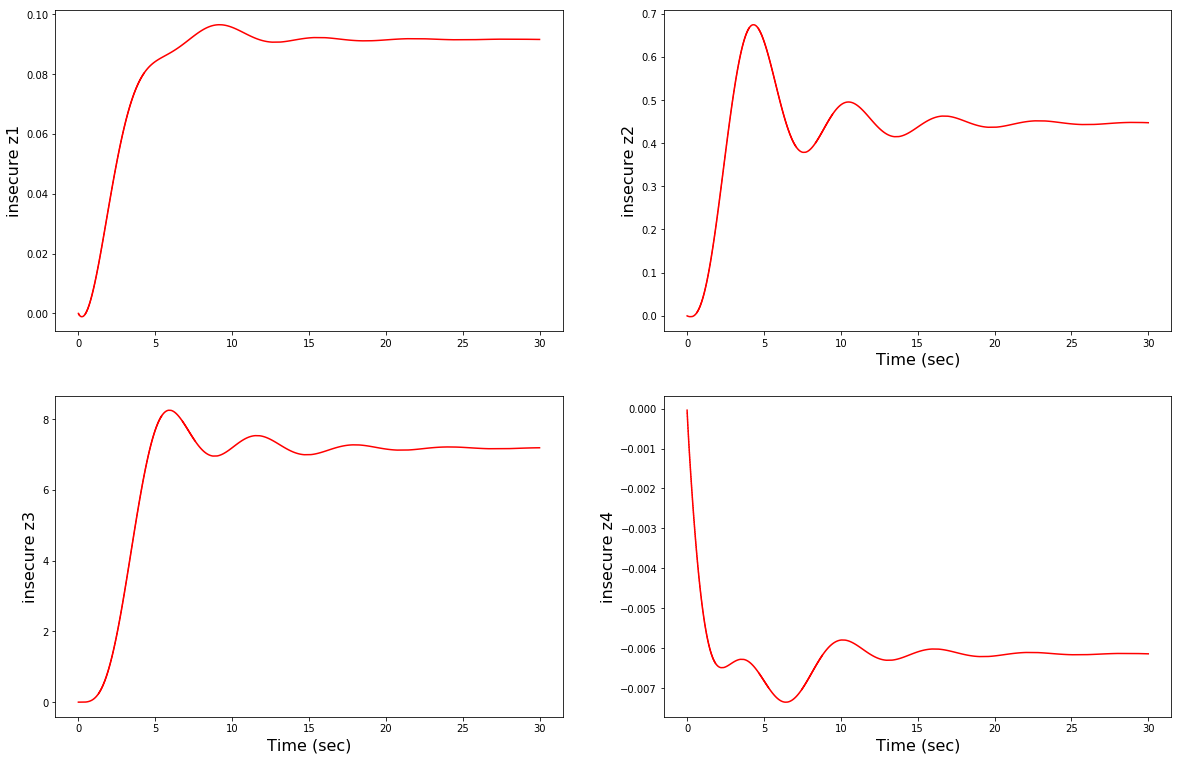

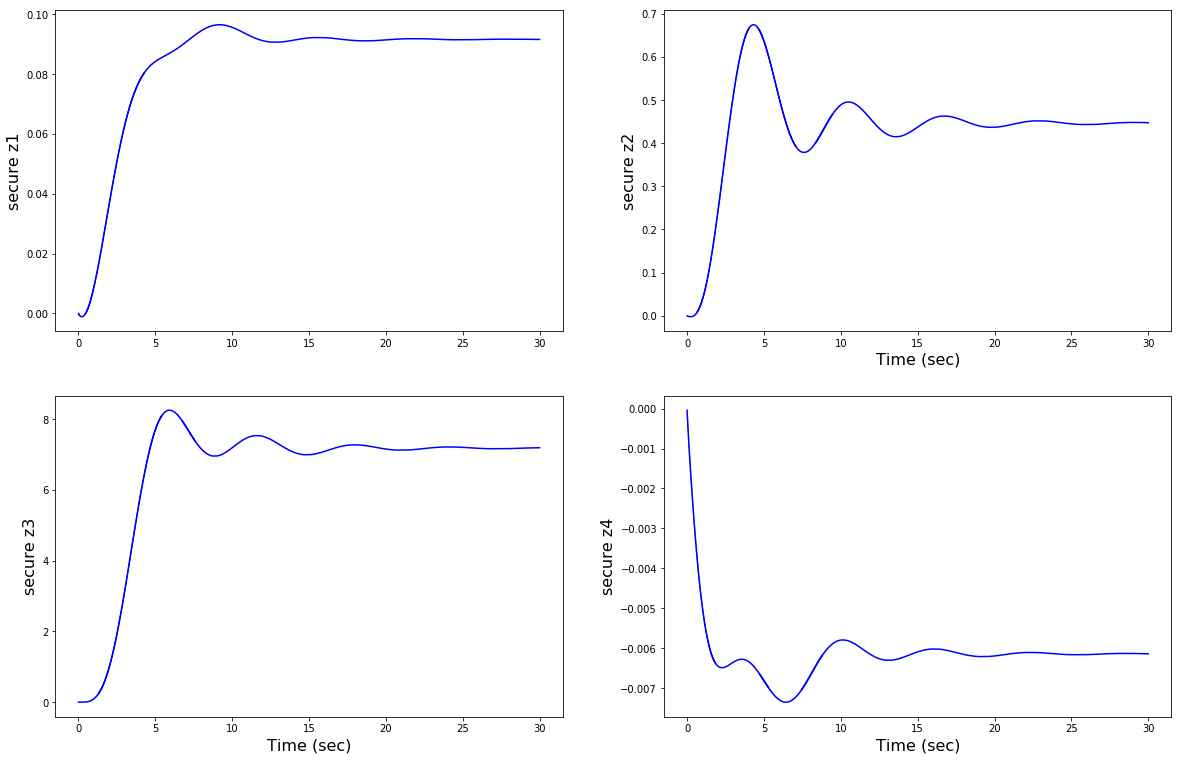

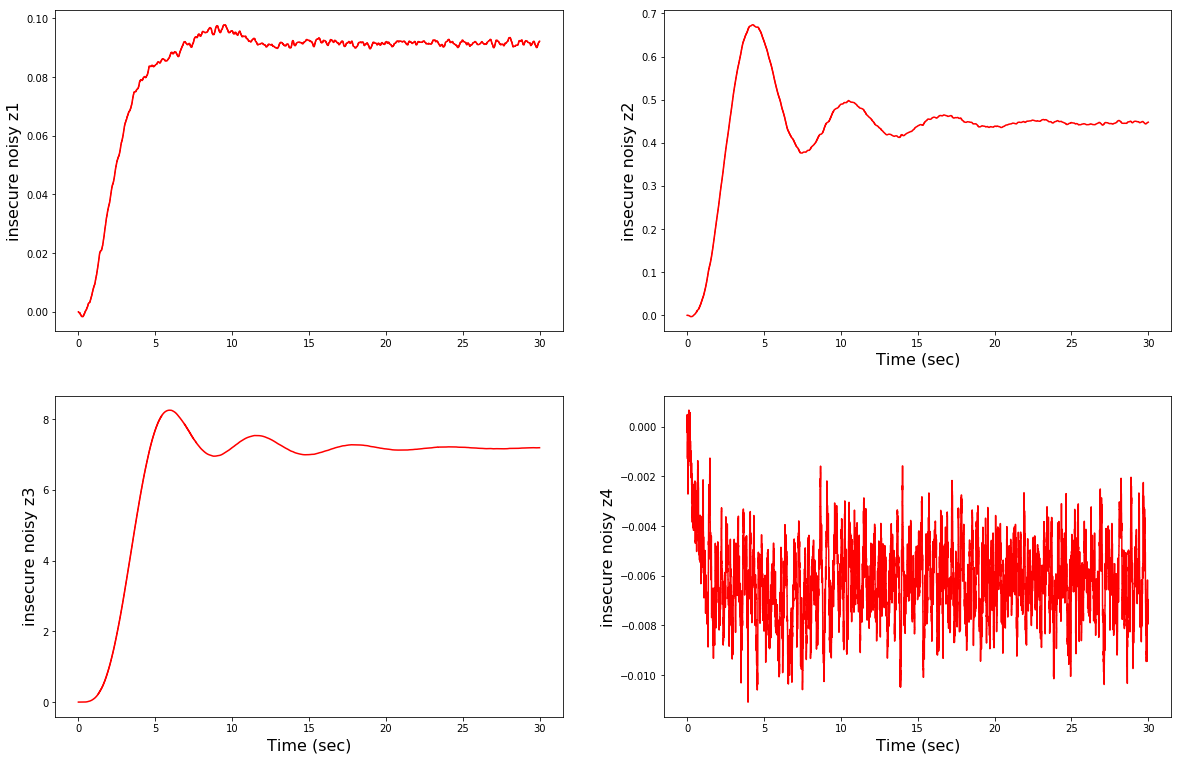

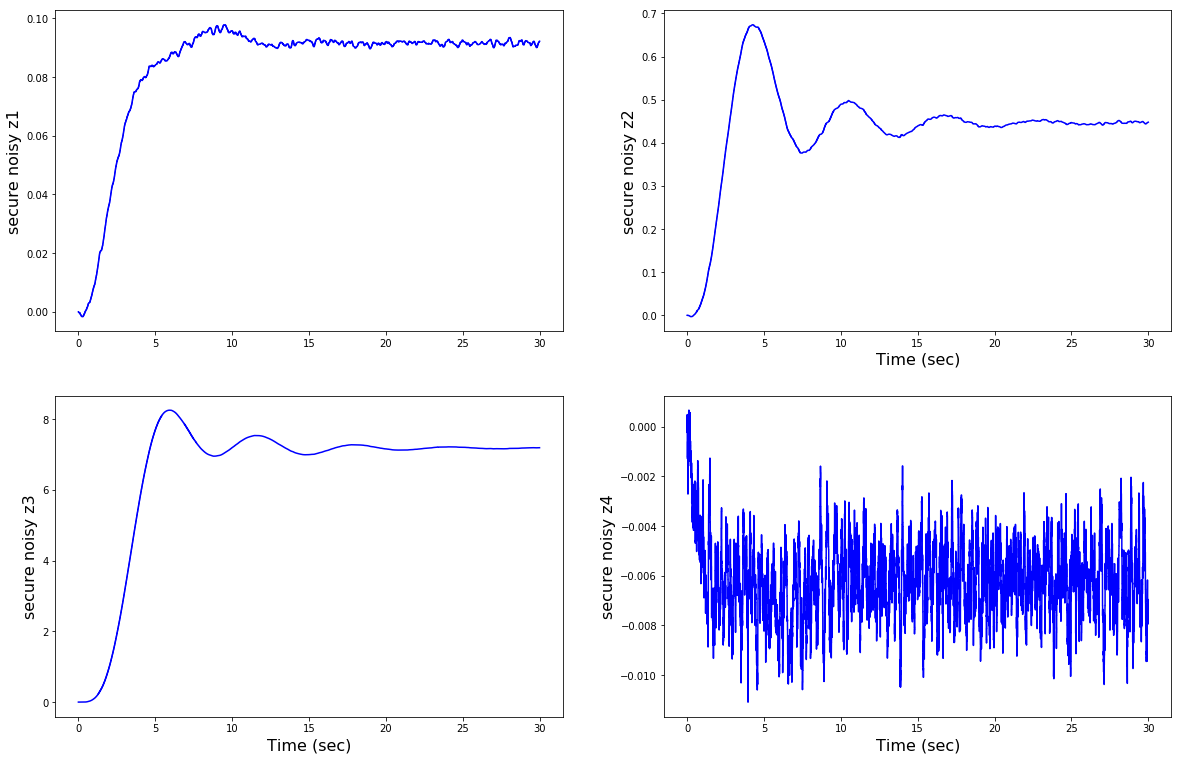

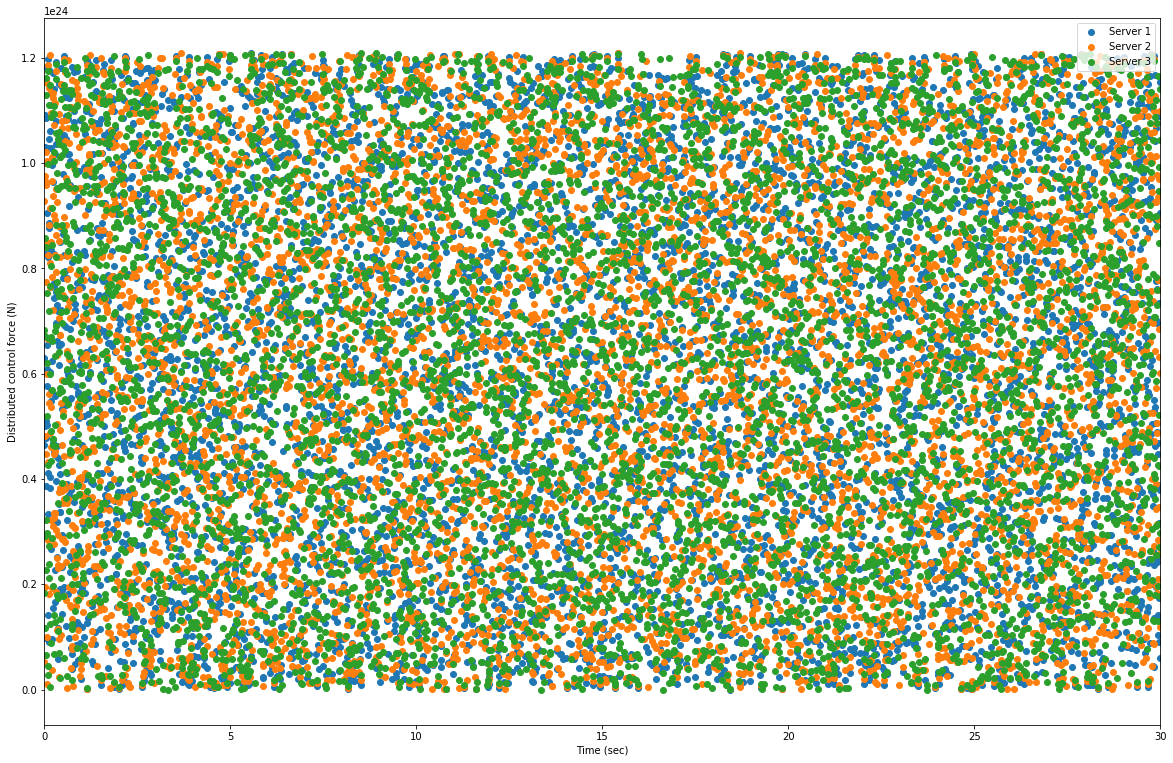

In [22]:
###############################################plots########################################
stepinfo=1
#insecure controlled sys
fig,axs = plt.subplots(2, 2)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0, 0].step(samples,Yc,color = 'red')
if stepinfo==True:
    axs[0, 0].scatter(contrising,f2cont(contrising),color = 'blue')
    axs[0, 0].scatter(contsettling,f2cont(contsettling),color = 'blue')
    axs[0, 0].text(contrising,f2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 0].text(contsettling,f2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Yc)>r:
        axs[0, 0].scatter(peaktime,peakamp,color = 'blue')
        axs[0, 0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0, 0].set_title('Insecure Controlled System')
axs[0, 0].axhline(y = r, color = 'black', linestyle = '--')
axs[0, 0].label_outer()

##insecure noisy controlled
axs[1, 0].step(samples,Ycn,color = 'red')
if stepinfo==True:
    axs[1, 0].scatter(contrisingn,f2ncont(contrisingn),color = 'blue')
    axs[1, 0].scatter(contsettlingn,f2ncont(contsettlingn),color = 'blue')
    axs[1, 0].text(contrisingn,f2ncont(contrisingn),
             '  sys:Insecure noisy controlled\n  RisingTime : {0}'
                   .format(round(contrisingn,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 0].text(contsettlingn,f2ncont(contsettlingn),
             '  sys:Insecure noisy controlled\n  Settlingtime : {0}'
                   .format(round(contsettlingn,2)),verticalalignment='top',fontsize=11)
    if max(Ycn)>r:
        axs[1, 0].scatter(peaktimen,peakampn,color = 'blue')
        axs[1, 0].text(peaktimen,peakampn,
             '  sys:Insecure noisy controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampn,overshootn,peaktimen),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1, 0].set_title('Insecure noisy Controlled System')
axs[1, 0].axhline(y = r, color = 'black', linestyle = '--')

###secure controlled

axs[0, 1].step(samples,Ycs,color = 'blue')
if stepinfo==True:
    axs[0, 1].scatter(scontrising,f2scont(scontrising),color = 'red')
    axs[0, 1].scatter(scontsettling,f2scont(scontsettling),color = 'red')
    axs[0, 1].text(scontrising,f2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 1].text(scontsettling,f2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycs)>r:
        axs[0, 1].scatter(peaktimes,peakamps,color = 'red')
        axs[0, 1].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0,1].set_title('Secure Controlled System')
axs[0, 1].axhline(y = r, color = 'black', linestyle = '--')

###secure noisy controlled

axs[1, 1].step(samples,Ycsn,color = 'blue')
if stepinfo==True:
    axs[1, 1].scatter(scontrisingn,f2sncont(scontrisingn),color = 'red')
    axs[1, 1].scatter(scontsettlingn,f2sncont(scontsettlingn),color = 'red')
    axs[1, 1].text(scontrisingn,f2sncont(scontrisingn),
             '  sys:Secure noisy controlled\n  RisingTime : {0}'
                   .format(round(scontrisingn,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 1].text(scontsettlingn,f2sncont(scontsettlingn),
             '  sys:Secure noisy controlled\n  Settlingtime : {0}'
                   .format(round(scontsettlingn,2)),verticalalignment='top',fontsize=11)
    if max(Ycsn)>r:
        axs[1, 1].scatter(peaktimesn,peakampsn,color = 'red')
        axs[1, 1].text(peaktimesn,peakampsn,
             '  sys:Secure noisy controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampsn,overshootsn,peaktimesn),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1,1].set_title('Secure noisy Controlled System')
axs[1, 1].axhline(y = r, color = 'black', linestyle = '--')


########## control signal #######
fig1,axs1 = plt.subplots(4, 1)
fig1.set_size_inches(20, 13, forward=True)
axs1[0].step(samples,U,color = 'red')
axs1[0].set_ylabel('insecure control signal(rad)',fontsize=16)

axs1[1].step(samples,Us_rec,color = 'blue')
axs1[1].set_ylabel('secure control signal(rad)',fontsize=16)
axs1[1].set_xlabel('Time (sec)',fontsize=16)

axs1[2].step(samples,Un,color = 'red')
axs1[2].set_ylabel('insecure noisy control signal(rad)',fontsize=16)
axs1[2].set_xlabel('Time (sec)',fontsize=16)

axs1[3].step(samples,Usn_rec,color = 'blue')
axs1[3].set_ylabel('secure noisy control signal(rad)',fontsize=16)
axs1[3].set_xlabel('Time (sec)',fontsize=16)

########## insecure plant states #######
fig2,axs2 = plt.subplots(2, 2)
fig2.set_size_inches(20, 13, forward=True)
axs2[0,0].step(samples,X1c,color = 'r')
axs2[0,0].set_ylabel('insecure x1',fontsize=16)

axs2[0,1].step(samples,X2c,color = 'r')
axs2[0,1].set_ylabel('insecure x2',fontsize=16)
axs2[0,1].set_xlabel('Time (sec)',fontsize=16)

axs2[1,0].step(samples,X3c,color = 'r')
axs2[1,0].set_ylabel('insecure x3',fontsize=16)
axs2[1,0].set_xlabel('Time (sec)',fontsize=16)

axs2[1,1].step(samples,X4c,color = 'r')
axs2[1,1].set_ylabel('insecure x4',fontsize=16)
axs2[1,1].set_xlabel('Time (sec)',fontsize=16)

########## secure plant states #######
fig3,axs3 = plt.subplots(2, 2)
fig3.set_size_inches(20, 13, forward=True)
axs3[0,0].step(samples,X1cs,color = 'b')
axs3[0,0].set_ylabel('secure x1',fontsize=16)

axs3[0,1].step(samples,X2cs,color = 'b')
axs3[0,1].set_ylabel('secure x2',fontsize=16)
axs3[0,1].set_xlabel('Time (sec)',fontsize=16)

axs3[1,0].step(samples,X3cs,color = 'b')
axs3[1,0].set_ylabel('secure x3',fontsize=16)
axs3[1,0].set_xlabel('Time (sec)',fontsize=16)

axs3[1,1].step(samples,X4cs,color = 'b')
axs3[1,1].set_ylabel('secure x4',fontsize=16)
axs3[1,1].set_xlabel('Time (sec)',fontsize=16)

########## insecure noisy plant states #######
fig4,axs4 = plt.subplots(2, 2)
fig4.set_size_inches(20, 13, forward=True)
axs4[0,0].step(samples,X1cn,color = 'r')
axs4[0,0].set_ylabel('insecure noisy x1',fontsize=16)

axs4[0,1].step(samples,X2cn,color = 'r')
axs4[0,1].set_ylabel('insecure noisy x2',fontsize=16)
axs4[0,1].set_xlabel('Time (sec)',fontsize=16)

axs4[1,0].step(samples,X3cn,color = 'r')
axs4[1,0].set_ylabel('insecure noisy x3',fontsize=16)
axs4[1,0].set_xlabel('Time (sec)',fontsize=16)

axs4[1,1].step(samples,X4cn,color = 'r')
axs4[1,1].set_ylabel('insecure noisy x4',fontsize=16)
axs4[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy secure plant states #######
fig5,axs5 = plt.subplots(2, 2)
fig5.set_size_inches(20, 13, forward=True)
axs5[0,0].step(samples,X1csn,color = 'b')
axs5[0,0].set_ylabel('secure noisy x1',fontsize=16)

axs5[0,1].step(samples,X2csn,color = 'b')
axs5[0,1].set_ylabel('secure noisy x2',fontsize=16)
axs5[0,1].set_xlabel('Time (sec)',fontsize=16)

axs5[1,0].step(samples,X3csn,color = 'b')
axs5[1,0].set_ylabel('secure noisy x3',fontsize=16)
axs5[1,0].set_xlabel('Time (sec)',fontsize=16)

axs5[1,1].step(samples,X4csn,color = 'b')
axs5[1,1].set_ylabel('secure noisy x4',fontsize=16)
axs5[1,1].set_xlabel('Time (sec)',fontsize=16)


########## insecure controller states #######
fig6,axs6 = plt.subplots(2, 2)
fig6.set_size_inches(20, 13, forward=True)
axs6[0,0].step(samples,Z1c,color = 'r')
axs6[0,0].set_ylabel('insecure z1',fontsize=16)

axs6[0,1].step(samples,Z2c,color = 'r')
axs6[0,1].set_ylabel('insecure z2',fontsize=16)
axs6[0,1].set_xlabel('Time (sec)',fontsize=16)

axs6[1,0].step(samples,Z3c,color = 'r')
axs6[1,0].set_ylabel('insecure z3',fontsize=16)
axs6[1,0].set_xlabel('Time (sec)',fontsize=16)

axs6[1,1].step(samples,Z4c,color = 'r')
axs6[1,1].set_ylabel('insecure z4',fontsize=16)
axs6[1,1].set_xlabel('Time (sec)',fontsize=16)

########## secure controller states #######
fig7,axs7 = plt.subplots(2, 2)
fig7.set_size_inches(20, 13, forward=True)
axs7[0,0].step(samples,Z1cs_rec,color = 'b')
axs7[0,0].set_ylabel('secure z1',fontsize=16)

axs7[0,1].step(samples,Z2cs_rec,color = 'b')
axs7[0,1].set_ylabel('secure z2',fontsize=16)
axs7[0,1].set_xlabel('Time (sec)',fontsize=16)

axs7[1,0].step(samples,Z3cs_rec,color = 'b')
axs7[1,0].set_ylabel('secure z3',fontsize=16)
axs7[1,0].set_xlabel('Time (sec)',fontsize=16)

axs7[1,1].step(samples,Z4cs_rec,color = 'b')
axs7[1,1].set_ylabel('secure z4',fontsize=16)
axs7[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy insecure controller states #######
fig8,axs8 = plt.subplots(2, 2)
fig8.set_size_inches(20, 13, forward=True)
axs8[0,0].step(samples,Z1cn,color = 'r')
axs8[0,0].set_ylabel('insecure noisy z1',fontsize=16)

axs8[0,1].step(samples,Z2cn,color = 'r')
axs8[0,1].set_ylabel('insecure noisy z2',fontsize=16)
axs8[0,1].set_xlabel('Time (sec)',fontsize=16)

axs8[1,0].step(samples,Z3cn,color = 'r')
axs8[1,0].set_ylabel('insecure noisy z3',fontsize=16)
axs8[1,0].set_xlabel('Time (sec)',fontsize=16)

axs8[1,1].step(samples,Z4cn,color = 'r')
axs8[1,1].set_ylabel('insecure noisy z4',fontsize=16)
axs8[1,1].set_xlabel('Time (sec)',fontsize=16)

########## noisy secure controller states #######
fig9,axs9 = plt.subplots(2, 2)
fig9.set_size_inches(20, 13, forward=True)
axs9[0,0].step(samples,Z1csn_rec,color = 'b')
axs9[0,0].set_ylabel('secure noisy z1',fontsize=16)

axs9[0,1].step(samples,Z2csn_rec,color = 'b')
axs9[0,1].set_ylabel('secure noisy z2',fontsize=16)
axs9[0,1].set_xlabel('Time (sec)',fontsize=16)

axs9[1,0].step(samples,Z3csn_rec,color = 'b')
axs9[1,0].set_ylabel('secure noisy z3',fontsize=16)
axs9[1,0].set_xlabel('Time (sec)',fontsize=16)

axs9[1,1].step(samples,Z4csn_rec,color = 'b')
axs9[1,1].set_ylabel('secure noisy z4',fontsize=16)
axs9[1,1].set_xlabel('Time (sec)',fontsize=16)


###########server control signal computation###########
fig10,axs10 = plt.subplots()
fig10.set_size_inches(20, 13, forward=True)
for i in range(server):
    axs10.scatter(samples,Us[:,i])
axs10.set_xlim(0,Tf)
axs10.set_ylabel('Distributed control force (N)')
axs10.set_xlabel('Time (sec)')
leg=[]
for i in range(server):
    leg.append('Server {0}'.format(str(i+1)))
axs10.legend(leg, loc='upper right')

field cardinality : 1125899906842679
running time of insecure controller: 0.0017015933990478516
running time of secure controller: 0.042539358139038086
running time of secure /running time of insecure : 24.999719770211573

UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

uncontrolled system constant time :4.5078125
uncontrolled system risingtime :9.9171875
uncontrolled system settlingtime :18.03125

INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Insecure controlled system constant time :5.222638003355236
Insecure controlled system risingtime :5.95841314431245
Insecure controlled system settlingtime :31.836494752527106
Insecure controlled system "peak amplitude :1.23" "overshoot :22.6" "At time :13.0"

SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS

Secure controlled system constant time :5.222652357098925
Secure controlled system risingtime :5.958563259175381
Secure controlled system settlingtime :31.839942278843463
Secure controlled system "peak amplitude :1.23" "

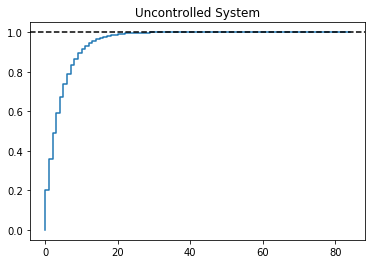

+--------------------------------------------+------------------------------+-----------------------------+
|                                            | Integral Absolute Error(IAE) | Integral Squared Error(ISE) |
+--------------------------------------------+------------------------------+-----------------------------+
|      b-w controlled System responses       |          6.974E-05           |          7.717E-09          |
|            b-w Control signals             |          9.863E-05           |          1.426E-08          |
|             b-w Error signals              |          6.074E-05           |          6.215E-09          |
| b-w controlled System responses with noise |          6.945E-05           |          6.143E-09          |
+--------------------------------------------+------------------------------+-----------------------------+


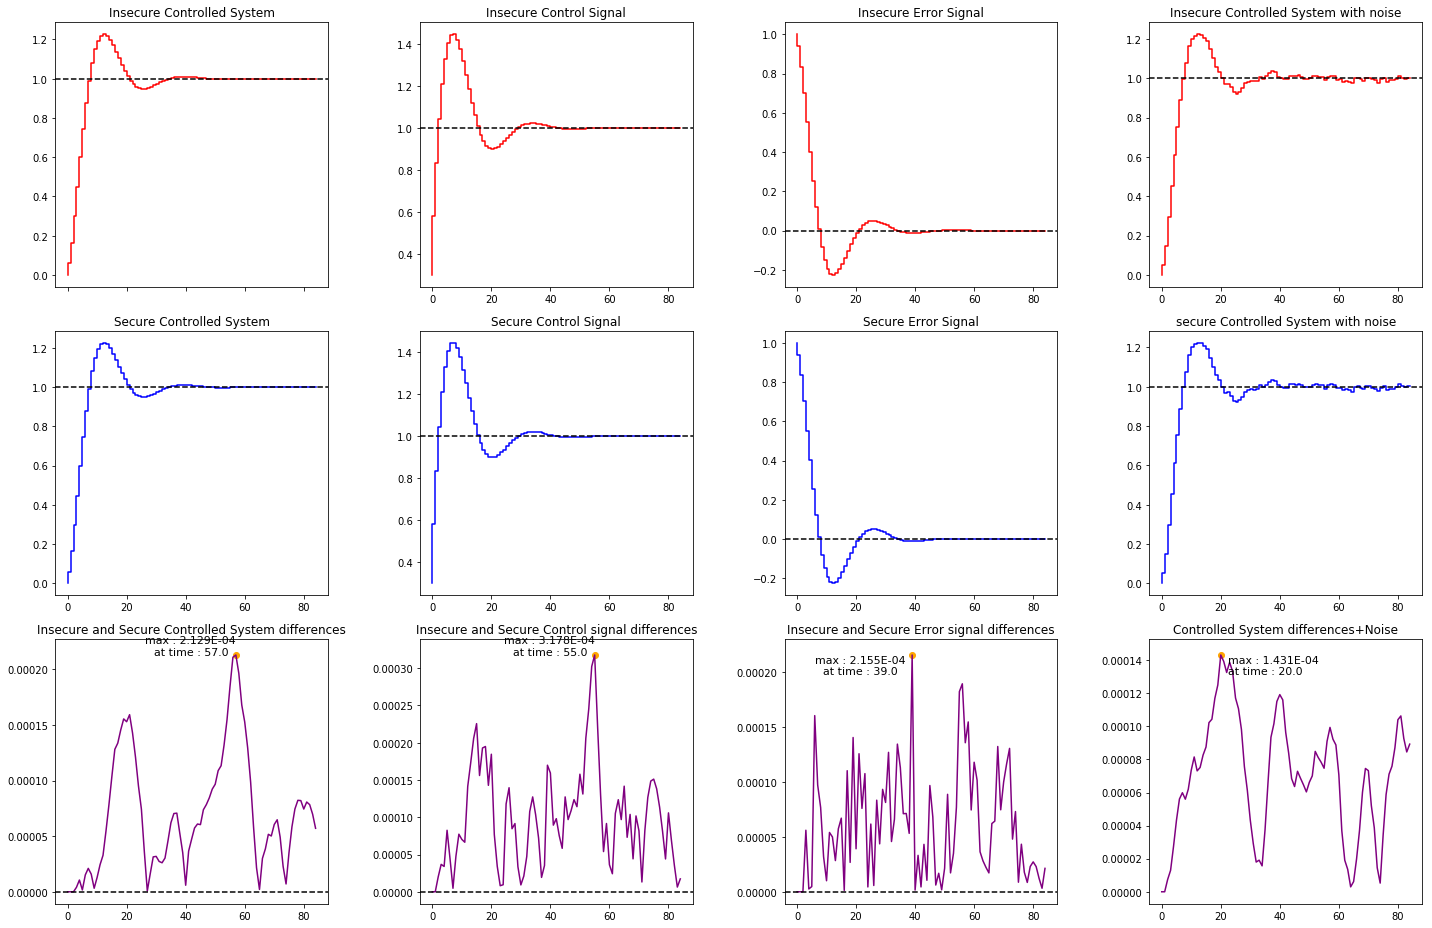

In [3]:
 ##using multiplication (ADDITION ACCURACY : SCALE,  MULT ACCURACY: SCALE/2)   ###########CONTROL###########+ rnd NOISE### coeff of e in u computing is publickly known
###
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal

#number of parties(servers) and finite field and number of samples
server=3 #set number of servers
t=1 #set shamir threshold
sampling=85
F=GF(next_prime(2^50))
scale=4 #MUST BE EVEN
print('field cardinality : {0}'.format(F.cardinality()))
mu=0  #Mean (“centre”) of the distribution
sigma=0.01 #Standard deviation (spread or “width”) of the distribution. Must be non-negative
#initial values
rk,ek,srk,sek,ekn,rkn,eksn,srkn=1,1,1,1,1,1,1,1
ycont,yuncont,ukminus1,yconts,yunconts,ukminus1s,ycontn,ukminus1n,ycontsn,ukminus1sn=0,0,0,0,0,0,0,0,0,0
insecureU,secureU,Yuncont,Ycont,YNcont,YNscont,Yscont,E,SE=[],[],[0],[0],[0],[0],[0],[],[]
noise=np.random.normal(mu,sigma,sampling)

#UNCONTROLLED SYSTEM
for i in range(sampling):
    yuncont=0.8*yuncont+0.2
    Yuncont.append(yuncont)
    
#INSECURE Cntrol    
tic=time.time()
for i in range(sampling):
    ek = rk-ycont
    uk = ukminus1 + 0.3*ek
    ycont=0.8*ycont + 0.2*uk 
    ukminus1 = uk
    Ycont.append(ycont)
    insecureU.append(uk)
    E.append(ek)
toc=time.time()

#INSECURE Cntrol+Noise    
for i in range(sampling):
    ekn = rkn-ycontn
    ukn = ukminus1n + 0.3*ekn
    ycontn=0.8*ycontn + 0.2*ukn + noise[i]
    ukminus1n = ukn
    YNcont.append(ycontn)


#SECURE Cntrol + Noise (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
#sharing initial value
ukminus1sn=sss.share(F,ukminus1sn,t,server,scale)
srkn=sss.share(F,srkn,t,server,scale)
ycontsn0=sss.share(F,-ycontsn,t,server,scale)
ecoeffn=sss.share(F,0.3,t,server,scale)
for i in range(sampling):
    #cloud computing part
    eksn =shamirproc.add(F,srkn,ycontsn0,t,server,scale)
    #control law (Computed by n servers)
    uksn = shamirproc.add(F,ukminus1sn,shamirproc.mult(F,ecoeffn,eksn,t,server,scale),t,server,scale)
    #center server computing part
    ycontsn=0.8*ycontsn+0.2*(sss.rec(F,uksn,r,scale)) + noise[i]
    ycontsn0=sss.share(F,-ycontsn,t,server,scale)
    ukminus1sn = uksn
    YNscont.append(ycontsn)


#SECURE Cntrol (sytem is controlled by parties securely)
r=sss.basispoly(F,server)
ukminus1s=sss.share(F,ukminus1s,t,server,scale)
srk=sss.share(F,srk,t,server,scale)
yconts0=sss.share(F,-yconts,t,server,scale)
ecoeff=sss.share(F,0.3,t,server,scale)
tics=time.time()
for i in range(sampling):
    eks =shamirproc.add(F,srk,yconts0,t,server,scale) 
    #control law (Computed by n servers)
    uks = shamirproc.add(F,ukminus1s,shamirproc.mult(F,ecoeff,eks,t,server,scale),t,server,scale) 
    yconts=0.8*yconts+0.2*(sss.rec(F,uks,r,scale))
    yconts0=sss.share(F,-yconts,t,server,scale)
    ukminus1s = uks
    Yscont.append(yconts)
    secureU.append(sss.rec(F,uks,r,scale))
    SE.append(sss.rec(F,eks,r,scale))
tocs=time.time()
print('running time of insecure controller: {0}'.format(toc-tic))
print('running time of secure controller: {0}'.format(tocs-tics))
print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))
Ycont.pop()
YNcont.pop()
Yscont.pop()
YNscont.pop()
Yuncont.pop()
srk=srkn=rk
#error will be very smaller in the end of secure case because secure conroller compute control signal up to 3 decimal places


samples=[]
for i in range(sampling):
    samples.append(i)

##UNCONTROLLED SYSTEM_STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'UNCONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
funcont = interp1d(Yuncont,samples) #interpolating time with respect to output values
f2uncont = interp1d(samples,Yuncont) #interpolating output values with respect to time
#stepresponse of sys
uncontau = funcont(0.632)
uncontrising=2.2*uncontau
uncontsettling=4*uncontau
tau=print('uncontrolled system constant time :{0}'.format(uncontau))
risingtime = print('uncontrolled system risingtime :{0}'.format(uncontrising)) 
settlingtime = print('uncontrolled system settlingtime :{0}'.format(uncontsettling))
if max(Yuncont)>rk:
    peakampun=round(max(Yuncont),2)
    overshootun=round(((max(Yuncont)-rk)/rk)*100,1)
    peaktimeun=round(funcont(max(Yuncont)),2)
    print('uncontrolled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakampun,overshootun,peaktimeun))

##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fcont = interp1d(Ycont,samples) 
f2cont=interp1d(samples,Ycont) 
#stepresponse of sys
contau = fcont(0.632*rk)
contrising = fcont(0.85*rk)-fcont(0.05*rk)
contsettling = fcont(0.98*rk)
tau=print('Insecure controlled system constant time :{0}'.format(contau))
risingtime = print('Insecure controlled system risingtime :{0}'.format(contrising)) 
settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
if max(Ycont)>rk:
    peakamp=round(max(Ycont),2)
    overshoot=round(((max(Ycont)-rk)/rk)*100,1)
    peaktime=round(fcont(max(Ycont)),2)
    print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamp,overshoot,peaktime))

##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
fscont = interp1d(Yscont,samples)
f2scont = interp1d(samples,Yscont)
#stepresponse of sys
scontau = fscont(0.632*srk)
scontrising = fscont(0.85*srk)-fscont(0.05*srk)
scontsettling = fscont(0.98*srk)
tau=print('Secure controlled system constant time :{0}'.format(scontau))
risingtime = print('Secure controlled system risingtime :{0}'.format(scontrising)) 
settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
if max(Yscont)>srk:
    peakamps=round(max(Yscont)/rk,2)
    overshoots=round(((max(Yscont)-rk)/rk)*100,1)
    peaktimes=round(fscont(max(Yscont)),2)
    print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
          .format(peakamps,overshoots,peaktimes))


stepinfo=0 ##### put in one if you want stepinfo######
#plots
#uncontrolled sys
plt.step(samples,Yuncont)
plt.rcParams["figure.figsize"] = (7,5)
plt.title('Uncontrolled System')
plt.axhline(y = 1, color = 'black', linestyle = '--')
if stepinfo==True:
    plt.scatter(uncontrising,f2uncont(uncontrising),color = 'blue')
    plt.scatter(uncontsettling,f2uncont(uncontsettling),color = 'blue')
    plt.text(uncontrising,f2uncont(uncontrising),
             '  sys:uncontrolled\n  RisingTime : {0}'.format(round(uncontrising,2))
             ,verticalalignment='top',fontsize=11)
    plt.text(uncontsettling,f2uncont(uncontsettling),
             '  sys:uncontrolled\n  Settlingtime : {0}'.format(round(uncontsettling,2))
             ,verticalalignment='top',fontsize=11)
    if max(Yuncont)>rk:
        plt.scatter(peaktimeun,peakampun,color = 'blue')
        plt.text(peaktimeun,peakampun,
             '  sys:uncontrolled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakampun,overshootun,peaktimeun),verticalalignment='top',fontsize=11) 
plt.show()

#insecure controlled sys
fig,axs = plt.subplots(3, 4)
fig.set_size_inches(20, 13, forward=True)
#fig.suptitle('Controlled System')
axs[0, 0].step(samples,Ycont,color = 'red')
if stepinfo==True:
    axs[0, 0].scatter(contrising,f2cont(contrising),color = 'blue')
    axs[0, 0].scatter(contsettling,f2cont(contsettling),color = 'blue')
    axs[0, 0].text(contrising,f2cont(contrising),
             '  sys:Insecure controlled\n  RisingTime : {0}'
                   .format(round(contrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[0, 0].text(contsettling,f2cont(contsettling),
             '  sys:Insecure controlled\n  Settlingtime : {0}'
                   .format(round(contsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[0, 0].scatter(peaktime,peakamp,color = 'blue')
        axs[0, 0].text(peaktime,peakamp,
             '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[0, 0].set_title('Insecure Controlled System')
axs[0, 0].axhline(y = rk, color = 'black', linestyle = '--')
axs[0, 0].label_outer()

#secure controlled sys
axs[1, 0].step(samples,Yscont,color = 'blue')
if stepinfo==True:
    axs[1, 0].scatter(scontrising,f2scont(scontrising),color = 'red')
    axs[1, 0].scatter(scontsettling,f2scont(scontsettling),color = 'red')
    axs[1, 0].text(scontrising,f2scont(scontrising),
             '  sys:Secure controlled\n  RisingTime : {0}'
                   .format(round(scontrising,2)),horizontalalignment='left'
                   ,verticalalignment='bottom',fontsize=11)
    axs[1, 0].text(scontsettling,f2scont(scontsettling),
             '  sys:Secure controlled\n  Settlingtime : {0}'
                   .format(round(scontsettling,2)),verticalalignment='top',fontsize=11)
    if max(Ycont)>rk:
        axs[1, 0].scatter(peaktimes,peakamps,color = 'red')
        axs[1, 0].text(peaktimes,peakamps,
             '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                 .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                       ,verticalalignment='top',fontsize=11)
axs[1, 0].set_title('Secure Controlled System')
axs[1, 0].axhline(y = rk, color = 'black', linestyle = '--')
#control signal
axs[0, 1].step([i for i in range(len(insecureU))],insecureU,color = 'red')
axs[0, 1].set_title('Insecure Control Signal')
axs[0, 1].axhline(y = rk, color = 'black', linestyle = '--')
axs[1, 1].step([i for i in range(len(secureU))],secureU,color = 'blue')
axs[1, 1].set_title('Secure Control Signal')
axs[1, 1].axhline(y = rk, color = 'black', linestyle = '--')
#Error signal
axs[0, 2].step([i for i in range(len(E))],E,color = 'red')
axs[0, 2].set_title('Insecure Error Signal')
axs[0, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[1, 2].step([i for i in range(len(SE))],SE,color = 'blue')
axs[1, 2].set_title('Secure Error Signal')
axs[1, 2].axhline(y = 0, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference
Ydiffrence=abs(np.array(Yscont)-np.array(Ycont))
fYdiff=interp1d(Ydiffrence,samples) 
axs[2, 0].plot(samples,Ydiffrence,color = 'purple')
axs[2, 0].set_title('Insecure and Secure Controlled System differences')
axs[2, 0].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 0].scatter(fYdiff(max(Ydiffrence)),max(Ydiffrence),color = 'orange')
axs[2, 0].text(fYdiff(max(Ydiffrence)),max(Ydiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Ydiffrence)))
            ,fYdiff(max(Ydiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 0].set_ylim([0, 0.0012])

#Insecure and Secure Control signal difference
Udiffrence=abs(np.array(secureU)-np.array(insecureU))
fUdiff=interp1d(Udiffrence,samples) 
axs[2, 1].plot(samples,abs(np.array(secureU)-np.array(insecureU)),color = 'purple')
axs[2, 1].set_title('Insecure and Secure Control signal differences')
axs[2, 1].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 1].scatter(fUdiff(max(Udiffrence)),max(Udiffrence),color = 'orange')
axs[2, 1].text(fUdiff(max(Udiffrence)),max(Udiffrence),
            '  max : {0}\n  at time : {1}  '.format('%.3E' % Decimal(str(max(Udiffrence)))
            ,fUdiff(max(Udiffrence))),horizontalalignment='right',fontsize=11)
#axs[2, 1].set_ylim([0, 0.0012])

#Insecure and Secure Error signal difference
Ediffrence=abs(np.array(SE)-np.array(E))
fEdiff=interp1d(Ediffrence,samples)
axs[2, 2].plot(samples,abs(np.array(SE)-np.array(E)),color = 'purple')
axs[2, 2].set_title('Insecure and Secure Error signal differences')
axs[2, 2].axhline(y = 0, color = 'black', linestyle = '--')
axs[2, 2].scatter(fEdiff(max(Ediffrence)),max(Ediffrence),color = 'orange')
axs[2,2].text(fEdiff(max(Ediffrence)),max(Ediffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(Ediffrence)))
            ,fEdiff(max(Ediffrence))),horizontalalignment='right' ,verticalalignment='top',fontsize=11)
#axs[2, 2].set_ylim([0, 0.0012])

#insecure controlled sys+Noise
axs[0, 3].step(samples,YNcont,color = 'red')
axs[0, 3].set_title('Insecure Controlled System with noise')
axs[0, 3].axhline(y = rkn, color = 'black', linestyle = '--')

#secure controlled sys+Noise
axs[1, 3].step(samples,YNscont,color = 'blue')
axs[1, 3].set_title('secure Controlled System with noise')
axs[1, 3].axhline(y = srkn, color = 'black', linestyle = '--')

#Insecure and Secure Controlled System difference + noise
YNdiffrence=abs(np.array(YNcont)-np.array(YNscont))
fYNdiff=interp1d(YNdiffrence,samples)
axs[2, 3].plot(samples,abs(np.array(YNcont)-np.array(YNscont)),color = 'purple')
axs[2, 3].set_title('Controlled System differences+Noise')
axs[2, 3].scatter(fYNdiff(max(YNdiffrence)),max(YNdiffrence),color = 'orange')
axs[2,3].text(fYNdiff(max(YNdiffrence)),max(YNdiffrence),
            '  max : {0}  \n  at time : {1}    '.format('%.3E' % Decimal(str(max(YNdiffrence)))
            , fYNdiff(max(YNdiffrence))),horizontalalignment='left' ,verticalalignment='top',fontsize=11)
#axs[2, 3].set_ylim([0, 0.0012])

fig.tight_layout()
#table of defferences
sY=0
for i in Ydiffrence:
    sY+=i**2
IAEY= '%.3E' % Decimal(str(sum(Ydiffrence)/sampling))
ISEY= '%.3E' % Decimal(str(sY/sampling))
    
sU=0
for i in Udiffrence:
    sU+=i**2
IAEU= '%.3E' % Decimal(str(sum(Udiffrence)/sampling))
ISEU= '%.3E' % Decimal(str(sU/sampling))
                       
sE=0
for i in Ediffrence:
    sE+=i**2
IAEE= '%.3E' % Decimal(str(sum(Ediffrence)/sampling))
ISEE= '%.3E' % Decimal(str(sE/sampling))

sYN=0
for i in YNdiffrence:
    sYN+=i**2
IAEYN= '%.3E' % Decimal(str(sum(YNdiffrence)/sampling)) 
ISEYN= '%.3E' % Decimal(str(sYN/sampling)) 

table = [["b-w controlled System responses",IAEY,ISEY]
         ,["b-w Control signals ",IAEU,ISEU]
         ,["b-w Error signals",IAEE,ISEE]
         ,["b-w controlled System responses with noise",IAEYN,ISEYN]]

headers = ['',"Integral Absolute Error(IAE)", "Integral Squared Error(ISE)"]

print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))




In [16]:
print('\n\033[1m'+'Control signal Comparison\n'+'\033[0m')
for i,j in zip(insecureU,secureU):
   print('(insecureU,secureU) = ({0},{1})'.format(i,j))

print('\n\033[1m'+'Error signal Comparison\n'+'\033[0m')
for i,j in zip(E,SE):
   print('(insecureE,secureE) = ({0},{1})'.format(i,j))


Control signal Comparison

(insecureU,secureU) = (0.300000000000000,0.3)
(insecureU,secureU) = (0.582000000000000,0.582)
(insecureU,secureU) = (0.832680000000000,0.8327)
(insecureU,secureU) = (1.04326320000000,1.0433)
(insecureU,secureU) = (1.20913396800000,1.2092)
(insecureU,secureU) = (1.32928254432000,1.3294)
(insecureU,secureU) = (1.40564445271680,1.4058)
(insecureU,secureU) = (1.44239531227123,1.4425)
(insecureU,secureU) = (1.44525228117850,1.4453)
(insecureU,secureU) = (1.42082271943361,1.4209)
(insecureU,secureU) = (1.37602970687168,1.3761)
(insecureU,secureU) = (1.31763351440983,1.3177)
(insecureU,secureU) = (1.25185854957577,1.2519)
(insecureU,secureU) = (1.18412706473397,1.1842)
(insecureU,secureU) = (1.11889425297649,1.1189)
(insecureU,secureU) = (1.05957434839192,1.0596)
(insecureU,secureU) = (1.00854396382075,1.0086)
(insecureU,secureU) = (0.967207018334564,0.9673)
(insecureU,secureU) = (0.936105040845544,0.9362)
(insecureU,secureU) = (0.915057156403595,0.9151)
(insecureU

In [49]:
import time
import numpy as np
from shamirproc import *
import shamirscheme as sss
from matplotlib import pyplot as plt


F=GF(next_prime(2^64)) #finite field
server=3 # number of computing servers
t=1 #shamir threshold 
scale=9 # A/D and D/A Accuracy

rec=sss.basispoly(F,server)
a=sss.share(F,2.532322222222222444444444,t,server,scale)
b=sss.R2F(F,5.2323222222255555555,scale)
us=mult(F,a,b,t,server,scale)#a*b
us=sss.rec(F,us,rec,scale)
us

13.249925835

In [14]:
a=sss.share(F,2.5323,t,server,scale)
us=sss.rec(F,-a,rec,scale)


array([597561857718849971, 1220446715437699946, 1843331573156549921],
      dtype=object)

In [ ]:
rs=sss.share(F,r,t,server,scale)
x1csn,x2csn,x3csn,x4csn,ycsn,usn,usn_rec=0,0,0,0,0,0,0
x1csn=[0]
x2csn=[0]
x3csn=[0]
x4csn=[0]
ycsn=[0]
usn_rec=[]

ucsn=sss.share(F,0,t,server,scale)
z1csn=sss.share(F,0,t,server,scale)
z2csn=sss.share(F,0,t,server,scale)
z3csn=sss.share(F,0,t,server,scale)
z4csn=sss.share(F,0,t,server,scale)

z1csn=[z1csn]
z2csn=[z2csn]
z3csn=[z3csn]
z4csn=[z4csn]
ucsn=[ucsn]

#sss.R2F(F,5.2323,scale)

Ac11n=sss.R2F(F,1,scale)
Ac12n=sss.R2F(F,-1.27e-05,scale)
Ac13n=sss.R2F(F,-0.0009439,scale)
Ac14n=sss.R2F(F,-0.02316,scale)

Ac21n=sss.R2F(F,0.04,scale)
Ac22n=sss.R2F(F,1,scale)
Ac23n=sss.R2F(F,-0.002388,scale)
Ac24n=sss.R2F(F,-0.05874,scale)

Ac31n=sss.R2F(F,0.0007996,scale)
Ac32n=sss.R2F(F,+0.03996,scale)
Ac33n=sss.R2F(F,0.997,scale)
Ac34n=sss.R2F(F,-0.0733,scale)

Ac41n=sss.R2F(F,2.075e-05,scale)
Ac42n=sss.R2F(F,0.001542,scale)
Ac43n=sss.R2F(F,0.07567,scale)
Ac44n=sss.R2F(F,0.8928,scale)

Bc11n=sss.R2F(F,-0.0001303,scale)    
Bc12n=sss.R2F(F,+0.006641,scale)

Bc21n=sss.R2F(F,-0.0001813,scale)
Bc22n=sss.R2F(F,+0.01312,scale)

Bc31n=sss.R2F(F,-0.0001282,scale)
Bc32n=sss.R2F(F,+0.003186,scale)

Bc41n=sss.R2F(F,-9.078e-05,scale)
Bc42n=sss.R2F(F,-0.5447,scale)

Cc14n=sss.R2F(F,64,scale)

#Ac11n=sss.share(F,1,t,server,scale)
#Ac12n=sss.share(F,-1.27e-05,t,server,scale)
#Ac13n=sss.share(F,-0.0009439,t,server,scale)
#Ac14n=sss.share(F,-0.02316,t,server,scale)

#Ac21n=sss.share(F,0.04,t,server,scale)
#Ac22n=sss.share(F,1,t,server,scale)
#Ac23n=sss.share(F,-0.002388,t,server,scale)
#Ac24n=sss.share(F,-0.05874,t,server,scale)

#Ac31n=sss.share(F,0.0007996,t,server,scale)
#Ac32n=sss.share(F,+0.03996,t,server,scale)
#Ac33n=sss.share(F,0.997,t,server,scale)
#Ac34n=sss.share(F,-0.0733,t,server,scale)

#Ac41n=sss.share(F,2.075e-05,t,server,scale)
#Ac42n=sss.share(F,0.001542,t,server,scale)
#Ac43n=sss.share(F,0.07567,t,server,scale)
#Ac44n=sss.share(F,0.8928,t,server,scale)

#Bc11n=sss.share(F,-0.0001303,t,server,scale)   
#Bc12n=sss.share(F,+0.006641,t,server,scale)

#Bc21n=sss.share(F,-0.0001813,t,server,scale)
#Bc22n=sss.share(F,+0.01312,t,server,scale)

#Bc31n=sss.share(F,-0.0001282,t,server,scale)
#Bc32n=sss.share(F,+0.003186,t,server,scale)

#Bc41n=sss.share(F,-9.078e-05,t,server,scale)
#Bc42n=sss.share(F,-0.5447,t,server,scale)

#Cc14n=sss.share(F,64,t,server,scale)



krs=sss.share(F,0.3933,t,server,scale)
rec=sss.basispoly(F,server)

for i in range(1,samp):
    usn=shamirproc.add(F,shamirproc.mult(F,rs,krs,t,server,scale),ucsn,t,server,scale)
    usn_rec=sss.rec(F,usn,rec,scale)
    usn_rec.append(usn_rec)
    x1csn=0.9998*x1csn-0.004999*x2csn+0.004999*usn_rec
    x2csn=0.004999*x1csn+1*x2csn+1.25e-05*usn_rec
    x3csn=1.25e-05*x1csn+0.005*x2csn+1*x3csn+2.083e-08*usn_rec
    x4csn=2.083e-08*x1csn+1.25e-05*x2csn+0.005*x3csn+1*x4csn+2.604e-11*usn_rec
    ycsn=0.036*x3csn+0.9*x4csn
    ycsn.append(ycsn)
    ycsn=sss.share(F,ycsn,t,server,scale)

    mul11n=shamirproc.mult(F,Ac11n,z1csn,t,server,scale)
    mul12n=shamirproc.mult(F,Ac12n,z2csn,t,server,scale)
    mul13n=shamirproc.mult(F,Ac13n,z3csn,t,server,scale)
    mul14n=shamirproc.mult(F,Ac14n,z4csn,t,server,scale)
    mul15n=shamirproc.mult(F,Bc11n,usn,t,server,scale)
    mul16n=shamirproc.mult(F,Bc12n,ycsn,t,server,scale)
    
    z1csn = shamirproc.add(F,
         shamirproc.add(F,
         shamirproc.add(F,
        shamirproc.add(F,
        shamirproc.add(F,mul11n,mul12n,t,server,scale),mul13n,t,server,scale),mul14n,t,server,scale),mul15n,t,server,scale),mul16n,t,server,scale)

    mul21n=shamirproc.mult(F,Ac21n,z1csn,t,server,scale)
    mul22n=shamirproc.mult(F,Ac22n,z2csn,t,server,scale)
    mul23n=shamirproc.mult(F,Ac23n,z3csn,t,server,scale)
    mul24n=shamirproc.mult(F,Ac24n,z4csn,t,server,scale)
    mul25n=shamirproc.mult(F,Bc21n,usn,t,server,scale)
    mul26n=shamirproc.mult(F,Bc22n,ycsn,t,server,scale)
    
    z2csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul21n,mul22n,t,server,scale),mul23n,t,server,scale),mul24n,t,server,scale),mul25n,t,server,scale),mul26n,t,server,scale)
    
    mul31n=shamirproc.mult(F,Ac31n,z1csn,t,server,scale)
    mul32n=shamirproc.mult(F,Ac32n,z2csn,t,server,scale)
    mul33n=shamirproc.mult(F,Ac33n,z3csn,t,server,scale)
    mul34n=shamirproc.mult(F,Ac34n,z4csn,t,server,scale)
    mul35n=shamirproc.mult(F,Bc31n,usn,t,server,scale)
    mul36n=shamirproc.mult(F,Bc32n,ycsn,t,server,scale)
    
    z3csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul31n,mul32n,t,server,scale),mul33n,t,server,scale),mul34n,t,server,scale),mul35n,t,server,scale),mul36n,t,server,scale)    

    mul41n=shamirproc.mult(F,Ac41n,z1csn,t,server,scale)
    mul42n=shamirproc.mult(F,Ac42n,z2csn,t,server,scale)
    mul43n=shamirproc.mult(F,Ac43n,z3csn,t,server,scale)
    mul44n=shamirproc.mult(F,Ac44n,z4csn,t,server,scale)
    mul45n=shamirproc.mult(F,Bc41n,usn,t,server,scale)
    mul46n=shamirproc.mult(F,Bc42n,ycsn,t,server,scale)
    
    z4csn = shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,
           shamirproc.add(F,mul41n,mul42n,t,server,scale),mul43n,t,server,scale),mul44n,t,server,scale),mul45n,t,server,scale),mul46n,t,server,scale)    
    ucsn=shamirproc.mult(F,Cc14n,z4csn,t,server,scale)

ycsn.pop(0)

In [29]:
                         ## controlled
                         ########SATELLITE#######
                            ##T=0.1
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
from scipy.io import savemat

def control(r,Tf,F,server,t,stepinfo,kp,kd,scale,sigma):
    
    #initial values
    theta2=0
    theta2dot,theta1,theta1dot=0,0,0
    Theta2=[0]
    Theta2dot=[0]
    Theta1=[0]
    Theta1dot=[0]
    u=0
    dt=0.1
    samp=Tf/dt
    samp=int(samp)
    samples=np.linspace(0,Tf, num=samp)
    noise=np.random.normal(0,sigma,samp)


    #UNCONTROLLED SYSTEM
    for i in range(1,samp):

        theta2=0.995459788246996*theta2+0.099668946382836*theta2dot+0.004540211753004*theta1+0.000331053617164*theta1dot+0.000009778468527*u
        theta2dot=-0.090668615329219*theta2+0.991872897970236*theta2dot+0.090668615329219*theta1+0.008127102029764*theta1dot+0.000331053617164*u
        theta1=0.000454021175300*theta2+0.000033105361716*theta2dot+0.999545978824700*theta1+0.099966894638284*theta1dot+0.004999022153147*u
        theta1dot=0.009066861532922*theta2+0.000812710202976*theta2dot-0.009066861532922*theta1+0.999187289797024*theta1dot+0.099966894638284*u
        Theta2.append(theta2)
        Theta2dot.append(theta2dot)
        Theta1.append(theta1)
        Theta1dot.append(theta1dot)



    ## #######################Insecure control system#####################
    r=r
    theta2c=0
    theta2cdot,theta1c,theta1cdot=0,0,0
    Theta2c=[0]
    Theta2cdot=[0]
    Theta1c=[0]
    U_c=[]
    Theta1cdot=[0]
    e,u_pd,u_n=0,0,0
    U_pd=[0]
    U_n=[0]
    error=[0]

    tic=time.time()
    #CONTROLLED SYSTEM
    for i in range(1,samp):
        e=r-theta2c
        u_pd=kp*e+kd*(error[i-2]-4*error[i-1]+3*e)/(2*dt)
        if len(U_n)>1:
            u_n=0.4785*U_n[i-1]-0.006738*U_n[i-2]+125.5*u_pd-250*U_pd[i-1]+125.5*U_pd[i-2]
        else:
            u_n=0.4785*U_n[i-1]+125.5*u_pd-250*U_pd[i-1]
        u_c=u_n
        theta2c=0.995459788246996*theta2c+0.099668946382836*theta2cdot+0.004540211753004*theta1c+0.000331053617164*theta1cdot+0.000009778468527*u_c
        theta2cdot=-0.090668615329219*theta2c+0.991872897970236*theta2cdot+0.090668615329219*theta1c+0.008127102029764*theta1cdot+0.000331053617164*u_c
        theta1c=0.000454021175300*theta2c+0.000033105361716*theta2cdot+0.999545978824700*theta1c+0.099966894638284*theta1cdot+0.004999022153147*u_c
        theta1cdot=0.009066861532922*theta2c+0.000812710202976*theta2cdot-0.009066861532922*theta1c+0.999187289797024*theta1cdot+0.099966894638284*u_c
        U_n.append(u_n)
        U_pd.append(u_pd)
        U_c.append(u_c)
        error.append(e)
        Theta2c.append(theta2c)
        Theta2cdot.append(theta2cdot)
        Theta1c.append(theta1c)
        Theta1cdot.append(theta1cdot)
    toc=time.time()

    ###################### Insecure Noisy control system #######################
    theta2cn=0
    theta2cndot,theta1cn,theta1cndot=0,0,0
    Theta2cn=[0]
    Theta2cndot=[0]
    Theta1cn=[0]
    U_cn=[]
    Theta1cndot=[0]
    en,un_pd,un_n=0,0,0
    Un_pd=[0]
    Un_n=[0]
    errorn=[0]

    #CONTROLLED SYSTEM
    for i in range(1,samp):
        en=r-theta2cn
        un_pd=kp*en+kd*(errorn[i-2]-4*errorn[i-1]+3*en)/(2*dt)
        if len(U_n)>1:
            un_n=0.4785*Un_n[i-1]-0.006738*Un_n[i-2]+125.5*un_pd-250*Un_pd[i-1]+125.5*Un_pd[i-2]
        else:
            un_n=0.4785*Un_n[i-1]+125.5*un_pd-250*Un_pd[i-1]
        un_c=un_n
        theta2cn=0.995459788246996*theta2cn+0.099668946382836*theta2cndot+0.004540211753004*theta1cn+0.000331053617164*theta1cndot+0.000009778468527*un_c+noise[i]
        theta2cndot=-0.090668615329219*theta2cn+0.991872897970236*theta2cndot+0.090668615329219*theta1cn+0.008127102029764*theta1cndot+0.000331053617164*un_c
        theta1cn=0.000454021175300*theta2cn+0.000033105361716*theta2cndot+0.999545978824700*theta1cn+0.099966894638284*theta1cndot+0.004999022153147*un_c
        theta1cndot=0.009066861532922*theta2cn+0.000812710202976*theta2cndot-0.009066861532922*theta1cn+0.999187289797024*theta1cndot+0.099966894638284*un_c
        Un_n.append(un_n)
        Un_pd.append(un_pd)
        U_cn.append(un_c)
        errorn.append(en)
        Theta2cn.append(theta2cn)
        Theta2cndot.append(theta2cndot)
        Theta1cn.append(theta1cn)
        Theta1cndot.append(theta1cndot)


    ################################################Secure controlled system######################

    rs=r
    theta2cs=0
    theta2csdot,theta1cs,theta1csdot=0,0,0
    Theta2cs=[0]
    Theta2csdot=[0]
    Theta1cs=[0]
    Theta1csdot=[0]
    es,us_pd,us_n=0,0,0
    us_pd=sss.share(F,us_pd,t,server,scale)
    us_n=sss.share(F,us_n,t,server,scale)
    Us_pd=[us_pd]
    Us_n=[us_n]
    Us_c=[]
    errors=[sss.share(F,es,t,server,scale)]
    errorsh=[0]
    kps=sss.share(F,kp,t,server,scale)
    kds=sss.share(F,kd,t,server,scale)
    rec=sss.basispoly(F,server)
    invdts=sss.share(F,1/(2*dt),t,server,scale)
    b0=sss.share(F,125.5,t,server,scale)
    b1=sss.share(F,-250,t,server,scale)
    b2=sss.share(F,125.5,t,server,scale)
    a1=sss.share(F,0.4785,t,server,scale)
    a2=sss.share(F,-0.0006738,t,server,scale)

    tics=time.time()
    for i in range(1,samp):
        es=rs-theta2cs
        es=sss.share(F,es,t,server,scale)
        fpcs=shamirproc.mult(F,kps,es,t,server,scale)
        fdcs=shamirproc.mult(F,shamirproc.mult(F,kds,shamirproc.add(F,3*es,
        shamirproc.add(F,-4*errors[i-1],errors[i-2],t,server,scale),t,server,scale)
        ,t,server,scale),invdts,t,server,scale)
        us_pd=shamirproc.add(F,fpcs,fdcs,t,server,scale)
        if len(Us_n)>1:
            us_n= shamirproc.add(F,shamirproc.mult(F,a1,Us_n[i-1],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,a2,Us_n[i-2],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,b0,us_pd,t,server,scale),
                shamirproc.add(F,shamirproc.mult(F,b1,Us_pd[i-1],t,server,scale),
                 shamirproc.mult(F,b2,Us_pd[i-2],t,server,scale)
                ,t,server,scale),t,server,scale),t,server,scale),t,server,scale)                                           
        else:
            us_n= shamirproc.add(F,shamirproc.mult(F,a1,Us_n[i-1],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,b0,us_pd,t,server,scale)
               ,shamirproc.mult(F,b1,Us_pd[i-1],t,server,scale)
                ,t,server,scale) ,t,server,scale)                                    
        us_c=sss.rec(F,us_n,rec,scale)
        theta2cs=0.995459788246996*theta2cs+0.099668946382836*theta2csdot+0.004540211753004*theta1cs+0.000331053617164*theta1csdot+0.000009778468527*us_c
        theta2csdot=-0.090668615329219*theta2cs+0.991872897970236*theta2csdot+0.090668615329219*theta1cs+0.008127102029764*theta1csdot+0.000331053617164*us_c
        theta1cs=0.000454021175300*theta2cs+0.000033105361716*theta2csdot+0.999545978824700*theta1cs+0.099966894638284*theta1csdot+0.004999022153147*us_c
        theta1csdot=0.009066861532922*theta2cs+0.000812710202976*theta2csdot-0.009066861532922*theta1cs+0.999187289797024*theta1csdot+0.099966894638284*us_c
        Us_n.append(us_n)
        Us_pd.append(us_pd)
        errors.append(es)
        errorsh.append(sss.rec(F,es,rec,scale))
        Us_c.append(us_c)                                     
        Theta2cs.append(theta2cs)
        Theta2csdot.append(theta2csdot)
        Theta1cs.append(theta1cs)
        Theta1csdot.append(theta1csdot)
    tocs=time.time()


    ##############################################Noisy Secure controlled system######################################

    rs=r
    theta2csn=0
    theta2csndot,theta1csn,theta1csndot=0,0,0
    Theta2csn=[0]
    Theta2csndot=[0]
    Theta1csn=[0]
    Theta1csndot=[0]
    esn,usn_pd,usn_n=0,0,0
    usn_pd=sss.share(F,usn_pd,t,server,scale)
    usn_n=sss.share(F,usn_n,t,server,scale)
    Usn_pd=[usn_pd]
    Usn_n=[usn_n]
    Usn_c=[]
    errorsn=[sss.share(F,esn,t,server,scale)]
    errorshn=[0]
    kpsn=sss.share(F,kp,t,server,scale)
    kdsn=sss.share(F,kd,t,server,scale)
    rec=sss.basispoly(F,server)
    invdtsn=sss.share(F,1/(2*dt),t,server,scale)
    b0n=sss.share(F,125.5,t,server,scale)
    b1n=sss.share(F,-250,t,server,scale)
    b2n=sss.share(F,125.5,t,server,scale)
    a1n=sss.share(F,0.4785,t,server,scale)
    a2n=sss.share(F,-0.0006738,t,server,scale)

    for i in range(1,samp):
        esn=rs-theta2csn
        esn=sss.share(F,esn,t,server,scale)
        fpcsn=shamirproc.mult(F,kpsn,esn,t,server,scale)
        fdcsn=shamirproc.mult(F,shamirproc.mult(F,kdsn,shamirproc.add(F,3*esn,
        shamirproc.add(F,-4*errorsn[i-1],errorsn[i-2],t,server,scale),t,server,scale)
        ,t,server,scale),invdtsn,t,server,scale)
        usn_pd=shamirproc.add(F,fpcsn,fdcsn,t,server,scale)
        if len(Us_n)>1:
            usn_n= shamirproc.add(F,shamirproc.mult(F,a1n,Usn_n[i-1],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,a2n,Usn_n[i-2],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,b0n,usn_pd,t,server,scale),
                shamirproc.add(F,shamirproc.mult(F,b1n,Usn_pd[i-1],t,server,scale),
                 shamirproc.mult(F,b2n,Usn_pd[i-2],t,server,scale)
                ,t,server,scale),t,server,scale),t,server,scale),t,server,scale)                                           
        else:
            usn_n= shamirproc.add(F,shamirproc.mult(F,a1n,Usn_n[i-1],t,server,scale)
                ,shamirproc.add(F,shamirproc.mult(F,b0n,usn_pd,t,server,scale)
               ,shamirproc.mult(F,b1n,Usn_pd[i-1],t,server,scale)
                ,t,server,scale) ,t,server,scale)                                    
        usn_c=sss.rec(F,usn_n,rec,scale)
        theta2csn=0.995459788246996*theta2csn+0.099668946382836*theta2csndot+0.004540211753004*theta1csn+0.000331053617164*theta1csndot+0.000009778468527*usn_c+noise[i]
        theta2csndot=-0.090668615329219*theta2csn+0.991872897970236*theta2csndot+0.090668615329219*theta1csn+0.008127102029764*theta1csndot+0.000331053617164*usn_c
        theta1csn=0.000454021175300*theta2csn+0.000033105361716*theta2csndot+0.999545978824700*theta1csn+0.099966894638284*theta1csndot+0.004999022153147*usn_c
        theta1csndot=0.009066861532922*theta2csn+0.000812710202976*theta2csndot-0.009066861532922*theta1csn+0.999187289797024*theta1csndot+0.099966894638284*usn_c
        Usn_n.append(usn_n)
        Usn_pd.append(usn_pd)
        errorsn.append(esn)
        errorshn.append(sss.rec(F,esn,rec,scale))
        Usn_c.append(usn_c)                                     
        Theta2csn.append(theta2csn)
        Theta2csndot.append(theta2csndot)
        Theta1csn.append(theta1csn)
        Theta1csndot.append(theta1csndot)



    print('running time of insecure controller: {0}'.format(toc-tic))
    print('running time of secure controller: {0}'.format(tocs-tics))
    print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))


    #Theta2c.pop()
    #Theta2cs.pop()

    ##INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTIC##
    print('\n\033[1m'+'INSECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
    ucont = interp1d(Theta2c,samples) 
    u2cont=interp1d(samples,Theta2c) 
    #stepresponse of sys
    contau = ucont(0.632*r)
    contrising = 2.2*contau #ucont(0.85*r)-ucont(0.05*r)
    contsettling = ucont(0.98*r)
    tau=print('Insecure controlled system constant time :{0}'.format(contau))
    risingtime = print('Insecure controlled system risingtime :{0}'.format(contrising)) 
    settlingtime = print('Insecure controlled system settlingtime :{0}'.format(contsettling))
    if max(Theta2c)>r:
        peakamp=round(float(max(Theta2c)),2)
        overshoot=round(float(((max(Theta2c)-r)/r)*100),1)
        peaktime=round(float(ucont(max(Theta2c))),2)
        print('Insecure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
              .format(peakamp,overshoot,peaktime))

    ##SECURE STEP CONTROLLED SYSTEM RESPONSE CHARACTERISTIC##
    print('\n\033[1m'+'SECURE CONTROLLED SYSTEM STEP RESPONSE CHARACTERISTICS\n'+'\033[0m')
    uscont = interp1d(Theta2cs,samples)
    u2scont = interp1d(samples,Theta2cs)
    #stepresponse of sys
    scontau = uscont(0.632*rs)
    scontrising =  2.2*scontau#uscont(0.85*rs)-uscont(0.05*rs)
    scontsettling = uscont(0.98*rs)
    tau=print('Secure controlled system constant time :{0}'.format(scontau))
    risingtime = print('Secure controlled system risingtime :{0}'.format(scontrising)) 
    settlingtime = print('Secure controlled system settlingtime :{0}'.format(scontsettling))
    if max(Theta2cs)>rs:
        peakamps=round(float(max(Theta2cs))/r,2)
        overshoots=round(float((max(Theta2cs)-r)/r)*100,1)
        peaktimes=round(float(uscont(max(Theta2cs))),2)
        print('Secure controlled system "peak amplitude :{0}" "overshoot :{1}" "At time :{2}"'
              .format(peakamps,overshoots,peaktimes))





    #signal energy and power controlled-insecure

    theta1cE=0
    for i in abs(np.array(Theta1c)):
        theta1cE+=i**2
    theta1cP='%.3E' % Decimal(str(theta1cE/samp))

    theta2cE=0
    for i in abs(np.array(Theta2c)):
        theta2cE+=i**2
    theta2cP='%.3E' % Decimal(str(theta2cE/samp))

    dtheta1cE=0
    for i in abs(np.array(Theta1cdot)):
        dtheta1cE+=i**2
    dtheta1cP='%.3E' % Decimal(str(dtheta1cE/samp))

    dtheta2cE=0
    for i in abs(np.array(Theta2cdot)):
        dtheta2cE+=i**2
    dtheta2cP='%.3E' % Decimal(str(dtheta2cE/samp))    

    ecE=0
    for i in abs(np.array(error)):
        ecE+=i**2
    ecP='%.3E' % Decimal(str(ecE/samp))

    fcE=0
    for i in abs(np.array(U_n)):
        fcE+=i**2
    fcP='%.3E' % Decimal(str(fcE/samp))


    #signal energy and power controlled-secure

    theta1csE=0
    for i in abs(np.array(Theta1cs)):
        theta1csE+=i**2
    theta1csP='%.3E' % Decimal(str(theta1csE/samp))

    theta2csE=0
    for i in abs(np.array(Theta2cs)):
        theta2csE+=i**2
    theta2csP='%.3E' % Decimal(str(theta2csE/samp))

    dtheta1csE=0
    for i in abs(np.array(Theta1csdot)):
        dtheta1csE+=i**2
    dtheta1csP='%.3E' % Decimal(str(dtheta1csE/samp))

    dtheta2csE=0
    for i in abs(np.array(Theta2csdot)):
        dtheta2csE+=i**2
    dtheta2csP='%.3E' % Decimal(str(dtheta2csE/samp))    

    ecsE=0
    for i in abs(np.array(errorsh)):
        ecsE+=i**2
    ecsP='%.3E' % Decimal(str(ecsE/samp))

    fcsE=0
    for i in abs(np.array(Us_c)):
        fcsE+=i**2
    fcsP='%.3E' % Decimal(str(fcsE/samp))


    ##differences
    theta1diffrence = abs(np.array(Theta1c)-np.array(Theta1cs))
    dtheta1diffrence = abs(np.array(Theta1cdot)-np.array(Theta1csdot))
    theta2diffrence = abs(np.array(Theta2c)-np.array(Theta2cs))
    dtheta2diffrence = abs(np.array(Theta2cdot)-np.array(Theta2csdot))
    errordiffrence = abs(np.array(error)-np.array(errorsh))
    forcediffrence = abs(np.array(U_c)-np.array(Us_c))

        #table of defferences
    stheta1=0
    for i in theta1diffrence:
        stheta1+=i**2
    IAEtheta1= '%.3E' % Decimal(str(sum(theta1diffrence)/samp))
    ISEtheta1= '%.3E' % Decimal(str(stheta1/samp))

    stheta2=0
    for i in theta2diffrence:
        stheta2+=i**2
    IAEtheta2= '%.3E' % Decimal(str(sum(theta2diffrence)/samp))
    ISEtheta2= '%.3E' % Decimal(str(stheta2/samp))

    sdtheta1=0
    for i in dtheta1diffrence:
        sdtheta1+=i**2
    IAEdtheta1= '%.3E' % Decimal(str(sum(dtheta1diffrence)/samp))
    ISEdtheta1= '%.3E' % Decimal(str(sdtheta1/samp))

    sdtheta2=0
    for i in dtheta2diffrence:
        sdtheta2+=i**2
    IAEdtheta2= '%.3E' % Decimal(str(sum(dtheta2diffrence)/samp))
    ISEdtheta2= '%.3E' % Decimal(str(sdtheta2/samp))

    se=0
    for i in errordiffrence:
        se+=i**2
    IAEse= '%.3E' % Decimal(str(sum(errordiffrence)/samp))
    ISEse= '%.3E' % Decimal(str(se/samp))

    sf=0
    for i in forcediffrence:
        sf+=i**2
    IAEsf= '%.3E' % Decimal(str(sum(forcediffrence)/samp))
    ISEsf= '%.3E' % Decimal(str(sf/samp))

    table = [['Signal','IAE','ISE','Closed Loop/insecure','Closed Loop/Secure']
             ,["theta1",IAEtheta1,ISEtheta1,theta1cP,theta1csP]
            ,["theta2",IAEtheta2,ISEtheta2,theta2cP,theta2csP]
             ,["dtheta1/dt",IAEdtheta1,ISEdtheta1,dtheta1cP,dtheta1csP]
          ,["dtheta2/dt",IAEdtheta2,ISEdtheta2,dtheta2cP,dtheta2csP]
             ,["error signal",IAEse,ISEse,ecP,ecsP]
             ,["control signal",IAEsf,ISEsf,fcP,fcsP]]

    headers = ['Signal',"Integral Absolute Error(IAE)\nsum[abs(insecuretheta-securetheta)]/samples", "Integral Squared Error(ISE)\nsum[abs(sqrt(insecuretheta-securetheta))]/samples",'Closed Loop/insecure','Closed Loop/Secure']

    print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))
    fold=open('Results.txt','w')
    fold.write(tabulate(table))
    fold.close()      


    error.pop(0)
    errorsh.pop(0)
    Theta1c.pop(0)
    Theta1cs.pop(0)
    errorn.pop(0)
    errorshn.pop(0)
    Theta1cn.pop(0)
    Theta1csn.pop(0)
    samples2=np.delete(samples, -1)    

    ###passing parameters
    control.Theta1c=Theta1c
    control.Theta2c=Theta2c
    control.Theta1cdot=Theta1cdot
    control.Theta2cdot=Theta2cdot
    
    control.Theta1cn=Theta1cn
    control.Theta2cn=Theta2cn
    control.Theta1cndot=Theta1cndot
    control.Theta2cnot=Theta2cndot
    
    control.Theta1cs=Theta1cs
    control.Theta2cs=Theta2cs
    control.Theta1csdot=Theta1csdot
    control.Theta2csdot=Theta2csdot
    
    control.Theta1csn=Theta1csn
    control.Theta2csn=Theta2csn
    control.Theta1csndot=Theta1csndot
    control.Theta2csndot=Theta2csndot
    
    control.error=error
    control.errorsh=errorsh
    control.error=errorn
    control.errorsh=errorshn
    
    control.U_c=U_c
    control.U_cn=U_cn
    control.Us_c=Us_c
    control.Usn_c=Usn_c
    control.noise=noise
    
    ###save matlab
    results={
    'Theta1c':Theta1c,
    'Theta2c':Theta2c,
    'Theta1cdot':Theta1cdot,
    'Theta2cdot':Theta2cdot ,
            
    'Theta1cn':Theta1cn,
    'Theta2cn':Theta2cn,
    'Theta1cndot':Theta1cndot,
    'Theta2cndot':Theta2cndot,
            
    'Theta1cs':Theta1cs,
    'Theta2cs':Theta2cs,
    'Theta1csdot':Theta1csdot,
    'Theta2csdot':Theta2csdot,
            
    'error':error,
    'errorsh':errorsh,
    'errorn':errorn,
    'errorshn':errorshn,
            
    'U_c':U_c,
    'U_cn':U_cn,
    'Us_c':Us_c,
    'Usn_c':Usn_c,
    'noise':noise,
    'samples':samples,
    'samples2':samples2,
    }
    savemat("results.mat",results)
    ################################plot###############################
    ############Theta 2 #instrument package angle##########
    #insecure controlled sys

    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(20, 13, forward=True)
    axs[0].step(samples,Theta2c,color = 'red')
    axs[0].set_ylabel('Theta2 (rad)',fontsize=14)
    if stepinfo==True:
        axs[0].scatter(contrising,u2cont(contrising),color = 'blue')
        axs[0].scatter(contsettling,u2cont(contsettling),color = 'blue')
        axs[0].text(contrising,u2cont(contrising),
                 '  sys:Insecure controlled\n  RisingTime : {0}'
                       .format(round(float(contrising),2)),horizontalalignment='left'
                       ,verticalalignment='bottom',fontsize=11)
        axs[0].text(contsettling,u2cont(contsettling),
                 '  sys:Insecure controlled\n  Settlingtime : {0}'
                       .format(round(float(contsettling),2)),verticalalignment='top',fontsize=11)
        if max(Theta2c)>r:
            axs[0].scatter(peaktime,peakamp,color = 'blue')
            axs[0].text(peaktime,peakamp,
                 '  sys:Insecure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                     .format(peakamp,overshoot,peaktime),horizontalalignment='left'
                           ,verticalalignment='top',fontsize=11)
    axs[0].set_title('Insecure Controlled System')
    axs[0].axhline(y = r, color = 'black', linestyle = '--')
    axs[0].label_outer()

    #secure controlled sys
    axs[1].step(samples,Theta2cs,color = 'blue')
    if stepinfo==True:
        axs[1].scatter(scontrising,u2scont(scontrising),color = 'red')
        axs[1].scatter(scontsettling,u2scont(scontsettling),color = 'red')
        axs[1].text(scontrising,u2scont(scontrising),
                 '  sys:Secure controlled\n  RisingTime : {0}'
                       .format(round(float(scontrising),2)),horizontalalignment='left'
                       ,verticalalignment='bottom',fontsize=11)
        axs[1].text(scontsettling,u2scont(scontsettling),
                 '  sys:Secure controlled\n  Settlingtime : {0}'
                       .format(round(float(scontsettling),2)),verticalalignment='top',fontsize=11)
        if max(Theta2c)>r:
            axs[1].scatter(peaktimes,peakamps,color = 'red')
            axs[1].text(peaktimes,peakamps,
                 '  sys:Secure controlled\n  Peak amplitude : {0}\n  Overshoot : {1}\n  At time : {2}'
                     .format(peakamps,overshoots,peaktimes),horizontalalignment='left'
                           ,verticalalignment='top',fontsize=11)
    axs[1].set_title('Secure Controlled System')
    axs[1].axhline(y = r, color = 'black', linestyle = '--')
    axs[1].set_ylabel('Theta2_secure (rad)',fontsize=14)
    axs[1].set_xlabel('Time (sec)',fontsize=14)

    ##Theta 1 #body angle
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(20, 13, forward=True)
    axs1[0].step(samples2,Theta1c,color = 'red')
    axs1[0].axhline(y = r, color = 'black', linestyle = '--')
    axs1[0].set_ylabel('Theta1(rad)',fontsize=14)

    axs1[1].step(samples2,Theta1cs,color = 'blue')
    axs1[1].axhline(y = r, color = 'black', linestyle = '--')
    axs1[1].set_ylabel('Theta1_secure(rad)',fontsize=14)
    axs1[1].set_xlabel('Time (sec)',fontsize=14)

    ##error 
    fig2,axs2= plt.subplots(2, 1)
    fig2.set_size_inches(20, 13, forward=True)
    axs2[0].step(samples2,error,color = 'red')
    axs2[0].set_ylabel('Error (rad)',fontsize=14)

    axs2[1].step(samples2,errorsh,color = 'blue')
    axs2[1].set_ylabel('Error_secure (rad)',fontsize=14)
    axs2[1].set_xlabel('Time (sec)',fontsize=14)

    ##control signal 
    fig3,axs3= plt.subplots(2, 1)
    fig3.set_size_inches(20, 13, forward=True)
    axs3[0].step(samples2,U_c,color = 'red')
    axs3[0].set_ylabel('Control_signal (N.m)',fontsize=14)

    axs3[1].step(samples2,Us_c,color = 'blue')
    axs3[1].set_ylabel('Control signal_secure (N.m)',fontsize=14)
    axs3[1].set_xlabel('Time (sec)',fontsize=14)

    ##################sys+Noise#########################

    fig4,axs4 = plt.subplots(2, 1)
    fig4.set_size_inches(20, 13, forward=True)
    #fig.suptitle('Controlled System')
    axs4[0].step(samples,Theta2cn,color = 'red')
    axs4[0].set_ylabel('Noisy Theta2 (rad)',fontsize=14)
    axs4[0].set_title('Insecure Noisy Controlled System')
    axs4[0].axhline(y = r, color = 'black', linestyle = '--')
    axs4[0].label_outer()

    #secure controlled sys
    axs4[1].step(samples,Theta2csn,color = 'blue')
    axs4[1].set_title('Secure Noisy Controlled System')
    axs4[1].axhline(y = r, color = 'black', linestyle = '--')
    axs4[1].set_ylabel('Noisy Theta2_secure (rad)',fontsize=14)
    axs4[1].set_xlabel('Time (sec)',fontsize=14)

    ##Theta 1 #body angle
    fig5,axs5 = plt.subplots(2, 1)
    fig5.set_size_inches(20, 13, forward=True)
    axs5[0].step(samples2,Theta1cn,color = 'red')
    axs5[0].axhline(y = r, color = 'black', linestyle = '--')
    axs5[0].set_ylabel('Noisy Theta1(rad)',fontsize=14)

    axs5[1].step(samples2,Theta1csn,color = 'blue')
    axs5[1].axhline(y = r, color = 'black', linestyle = '--')
    axs5[1].set_ylabel('Noisy Theta1_secure(rad)',fontsize=14)
    axs5[1].set_xlabel('Time (sec)',fontsize=14)

    ##error 
    fig6,axs6= plt.subplots(2, 1)
    fig6.set_size_inches(20, 13, forward=True)
    axs6[0].step(samples2,errorn,color = 'red')
    axs6[0].set_ylabel('Noisy Error (rad)',fontsize=14)

    axs6[1].step(samples2,errorshn,color = 'blue')
    axs6[1].set_ylabel('Noisy Error_secure (rad)',fontsize=14)
    axs6[1].set_xlabel('Time (sec)',fontsize=14)

    ##control signal 
    fig7,axs7= plt.subplots(2, 1)
    fig7.set_size_inches(20, 13, forward=True)
    axs7[0].step(samples2,U_cn,color = 'red')
    axs7[0].set_ylabel('Noisy Control_signal (N.m)',fontsize=14)

    axs7[1].step(samples2,Usn_c,color = 'blue')
    axs7[1].set_ylabel('Noisy Control signal_secure (N.m)',fontsize=14)
    axs7[1].set_xlabel('Time (sec)',fontsize=14)

In [44]:
s=[2**150,3, 4]
s=np.array(s,dtype='float128')
s

array([1.42724769e+45, 3.00000000e+00, 4.00000000e+00], dtype=float128)

In [45]:
1.42724769e+45

1.42724769000000e45

In [ ]:
   #signal energy and power controlled-inusEcure

    x1cE=0
    for i in abs(np.array(X1c)):
        x1cE+=i**2
    X1cP='%.3E' % Decimal(str(x1cE/samp))

    x2cE=0
    for i in abs(np.array(X2c)):
        x2cE+=i**2
    X2cP='%.3E' % Decimal(str(x2cE/samp))

    x3cE=0
    for i in abs(np.array(X3c)):
        x3cE+=i**2
    X3cP='%.3E' % Decimal(str(x3cE/samp))

    x4cE=0
    for i in abs(np.array(X4c)):
        x4cE+=i**2
    X4cP='%.3E' % Decimal(str(x4cE/samp))

    z1cE=0
    for i in abs(np.array(Z1c)):
        z1cE+=i**2
    Z1cP='%.3E' % Decimal(str(z1cE/samp))

    z2cE=0
    for i in abs(np.array(Z2c)):
        z2cE+=i**2
    Z2cP='%.3E' % Decimal(str(z2cE/samp))

    z3cE=0
    for i in abs(np.array(Z3c)):
        z3cE+=i**2
    Z3cP='%.3E' % Decimal(str(z3cE/samp))

    z4cE=0
    for i in abs(np.array(Z4c)):
        z4cE+=i**2
    Z4cP='%.3E' % Decimal(str(z4cE/samp))    
    
    uE=0
    for i in abs(np.array(U)):
        uE+=i**2
    uP='%.3E' % Decimal(str(uE/samp))

    ycE=0
    for i in abs(np.array(Yc)):
        ycE+=i**2
    YcP='%.3E' % Decimal(str(ycE/samp))
    

   #signal energy and power controlled-inusEcure noisy

    x1cnE=0
    for i in abs(np.array(X1cn)):
        x1cnE+=i**2
    X1cnP='%.3E' % Decimal(str(x1cnE/samp))

    x2cnE=0
    for i in abs(np.array(X2cn)):
        x2cnE+=i**2
    X2cnP='%.3E' % Decimal(str(x2cnE/samp))

    x3cnE=0
    for i in abs(np.array(X3cn)):
        x3cnE+=i**2
    X3cnP='%.3E' % Decimal(str(x3cnE/samp))

    x4cnE=0
    for i in abs(np.array(X4cn)):
        x4cnE+=i**2
    X4cnP='%.3E' % Decimal(str(x4cnE/samp))

    z1cnE=0
    for i in abs(np.array(Z1cn)):
        z1cnE+=i**2
    Z1cnP='%.3E' % Decimal(str(z1cnE/samp))

    z2cnE=0
    for i in abs(np.array(Z2cn)):
        z2cnE+=i**2
    Z2cnP='%.3E' % Decimal(str(z2cnE/samp))

    z3cnE=0
    for i in abs(np.array(Z3cn)):
        z3cnE+=i**2
    Z3cnP='%.3E' % Decimal(str(z3cnE/samp))

    z4cnE=0
    for i in abs(np.array(Z4cn)):
        z4cnE+=i**2
    Z4cnP='%.3E' % Decimal(str(z4cnE/samp))    
    
    unE=0
    for i in abs(np.array(Un)):
        unE+=i**2
    unP='%.3E' % Decimal(str(unE/samp))

    ycnE=0
    for i in abs(np.array(Ycn)):
        ycnE+=i**2
    YcnP='%.3E' % Decimal(str(ycnE/samp))
    
    #signal energy and power controlled-sEcure

    X1cusE=0
    for i in abs(np.array(X1cs)):
        X1cusE+=i**2
    X1csP='%.3E' % Decimal(str(X1cusE/samp))

    X2cusE=0
    for i in abs(np.array(X2cs)):
        X2cusE+=i**2
    X2csP='%.3E' % Decimal(str(X2cusE/samp))

    X3cusE=0
    for i in abs(np.array(X3cs)):
        X3cusE+=i**2
    X3csP='%.3E' % Decimal(str(X3cusE/samp))

    X4cusE=0
    for i in abs(np.array(X4cs)):
        X4cusE+=i**2
    X4csP='%.3E' % Decimal(str(X4cusE/samp))    

    z1csE=0
    for i in abs(np.array(Z1cs)):
        z1csE+=i**2
    Z1csP='%.3E' % Decimal(str(z1csE/samp))

    z2csE=0
    for i in abs(np.array(Z2cs)):
        z2csE+=i**2
    Z2csP='%.3E' % Decimal(str(z2csE/samp))

    z3csE=0
    for i in abs(np.array(Z3cs)):
        z3csE+=i**2
    Z3csP='%.3E' % Decimal(str(z3csE/samp))

    z4csE=0
    for i in abs(np.array(Z4cs)):
        z4csE+=i**2
    Z4csP='%.3E' % Decimal(str(z4csE/samp))    
    
    usE=0
    for i in abs(np.array(Us_rec)):
        usE+=i**2
    usP='%.3E' % Decimal(str(usE/samp))

    ycsE=0
    for i in abs(np.array(Ycs)):
        ycsE+=i**2
    YcsP='%.3E' % Decimal(str(ycsE/samp))
    

    #signal energy and power noisy controlled-sEcure

    X1cusnE=0
    for i in abs(np.array(X1csn)):
        X1cusnE+=i**2
    X1csnP='%.3E' % Decimal(str(X1cusnE/samp))

    X2cusnE=0
    for i in abs(np.array(X2csn)):
        X2cusnE+=i**2
    X2csnP='%.3E' % Decimal(str(X2cusnE/samp))

    X3cusnE=0
    for i in abs(np.array(X3csn)):
        X3cusnE+=i**2
    X3csnP='%.3E' % Decimal(str(X3cusnE/samp))

    X4cusnE=0
    for i in abs(np.array(X4csn)):
        X4cusnE+=i**2
    X4csnP='%.3E' % Decimal(str(X4cusnE/samp))    

    z1csnE=0
    for i in abs(np.array(Z1csn)):
        z1csnE+=i**2
    Z1csnP='%.3E' % Decimal(str(z1csnE/samp))

    z2csnE=0
    for i in abs(np.array(Z2csn)):
        z2csnE+=i**2
    Z2csnP='%.3E' % Decimal(str(z2csnE/samp))

    z3csnE=0
    for i in abs(np.array(Z3csn)):
        z3csnE+=i**2
    Z3csnP='%.3E' % Decimal(str(z3csnE/samp))

    z4csnE=0
    for i in abs(np.array(Z4csn)):
        z4csnE+=i**2
    Z4csnP='%.3E' % Decimal(str(z4csnE/samp))    
    
    usnE=0
    for i in abs(np.array(Usn_rec)):
        usnE+=i**2
    usnP='%.3E' % Decimal(str(usnE/samp))

    ycsnE=0
    for i in abs(np.array(Ycsn)):
        ycsnE+=i**2
    YcsnP='%.3E' % Decimal(str(ycsnE/samp))    
    
    
    ##differences
    x1diffrence = abs(np.array(X1c)-np.array(X1cs))
    x2diffrence = abs(np.array(X2c)-np.array(X2cs))
    x3diffrence = abs(np.array(X2c)-np.array(X2cs))
    x4diffrence = abs(np.array(X4c)-np.array(X4cs))
    
    z1diffrence = abs(np.array(Z1c)-np.array(Z1cs))
    z2diffrence = abs(np.array(Z2c)-np.array(Z3cs))
    z3diffrence = abs(np.array(Z2c)-np.array(Z2cs))
    z4diffrence = abs(np.array(Z4c)-np.array(Z4cs))
    ydiffrence = abs(np.array(Yc)-np.array(Ycs))
    udiffrence = abs(np.array(U)-np.array(Us_rec))

    ##differences noisy
    x1ndiffrence = abs(np.array(X1cn)-np.array(X1csn))
    x2ndiffrence = abs(np.array(X2cn)-np.array(X2csn))
    x3ndiffrence = abs(np.array(X2cn)-np.array(X2csn))
    x4ndiffrence = abs(np.array(X4cn)-np.array(X4csn))
    
    z1ndiffrence = abs(np.array(Z1cn)-np.array(X1csn))
    z2ndiffrence = abs(np.array(Z2cn)-np.array(X3csn))
    z3ndiffrence = abs(np.array(Z2cn)-np.array(X2csn))
    z4ndiffrence = abs(np.array(Z4cn)-np.array(X4csn))
    yndiffrence = abs(np.array(Ycn)-np.array(Ycsn))
    undiffrence = abs(np.array(Un)-np.array(Usn_rec))
    
    #table of differences (without noise)
    sx1=0
    for i in x1diffrence:
        sx1+=i**2
    IAEx1= '%.3E' % Decimal(str(sum(x1diffrence)/samp))
    ISEx1= '%.3E' % Decimal(str(sx1/samp))

    sx2=0
    for i in x2diffrence:
        sx2+=i**2
    IAEx2= '%.3E' % Decimal(str(sum(x2diffrence)/samp))
    ISEx2= '%.3E' % Decimal(str(sx2/samp))

    sx3=0
    for i in x3diffrence:
        sx3+=i**2
    IAEx3= '%.3E' % Decimal(str(sum(x3diffrence)/samp))
    ISEx3= '%.3E' % Decimal(str(sx3/samp))

    sx4=0
    for i in x4diffrence:
        sx4+=i**2
    IAEx4= '%.3E' % Decimal(str(sum(x4diffrence)/samp))
    ISEx4= '%.3E' % Decimal(str(sx4/samp))
    
    sz1=0
    for i in z1diffrence:
        sz1+=i**2
    IAEz1= '%.3E' % Decimal(str(sum(z1diffrence)/samp))
    ISEz1= '%.3E' % Decimal(str(sz1/samp))

    sz2=0
    for i in z2diffrence:
        sz2+=i**2
    IAEz2= '%.3E' % Decimal(str(sum(z2diffrence)/samp))
    ISEz2= '%.3E' % Decimal(str(sz2/samp))   

    sz3=0
    for i in z3diffrence:
        sz3+=i**2
    IAEz3= '%.3E' % Decimal(str(sum(z3diffrence)/samp))
    ISEz3= '%.3E' % Decimal(str(sz3/samp))    
    
    sz4=0
    for i in z1diffrence:
        sz4+=i**2
    IAEz4= '%.3E' % Decimal(str(sum(z4diffrence)/samp))
    ISEz4= '%.3E' % Decimal(str(sz4/samp))
    
    su=0
    for i in udiffrence:
        su+=i**2
    IAEsu= '%.3E' % Decimal(str(sum(udiffrence)/samp))
    ISEsu= '%.3E' % Decimal(str(su/samp))

    sy=0
    for i in ydiffrence:
        sy+=i**2
    IAEsy= '%.3E' % Decimal(str(sum(ydiffrence)/samp))
    ISEsy= '%.3E' % Decimal(str(sy/samp))
    


    table = [['Signal (without noise)','IAE','ISE','CL/Inusecure','CL/Secure']
             ,["x1",IAEx1,ISEx1,X1cP,X1csP]
            ,["x2",IAEx2,ISEx2,X2cP,X2csP]
             ,["x3",IAEx3,ISEx3,X3cP,X3csP]
          ,["x4",IAEx4,ISEx4,X4cP,X4csP]
             ,["z1",IAEz1,ISEz1,Z1cP,Z1csP]
             ,["z2",IAEz2,ISEz2,Z2cP,Z2csP]
            ,["z3",IAEz3,ISEz3,Z3cP,Z3csP]
            ,["z4",IAEz4,ISEz4,Z4cP,Z4csP]
            ,["u",IAEsu,ISEsu,uP,usP]
            ,["y (theta2)",IAEsy,ISEsy,YcP,YcsP]]

    headers = ['Signal (without noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

    print(tabulate(table, headers, tablefmt="pretty",disable_numparusE=True))
    fold=open('Results(without noise).txt','w')
    fold.write(tabulate(table))
    fold.clouse()
    
    
    #table of differences (with noise)
    sx1n=0
    for i in x1ndiffrence:
        sx1n+=i**2
    IAEx1n= '%.3E' % Decimal(str(sum(x1ndiffrence)/samp))
    ISEx1n= '%.3E' % Decimal(str(sx1n/samp))

    sx2n=0
    for i in x2ndiffrence:
        sx2n+=i**2
    IAEx2n= '%.3E' % Decimal(str(sum(x2ndiffrence)/samp))
    ISEx2n= '%.3E' % Decimal(str(sx2n/samp))

    sx3n=0
    for i in x3ndiffrence:
        sx3n+=i**2
    IAEx3n= '%.3E' % Decimal(str(sum(x3ndiffrence)/samp))
    ISEx3n= '%.3E' % Decimal(str(sx3n/samp))

    sx4n=0
    for i in x4ndiffrence:
        sx4n+=i**2
    IAEx4n= '%.3E' % Decimal(str(sum(x4ndiffrence)/samp))
    ISEx4n= '%.3E' % Decimal(str(sx4n/samp))
    
    sz1n=0
    for i in z1ndiffrence:
        sz1n+=i**2
    IAEz1n= '%.3E' % Decimal(str(sum(z1ndiffrence)/samp))
    ISEz1n= '%.3E' % Decimal(str(sz1n/samp))

    sz2n=0
    for i in z2ndiffrence:
        sz2n+=i**2
    IAEz2n= '%.3E' % Decimal(str(sum(z2ndiffrence)/samp))
    ISEz2n= '%.3E' % Decimal(str(sz2n/samp))   

    sz3n=0
    for i in z3ndiffrence:
        sz3n+=i**2
    IAEz3n= '%.3E' % Decimal(str(sum(z3ndiffrence)/samp))
    ISEz3n= '%.3E' % Decimal(str(sz3n/samp))    
    
    sz4n=0
    for i in z1ndiffrence:
        sz4n+=i**2
    IAEz4n= '%.3E' % Decimal(str(sum(z4ndiffrence)/samp))
    ISEz4n= '%.3E' % Decimal(str(sz4n/samp))
    
    sun=0
    for i in undiffrence:
        sun+=i**2
    IAEsun= '%.3E' % Decimal(str(sum(undiffrence)/samp))
    ISEsun= '%.3E' % Decimal(str(sun/samp))

    syn=0
    for i in yndiffrence:
        syn+=i**2
    IAEsyn= '%.3E' % Decimal(str(sum(yndiffrence)/samp))
    ISEsyn= '%.3E' % Decimal(str(syn/samp))
    


    table = [['Signal (with noise)','IAE','ISE','CL/Inusecure','CL/Secure']
             ,["x1",IAEx1n,ISEx1n,X1cnP,X1csnP]
            ,["x2",IAEx2n,ISEx2n,X2cnP,X2csnP]
             ,["x3",IAEx3n,ISEx3n,X3cnP,X3csnP]
          ,["x4",IAEx4n,ISEx4n,X4cnP,X4csnP]
             ,["z1",IAEz1n,ISEz1n,Z1cnP,Z1csnP]
             ,["z2",IAEz2n,ISEz2n,Z2cnP,Z2csnP]
            ,["z3",IAEz3n,ISEz3n,Z3cnP,Z3csnP]
            ,["z4",IAEz4n,ISEz4n,Z4cnP,Z4csnP]
            ,["u",IAEsun,ISEsun,unP,usnP]
            ,["y (theta2)",IAEsyn,ISEsyn,YcnP,YcsnP]]

    headers = ['Signal (with noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

    print(tabulate(table, headers, tablefmt="pretty",disable_numparusE=True))
    fold=open('Results(with noise).txt','w')
    fold.write(tabulate(table))
    fold.clouse()

In [16]:
#signal energy and power controlled-inusEcure

x1cE=0
for i in abs(np.array(X1c)):
    x1cE+=i**2
X1cP='%.3E' % Decimal(str(x1cE/samp))

x2cE=0
for i in abs(np.array(X2c)):
    x2cE+=i**2
X2cP='%.3E' % Decimal(str(x2cE/samp))

x3cE=0
for i in abs(np.array(X3c)):
    x3cE+=i**2
X3cP='%.3E' % Decimal(str(x3cE/samp))

x4cE=0
for i in abs(np.array(X4c)):
    x4cE+=i**2
X4cP='%.3E' % Decimal(str(x4cE/samp))

z1cE=0
for i in abs(np.array(Z1c)):
    z1cE+=i**2
Z1cP='%.3E' % Decimal(str(z1cE/samp))

z2cE=0
for i in abs(np.array(Z2c)):
    z2cE+=i**2
Z2cP='%.3E' % Decimal(str(z2cE/samp))

z3cE=0
for i in abs(np.array(Z3c)):
    z3cE+=i**2
Z3cP='%.3E' % Decimal(str(z3cE/samp))

z4cE=0
for i in abs(np.array(Z4c)):
    z4cE+=i**2
Z4cP='%.3E' % Decimal(str(z4cE/samp))    

uE=0
for i in abs(np.array(U)):
    uE+=i**2
uP='%.3E' % Decimal(str(uE/samp))

ycE=0
for i in abs(np.array(Yc)):
    ycE+=i**2
YcP='%.3E' % Decimal(str(ycE/samp))


#signal energy and power controlled-inusEcure noisy

x1cnE=0
for i in abs(np.array(X1cn)):
    x1cnE+=i**2
X1cnP='%.3E' % Decimal(str(x1cnE/samp))

x2cnE=0
for i in abs(np.array(X2cn)):
    x2cnE+=i**2
X2cnP='%.3E' % Decimal(str(x2cnE/samp))

x3cnE=0
for i in abs(np.array(X3cn)):
    x3cnE+=i**2
X3cnP='%.3E' % Decimal(str(x3cnE/samp))

x4cnE=0
for i in abs(np.array(X4cn)):
    x4cnE+=i**2
X4cnP='%.3E' % Decimal(str(x4cnE/samp))

z1cnE=0
for i in abs(np.array(Z1cn)):
    z1cnE+=i**2
Z1cnP='%.3E' % Decimal(str(z1cnE/samp))

z2cnE=0
for i in abs(np.array(Z2cn)):
    z2cnE+=i**2
Z2cnP='%.3E' % Decimal(str(z2cnE/samp))

z3cnE=0
for i in abs(np.array(Z3cn)):
    z3cnE+=i**2
Z3cnP='%.3E' % Decimal(str(z3cnE/samp))

z4cnE=0
for i in abs(np.array(Z4cn)):
    z4cnE+=i**2
Z4cnP='%.3E' % Decimal(str(z4cnE/samp))    

unE=0
for i in abs(np.array(Un)):
    unE+=i**2
unP='%.3E' % Decimal(str(unE/samp))

ycnE=0
for i in abs(np.array(Ycn)):
    ycnE+=i**2
YcnP='%.3E' % Decimal(str(ycnE/samp))

#signal energy and power controlled-sEcure

X1cusE=0
for i in abs(np.array(X1cs)):
    X1cusE+=i**2
X1csP='%.3E' % Decimal(str(X1cusE/samp))

X2cusE=0
for i in abs(np.array(X2cs)):
    X2cusE+=i**2
X2csP='%.3E' % Decimal(str(X2cusE/samp))

X3cusE=0
for i in abs(np.array(X3cs)):
    X3cusE+=i**2
X3csP='%.3E' % Decimal(str(X3cusE/samp))

X4cusE=0
for i in abs(np.array(X4cs)):
    X4cusE+=i**2
X4csP='%.3E' % Decimal(str(X4cusE/samp))    

z1csE=0
for i in abs(np.array(Z1cs)):
    z1csE+=i**2
Z1csP='%.3E' % Decimal(str(z1csE/samp))

z2csE=0
for i in abs(np.array(Z2cs)):
    z2csE+=i**2
Z2csP='%.3E' % Decimal(str(z2csE/samp))

z3csE=0
for i in abs(np.array(Z3cs)):
    z3csE+=i**2
Z3csP='%.3E' % Decimal(str(z3csE/samp))

z4csE=0
for i in abs(np.array(Z4cs)):
    z4csE+=i**2
Z4csP='%.3E' % Decimal(str(z4csE/samp))    

usE=0
for i in abs(np.array(Us_rec)):
    usE+=i**2
usP='%.3E' % Decimal(str(usE/samp))

ycsE=0
for i in abs(np.array(Ycs)):
    ycsE+=i**2
YcsP='%.3E' % Decimal(str(ycsE/samp))


#signal energy and power noisy controlled-sEcure

X1cusnE=0
for i in abs(np.array(X1csn)):
    X1cusnE+=i**2
X1csnP='%.3E' % Decimal(str(X1cusnE/samp))

X2cusnE=0
for i in abs(np.array(X2csn)):
    X2cusnE+=i**2
X2csnP='%.3E' % Decimal(str(X2cusnE/samp))

X3cusnE=0
for i in abs(np.array(X3csn)):
    X3cusnE+=i**2
X3csnP='%.3E' % Decimal(str(X3cusnE/samp))

X4cusnE=0
for i in abs(np.array(X4csn)):
    X4cusnE+=i**2
X4csnP='%.3E' % Decimal(str(X4cusnE/samp))    

z1csnE=0
for i in abs(np.array(Z1csn)):
    z1csnE+=i**2
Z1csnP='%.3E' % Decimal(str(z1csnE/samp))

z2csnE=0
for i in abs(np.array(Z2csn)):
    z2csnE+=i**2
Z2csnP='%.3E' % Decimal(str(z2csnE/samp))

z3csnE=0
for i in abs(np.array(Z3csn)):
    z3csnE+=i**2
Z3csnP='%.3E' % Decimal(str(z3csnE/samp))

z4csnE=0
for i in abs(np.array(Z4csn)):
    z4csnE+=i**2
Z4csnP='%.3E' % Decimal(str(z4csnE/samp))    

usnE=0
for i in abs(np.array(Usn_rec)):
    usnE+=i**2
usnP='%.3E' % Decimal(str(usnE/samp))

ycsnE=0
for i in abs(np.array(Ycsn)):
    ycsnE+=i**2
YcsnP='%.3E' % Decimal(str(ycsnE/samp))    


##differences
x1diffrence = abs(np.array(X1c)-np.array(X1cs))
x2diffrence = abs(np.array(X2c)-np.array(X2cs))
x3diffrence = abs(np.array(X2c)-np.array(X2cs))
x4diffrence = abs(np.array(X4c)-np.array(X4cs))

z1diffrence = abs(np.array(Z1c)-np.array(Z1cs))
z2diffrence = abs(np.array(Z2c)-np.array(Z3cs))
z3diffrence = abs(np.array(Z2c)-np.array(Z2cs))
z4diffrence = abs(np.array(Z4c)-np.array(Z4cs))
ydiffrence = abs(np.array(Yc)-np.array(Ycs))
udiffrence = abs(np.array(U)-np.array(Us_rec))

##differences noisy
x1ndiffrence = abs(np.array(X1cn)-np.array(X1csn))
x2ndiffrence = abs(np.array(X2cn)-np.array(X2csn))
x3ndiffrence = abs(np.array(X2cn)-np.array(X2csn))
x4ndiffrence = abs(np.array(X4cn)-np.array(X4csn))

z1ndiffrence = abs(np.array(Z1cn)-np.array(X1csn))
z2ndiffrence = abs(np.array(Z2cn)-np.array(X3csn))
z3ndiffrence = abs(np.array(Z2cn)-np.array(X2csn))
z4ndiffrence = abs(np.array(Z4cn)-np.array(X4csn))
yndiffrence = abs(np.array(Ycn)-np.array(Ycsn))
undiffrence = abs(np.array(Un)-np.array(Usn_rec))

#table of differences (without noise)
sx1=0
for i in x1diffrence:
    sx1+=i**2
IAEx1= '%.3E' % Decimal(str(sum(x1diffrence)/samp))
ISEx1= '%.3E' % Decimal(str(sx1/samp))

sx2=0
for i in x2diffrence:
    sx2+=i**2
IAEx2= '%.3E' % Decimal(str(sum(x2diffrence)/samp))
ISEx2= '%.3E' % Decimal(str(sx2/samp))

sx3=0
for i in x3diffrence:
    sx3+=i**2
IAEx3= '%.3E' % Decimal(str(sum(x3diffrence)/samp))
ISEx3= '%.3E' % Decimal(str(sx3/samp))

sx4=0
for i in x4diffrence:
    sx4+=i**2
IAEx4= '%.3E' % Decimal(str(sum(x4diffrence)/samp))
ISEx4= '%.3E' % Decimal(str(sx4/samp))

sz1=0
for i in z1diffrence:
    sz1+=i**2
IAEz1= '%.3E' % Decimal(str(sum(z1diffrence)/samp))
ISEz1= '%.3E' % Decimal(str(sz1/samp))

sz2=0
for i in z2diffrence:
    sz2+=i**2
IAEz2= '%.3E' % Decimal(str(sum(z2diffrence)/samp))
ISEz2= '%.3E' % Decimal(str(sz2/samp))   

sz3=0
for i in z3diffrence:
    sz3+=i**2
IAEz3= '%.3E' % Decimal(str(sum(z3diffrence)/samp))
ISEz3= '%.3E' % Decimal(str(sz3/samp))    

sz4=0
for i in z1diffrence:
    sz4+=i**2
IAEz4= '%.3E' % Decimal(str(sum(z4diffrence)/samp))
ISEz4= '%.3E' % Decimal(str(sz4/samp))

su=0
for i in udiffrence:
    su+=i**2
IAEsu= '%.3E' % Decimal(str(sum(udiffrence)/samp))
ISEsu= '%.3E' % Decimal(str(su/samp))

sy=0
for i in ydiffrence:
    sy+=i**2
IAEsy= '%.3E' % Decimal(str(sum(ydiffrence)/samp))
ISEsy= '%.3E' % Decimal(str(sy/samp))



table = [['Signal (without noise)','IAE','ISE','CL/Inusecure','CL/Secure']
         ,["x1",IAEx1,ISEx1,X1cP,X1csP]
        ,["x2",IAEx2,ISEx2,X2cP,X2csP]
         ,["x3",IAEx3,ISEx3,X3cP,X3csP]
      ,["x4",IAEx4,ISEx4,X4cP,X4csP]
         ,["z1",IAEz1,ISEz1,Z1cP,Z1csP]
         ,["z2",IAEz2,ISEz2,Z2cP,Z2csP]
        ,["z3",IAEz3,ISEz3,Z3cP,Z3csP]
        ,["z4",IAEz4,ISEz4,Z4cP,Z4csP]
        ,["u",IAEsu,ISEsu,uP,usP]
        ,["y (theta2)",IAEsy,ISEsy,YcP,YcsP]]

headers = ['Signal (without noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

print(tabulate(table, headers, tablefmt="pretty",disable_numparusE=True))
fold=open('Results(without noise).txt','w')
fold.write(tabulate(table))
fold.clouse()


#table of differences (with noise)
sx1n=0
for i in x1ndiffrence:
    sx1n+=i**2
IAEx1n= '%.3E' % Decimal(str(sum(x1ndiffrence)/samp))
ISEx1n= '%.3E' % Decimal(str(sx1n/samp))

sx2n=0
for i in x2ndiffrence:
    sx2n+=i**2
IAEx2n= '%.3E' % Decimal(str(sum(x2ndiffrence)/samp))
ISEx2n= '%.3E' % Decimal(str(sx2n/samp))

sx3n=0
for i in x3ndiffrence:
    sx3n+=i**2
IAEx3n= '%.3E' % Decimal(str(sum(x3ndiffrence)/samp))
ISEx3n= '%.3E' % Decimal(str(sx3n/samp))

sx4n=0
for i in x4ndiffrence:
    sx4n+=i**2
IAEx4n= '%.3E' % Decimal(str(sum(x4ndiffrence)/samp))
ISEx4n= '%.3E' % Decimal(str(sx4n/samp))

sz1n=0
for i in z1ndiffrence:
    sz1n+=i**2
IAEz1n= '%.3E' % Decimal(str(sum(z1ndiffrence)/samp))
ISEz1n= '%.3E' % Decimal(str(sz1n/samp))

sz2n=0
for i in z2ndiffrence:
    sz2n+=i**2
IAEz2n= '%.3E' % Decimal(str(sum(z2ndiffrence)/samp))
ISEz2n= '%.3E' % Decimal(str(sz2n/samp))   

sz3n=0
for i in z3ndiffrence:
    sz3n+=i**2
IAEz3n= '%.3E' % Decimal(str(sum(z3ndiffrence)/samp))
ISEz3n= '%.3E' % Decimal(str(sz3n/samp))    

sz4n=0
for i in z1ndiffrence:
    sz4n+=i**2
IAEz4n= '%.3E' % Decimal(str(sum(z4ndiffrence)/samp))
ISEz4n= '%.3E' % Decimal(str(sz4n/samp))

sun=0
for i in undiffrence:
    sun+=i**2
IAEsun= '%.3E' % Decimal(str(sum(undiffrence)/samp))
ISEsun= '%.3E' % Decimal(str(sun/samp))

syn=0
for i in yndiffrence:
    syn+=i**2
IAEsyn= '%.3E' % Decimal(str(sum(yndiffrence)/samp))
ISEsyn= '%.3E' % Decimal(str(syn/samp))



table = [['Signal (with noise)','IAE','ISE','CL/Inusecure','CL/Secure']
         ,["x1",IAEx1n,ISEx1n,X1cnP,X1csnP]
        ,["x2",IAEx2n,ISEx2n,X2cnP,X2csnP]
         ,["x3",IAEx3n,ISEx3n,X3cnP,X3csnP]
      ,["x4",IAEx4n,ISEx4n,X4cnP,X4csnP]
         ,["z1",IAEz1n,ISEz1n,Z1cnP,Z1csnP]
         ,["z2",IAEz2n,ISEz2n,Z2cnP,Z2csnP]
        ,["z3",IAEz3n,ISEz3n,Z3cnP,Z3csnP]
        ,["z4",IAEz4n,ISEz4n,Z4cnP,Z4csnP]
        ,["u",IAEsun,ISEsun,unP,usnP]
        ,["y (theta2)",IAEsyn,ISEsyn,YcnP,YcsnP]]

headers = ['Signal (with noise)',"Integral Absolute Error(IAE)\nsum[abs(inusEcuretheta-usEcuretheta)]/samples", "Integral Squared Error(IusE)\nsum[abs(sqrt(inusEcuretheta-usEcuretheta))]/samples",'ClousEd Loop/inusEcure','ClousEd Loop/usEcure']

print(tabulate(table, headers, tablefmt="pretty",disable_numparusE=True))
fold=open('Results(with noise).txt','w')
fold.write(tabulate(table))
fold.clouse()

IndentationError: expected an indented block (<ipython-input-16-a967150a393d>, line 2)

In [32]:
x=max(Yc)
round(x,2)

1.15